# Tarea 1: Proyecto Integrador de Aprendizaje Automático

**Predicción de incumplimiento de pago - Lending Club Loan Data (2007–2020)**

Integrantes: Santiago Díaz, Gina Huguet y Leiry Mares. Maestría en Ingeniería Biomédica, Universidad del Norte.

## El problema

Lending Club fue una plataforma de préstamos entre particulares (peer-to-peer lending) que operó desde 2007 hasta 2020. A partir de los datos disponibles **en el momento de otorgar un préstamo**, surge el problema de determinar qué créditos presentan mayor riesgo de terminar en incumplimiento (default).

El objetivo de este proyecto es **desarrollar y comparar modelos de clasificación capaces de predecir**, usando únicamente la información que se tenía disponible en el momento de otorgar un préstamo, si ese **crédito terminaría en incumplimiento de pago.**

## ¿Cómo resolverlo?

Para resolver este problema entrenamos seis modelos de clasificación, regresión logística, árbol de decisión, bosque aleatorio, boosting con histogramas, SVM lineal y Naive Bayes. Todos los modelos se implementaron tanto en scikit-learn como en PySpark, utilizando la misma partición de datos para poder comparar los resultados de una forma justa.

Después evaluamos el desempeño de los modelos y comparamos los resultados entre los dos entornos utilizando diferentes métricas y pruebas estadísticas. Finalmente, utilizamos LIME para entender mejor las predicciones de los modelos y conocer qué variables tuvieron mayor influencia en cada caso. Así:

| Sección | Contenido | Numeral |
|---|---|---|
| 1. EDA | Exploración del dataset completo | 9.10.4.1 |
| 2. Preprocesamiento | Partición y preprocesamiento compartidos entre entornos | 9.10.4.2–3 |
| 3. Modelado (scikit-learn) | 6 modelos, `GridSearchCV`, cv=3 | 9.10.4.4 |
| 4. Modelado (PySpark) | Los mismos 6 modelos, `CrossValidator`, numFolds=3 | 9.10.4.5 |
| 5. Prueba de DeLong | 36 comparaciones de AUC (con corrección de Holm) | 9.10.4.6.1 |
| 6. McNemar + bootstrap | Complemento a DeLong, umbral elegido solo con train | 9.10.4.6.2 |
| 7. LIME | Interpretabilidad local sobre el mejor modelo de cada entorno | 9.10.4.7 |
| 8. Conclusiones | Comparación final | 9.10.4.8 |

## Reproducibilidad

Todo el código fuente que genera estos notebooks (no solo el que aparece en las celdas, sino los
scripts de entrenamiento, las pruebas estadísticas y la preparación de datos) vive en `src/`. Los
notebooks de las secciones con entrenamientos de varias horas (3 y 4) cargan resultados ya
calculados y guardados en `outputs/tables/` y `data/`, en vez de re-entrenar en cada ejecución; las
secciones 5 a 8, más rápidas, se ejecutan en vivo de punta a punta.


# 1. Exploración de Datos (EDA)

**Proyecto Integrador ****-** **Lending Club Loan Data (2007–2020)**

## 1.1. Carga inicial y visión general

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import missingno as msno
import time

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 140)


In [2]:
t0 = time.time()
df = pd.read_csv("../data/accepted_2007_to_2018Q4.csv", engine="pyarrow", dtype_backend="pyarrow")
t1 = time.time()
print(f"Tiempo de carga con pandas (motor pyarrow): {t1-t0:.2f} s")
print(f"Dimensión: {df.shape[0]:,} filas x {df.shape[1]} columnas")


Tiempo de carga con pandas (motor pyarrow): 18.57 s
Dimensión: 2,260,701 filas x 151 columnas


Como el enunciado sugiere comparar tiempos de carga, se probó también con PySpark en un proceso aislado. Los tiempos obtenidos fueron:

| Motor | Tiempo | Detalle |
|---|---|---|
| pandas (engine=\"pyarrow\") | ~15.3 s | lectura completa, tipado automático |
| Spark (arranque de sesión) | ~30.5 s | overhead fijo de la JVM, independiente del tamaño de archivo |
| Spark (lectura \"lazy\" del CSV) | ~4.7 s | solo registra el plan, no lee todavía |
| Spark (`count()`, ejecución real) | ~3.2 s | aquí sí se materializa la lectura |

Ambos confirman **2.260.701 filas** y **151 columnas**.

`describe()` sobre las 151 columnas se guardó completo en `outputs/tables/eda/describe_full.csv` (tabla muy ancha para mostrarla entera aquí); arriba se muestran las primeras 20 columnas a modo de vista previa.

In [3]:
print(df.head(3))


         id member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  installment grade sub_grade     emp_title  \
0  68407277      None     3600.0       3600.0           3600.0   36 months     13.99       123.03     C        C4       leadman   
1  68355089      None    24700.0      24700.0          24700.0   36 months     11.99       820.28     C        C1      Engineer   
2  68341763      None    20000.0      20000.0          20000.0   60 months     10.78       432.66     B        B4  truck driver   

  emp_length  ... hardship_loan_status  orig_projected_additional_accrued_interest hardship_payoff_balance_amount  \
0  10+ years  ...                 <NA>                                        <NA>                           <NA>   
1  10+ years  ...                 <NA>                                        <NA>                           <NA>   
2  10+ years  ...                 <NA>                                        <NA>                           <NA>   

  hard

In [4]:
print(df.tail(3))


                                                       id member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  int_rate  \
2260698                                          88215728      None    14000.0      14000.0          14000.0   60 months     14.49   
2260699  Total amount funded in policy code 1: 1465324575      None       <NA>         <NA>             <NA>        <NA>      <NA>   
2260700   Total amount funded in policy code 2: 521953170      None       <NA>         <NA>             <NA>        <NA>      <NA>   

         installment grade sub_grade                    emp_title emp_length  ... hardship_loan_status  \
2260698       329.33     C        C4  Customer Service Technician  10+ years  ...                 <NA>   
2260699         <NA>  <NA>      <NA>                         <NA>       <NA>  ...                 <NA>   
2260700         <NA>  <NA>      <NA>                         <NA>       <NA>  ...                 <NA>   

         orig_projected_additional_acc

In [5]:
buf_dtypes = df.dtypes.value_counts()
print("Resumen de tipos de datos (info):")
print(buf_dtypes)
print(f"\nMemoria aproximada en uso: {df.memory_usage(deep=True).sum()/1e6:.0f} MB (representación pyarrow, compacta)")


Resumen de tipos de datos (info):
double[pyarrow]    112
string[pyarrow]     38
null[pyarrow]        1
Name: count, dtype: int64



Memoria aproximada en uso: 2936 MB (representación pyarrow, compacta)


In [6]:
desc_full = df.describe(include="all").T
desc_full.to_csv("../outputs/tables/eda/describe_full.csv")
desc_full.head(20)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,2260701,2260701,68407277,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
member_id,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,2260668.0,<NA>,<NA>,<NA>,15046.931228,9190.245488,500.0,8000.0,12900.0,20000.0,40000.0
funded_amnt,2260668.0,<NA>,<NA>,<NA>,15041.664057,9188.413022,500.0,8000.0,12875.0,20000.0,40000.0
funded_amnt_inv,2260668.0,<NA>,<NA>,<NA>,15023.437745,9192.331679,0.0,8000.0,12800.0,20000.0,40000.0
term,2260668,2,36 months,1609754,NaN,NaN,NaN,NaN,NaN,NaN,NaN
int_rate,2260668.0,<NA>,<NA>,<NA>,13.092829,4.832138,5.31,9.49,12.62,15.99,30.99
installment,2260668.0,<NA>,<NA>,<NA>,445.806823,267.173535,4.93,251.65,377.99,593.32,1719.83
grade,2260668,7,B,663557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sub_grade,2260668,35,C1,145903,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.2. Análisis unidimensional

### 1.2.1 Variable objetivo (`default`)

La variable objetivo **`default`** se construye siguiendo exactamente la indicación del enunciado de la guía de la tarea. Se asigna el valor 1 cuando **`loan_status`** es igual a “Charged Off” y 0 en cualquier otro caso.

```python
df[\"default\"] = df[\"loan_status\"].apply(lambda x: 1 if x == \"Charged Off\" else 0)
```

Sin embargo, antes de hacer esto revisamos los valores que tenía **`loan_status`** y encontramos que la variable tiene 9 categorías diferentes, no solo dos. Por lo tanto, al aplicar la regla tal cual, todo lo que no sea exactamente “Charged Off” termina siendo clasificado como 0.

Esto genera algunas situaciones que vale la pena considerar. Por ejemplo, hay 878.317 préstamos con estado “Current”, que representan cerca del 39% de los datos. Estos préstamos todavía estaban vigentes, por lo que realmente no sabemos si terminaron pagando o si eventualmente incumplieron. También quedan como 0 los préstamos que estaban “Late”, “In Grace Period” o “Default”, además de los 33 registros que no tienen información en **`loan_status`**.

Otro caso que encontramos fueron 761 préstamos con el estado “Does not meet the credit policy. Status:Charged Off”. Aunque por su descripción corresponden a préstamos que terminaron en incumplimiento, no tienen exactamente el texto “Charged Off”, así que la regla los clasifica como 0.

In [7]:
print("Categorías de loan_status:")
print(df["loan_status"].value_counts(dropna=False))

df["default"] = (df["loan_status"] == "Charged Off").fillna(False).astype("int64")

target_counts = df["default"].value_counts().sort_index()
target_pct = (df["default"].value_counts(normalize=True).sort_index()*100).round(2)
print("\nDistribución de 'default' (regla literal del enunciado):")
print(pd.DataFrame({"n": target_counts, "%": target_pct}))


Categorías de loan_status:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
<NA>                                                        33
Name: count, dtype: int64[pyarrow]

Distribución de 'default' (regla literal del enunciado):
               n      %
default                
0        1992142  88.12
1         268559  11.88


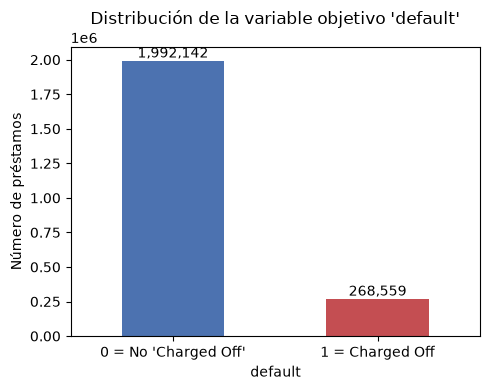

In [8]:
fig, ax = plt.subplots(figsize=(5,4))
target_counts.plot(kind="bar", ax=ax, color=["#4C72B0","#C44E52"])
ax.set_xticklabels(["0 = No 'Charged Off'","1 = Charged Off"], rotation=0)
ax.set_ylabel("Número de préstamos")
ax.set_title("Distribución de la variable objetivo 'default'")
for i,v in enumerate(target_counts):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/target_distribution.png", dpi=110)
plt.show()


Decidimos mantener la regla indicada en el enunciado y no modificarla, pero consideramos importante dejar registrada esta situación porque afecta la forma en que se están definiendo las clases. Más adelante retomamos esta limitación al analizar los resultados.

Después de crear la variable, vemos que existe un desbalance entre las dos clases, porque el 88,12% de los préstamos quedaron como 0 y el 11,88% como 1. Es decir, hay aproximadamente 7,4 préstamos de clase 0 por cada préstamo de clase 1.

Este desbalance hace que el accuracy por sí solo no sea suficiente para evaluar los modelos. Por eso usamos una partición estratificada y prestamos más atención a métricas como AUC-ROC, F1 y AUC-PR. También tenemos en cuenta el umbral de decisión al momento de comparar los modelos.

### 1.2.2 Variables numéricas

In [9]:
def parse_emp_length(x):
    if pd.isna(x): return np.nan
    x = str(x)
    if "10+" in x: return 10.0
    if "< 1" in x: return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

df["emp_length_num"] = df["emp_length"].apply(parse_emp_length)

numeric_vars = ["loan_amnt","int_rate","installment","annual_inc","dti",
                "fico_range_low","fico_range_high","open_acc","revol_bal",
                "revol_util","total_acc","pub_rec","delinq_2yrs","mort_acc",
                "inq_last_6mths","emp_length_num"]


Para los modelos seleccionamos un conjunto de variables numéricas que estuvieran disponibles en el momento en que se otorgó el préstamo.

Por eso dejamos por fuera variables como **`total_pymnt`**, **`recoveries`**, **`last_pymnt_d`** y **`out_prncp`**, entre otras. Estas variables contienen información que se conoce después, cuando el préstamo ya ha avanzado o incluso ha terminado. Con esto evitamos data leakage.

Al revisar las variables seleccionadas encontramos algunos casos que nos llamaron la atención. Por ejemplo:

-  **`annual_inc`** tiene una distribución bastante sesgada. Hay valores extremadamente altos que hacen que la media llegue a ser de unos 110 millones, mientras que la mediana está alrededor de 65.000. Esto nos muestra que la mediana representa mucho mejor el comportamiento típico de los datos y que esta variable podría beneficiarse de una transformación logarítmica.
- En **`dti`** también encontramos valores que llaman la atención. Hay registros con valores de -1 y otros que llegan hasta 999. Un DTI negativo no tiene sentido en términos financieros y un valor de 999 tampoco parece representar un DTI real. Por eso estos valores deben tratarse como datos faltantes o valores atípicos y no como observaciones normales.
- Algo diferente ocurre con **`pub_rec`** y **`delinq_2yrs`**. El análisis mediante IQR identifica una cantidad importante de valores como “atípicos”, pero en este caso no significa necesariamente que sean errores. Son variables de conteo y la mayoría de los registros tienen valor 0, por lo que es normal que exista una concentración muy grande en ese punto y una cola con valores más altos. Por eso no consideramos que todos esos valores identificados por IQR deban eliminarse.
- En las demás variables, como **`loan_amnt`**, **`int_rate`**, **`installment`** y las variables relacionadas con FICO, encontramos una asimetría más moderada. Esto es bastante esperable en variables financieras, donde normalmente tenemos valores que parten de un límite inferior y una cola hacia valores más altos.

In [10]:
rows = []
for col in numeric_vars:
    s = pd.to_numeric(df[col], errors="coerce")
    d = s.describe(percentiles=[.25,.5,.75])
    q1, q3 = d["25%"], d["75%"]
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((s < lo) | (s > hi)).sum()
    rows.append({
        "variable": col, "media": d["mean"], "mediana": d["50%"], "sd": d["std"],
        "min": d["min"], "Q1": q1, "Q3": q3, "max": d["max"], "IQR": iqr,
        "n_outliers_IQR": n_out, "pct_outliers": round(n_out/s.notna().sum()*100,2),
        "skewness": round(s.skew(),3), "pct_missing": round(s.isna().mean()*100,2)
    })
numeric_summary = pd.DataFrame(rows).set_index("variable")
numeric_summary.to_csv("../outputs/tables/eda/numeric_summary.csv")
numeric_summary.round(2)


,media,mediana,sd,min,Q1,Q3,max,IQR,n_outliers_IQR,pct_outliers,skewness,pct_missing
variable,,,,,,,,,,,,
loan_amnt,15046.93,12900.00,9190.25,500.00,8000.00,20000.00,4.000000e+04,12000.00,35215,1.56,0.78,0.00
int_rate,13.09,12.62,4.83,5.31,9.49,15.99,3.099000e+01,6.50,41099,1.82,0.77,0.00
installment,445.81,377.99,267.17,4.93,251.65,593.32,1.719830e+03,341.67,66312,2.93,1.00,0.00
annual_inc,77992.43,65000.00,112696.20,0.00,46000.00,93000.00,1.100000e+08,47000.00,110041,4.87,493.89,0.00
dti,18.82,17.84,14.18,-1.00,11.89,24.49,9.990000e+02,12.60,21580,0.96,29.20,0.08
fico_range_low,698.59,690.00,33.01,610.00,675.00,715.00,8.450000e+02,40.00,74846,3.31,1.19,0.00
fico_range_high,702.59,694.00,33.01,614.00,679.00,719.00,8.500000e+02,40.00,74846,3.31,1.19,0.00
open_acc,11.61,11.00,5.64,0.00,8.00,14.00,1.010000e+02,6.00,84754,3.75,1.32,0.00
revol_bal,16658.46,11324.00,22948.31,0.00,5950.00,20246.00,2.904836e+06,14296.00,137095,6.06,13.23,0.00


También revisamos la normalidad de las variables utilizando Shapiro-Wilk. Como tenemos alrededor de 2,26 millones de observaciones, no era conveniente aplicar directamente esta prueba sobre todo el conjunto de datos. Además, con muestras tan grandes, pequeñas desviaciones de la normalidad pueden resultar estadísticamente significativas.

Por eso tomamos una muestra aleatoria de 5.000 registros, siguiendo la opción que plantea el enunciado. En todas las variables obtuvimos un p-valor menor a 0,001, por lo que rechazamos la hipótesis de normalidad. Esto coincide con lo que ya habíamos observado en las distribuciones y nos llevó a utilizar posteriormente la prueba de Mann-Whitney para comparar grupos, en lugar de la prueba t de Student.

In [11]:
shapiro_rows = []
rng = np.random.default_rng(42)
for col in numeric_vars:
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    sample = s.sample(5000, random_state=42) if len(s) > 5000 else s
    stat, p = stats.shapiro(sample)
    shapiro_rows.append({"variable": col, "shapiro_stat": round(stat,4), "p_value": p})
shapiro_df = pd.DataFrame(shapiro_rows).set_index("variable")
shapiro_df.to_csv("../outputs/tables/eda/shapiro_subsample.csv")
shapiro_df


,shapiro_stat,p_value
variable,,
loan_amnt,0.9363,6.317027e-42
int_rate,0.9630,5.903080e-34
installment,0.9301,2.190740e-43
annual_inc,0.2226,5.555048e-90
dti,0.3491,5.885621e-86
fico_range_low,0.8998,3.037575e-49
fico_range_high,0.8998,3.011072e-49
open_acc,0.9233,7.423204e-45
revol_bal,0.4761,3.652391e-81


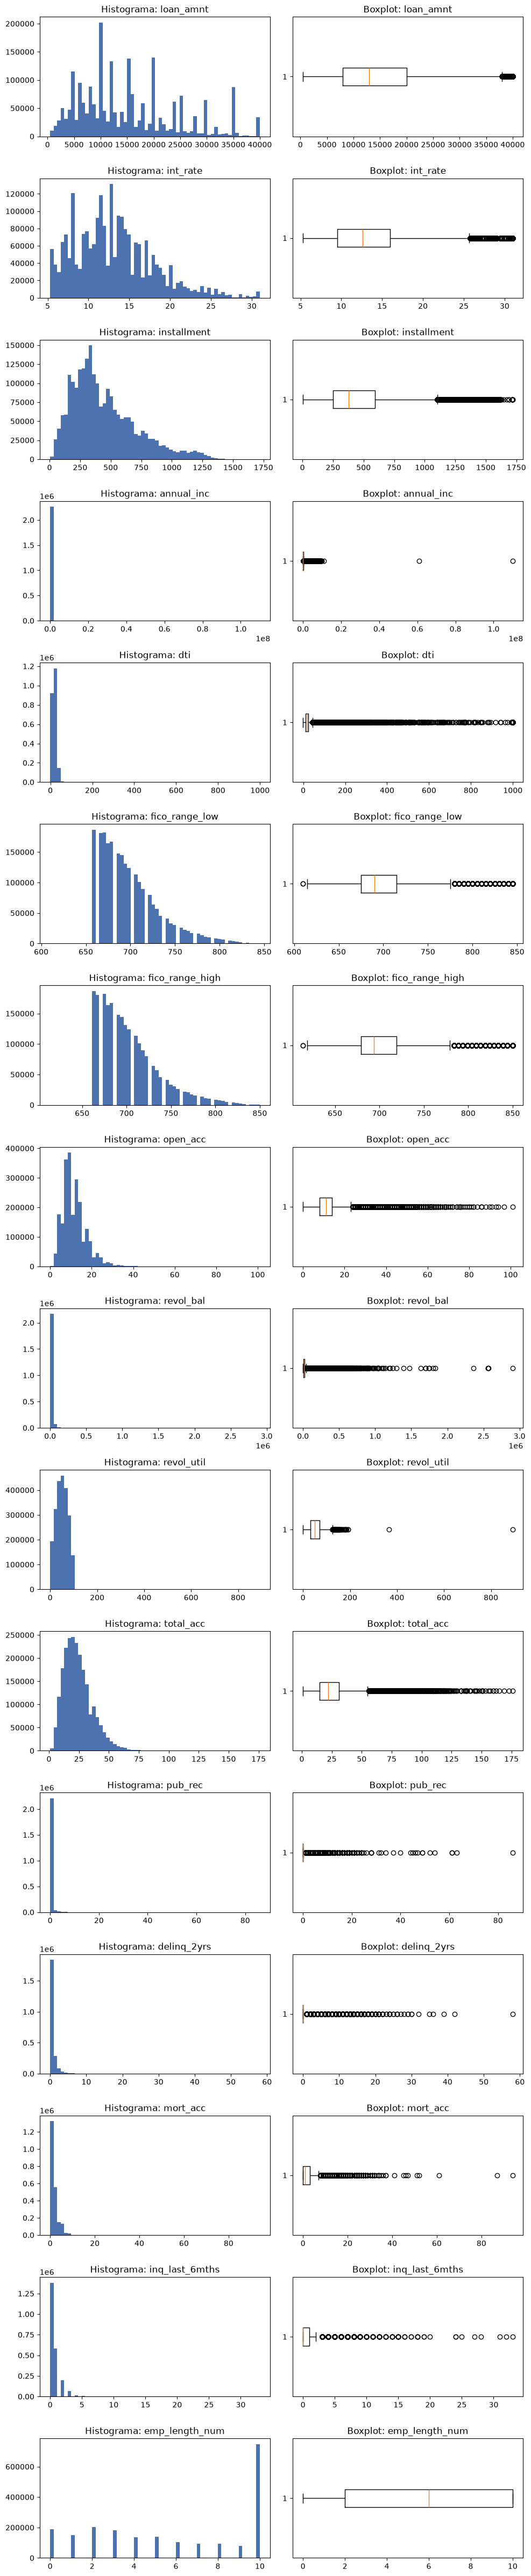

In [12]:
n = len(numeric_vars)
fig, axes = plt.subplots(n, 2, figsize=(10, 3*n))
for i, col in enumerate(numeric_vars):
    s = pd.to_numeric(df[col], errors="coerce").dropna()
    axes[i,0].hist(s, bins=60, color="#4C72B0")
    axes[i,0].set_title(f"Histograma: {col}")
    axes[i,1].boxplot(s, orientation="horizontal")
    axes[i,1].set_title(f"Boxplot: {col}")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/numeric_hist_box.png", dpi=100)
plt.show()


### 1.2.3 Variables categóricas

In [13]:
cat_vars = ["term","grade","sub_grade","home_ownership","verification_status",
            "purpose","addr_state","initial_list_status","application_type","emp_length"]

summary_rows = []
for col in cat_vars:
    vc = df[col].value_counts(dropna=False)
    vc_pct = (vc/len(df)*100).round(2)
    summary_rows.append({
        "variable": col, "n_categorias": df[col].nunique(dropna=True),
        "n_categorias_raras(<1%)": (vc_pct<1).sum(),
        "pct_missing": round(df[col].isna().mean()*100,2),
        "categoria_mas_frecuente": vc.index[0], "pct_mas_frecuente": vc_pct.iloc[0]
    })
cat_summary = pd.DataFrame(summary_rows).set_index("variable")
cat_summary.to_csv("../outputs/tables/eda/categorical_summary.csv")
cat_summary


,n_categorias,n_categorias_raras(<1%),pct_missing,categoria_mas_frecuente,pct_mas_frecuente
variable,,,,,
term,2,1,0.0,36 months,71.21
grade,7,2,0.0,B,29.35
sub_grade,35,11,0.0,C1,6.45
home_ownership,6,4,0.0,MORTGAGE,49.16
verification_status,3,1,0.0,Source Verified,39.20
purpose,14,7,0.0,debt_consolidation,56.53
addr_state,51,24,0.0,CA,13.91
initial_list_status,2,1,0.0,w,67.92
application_type,2,1,0.0,Individual,94.66


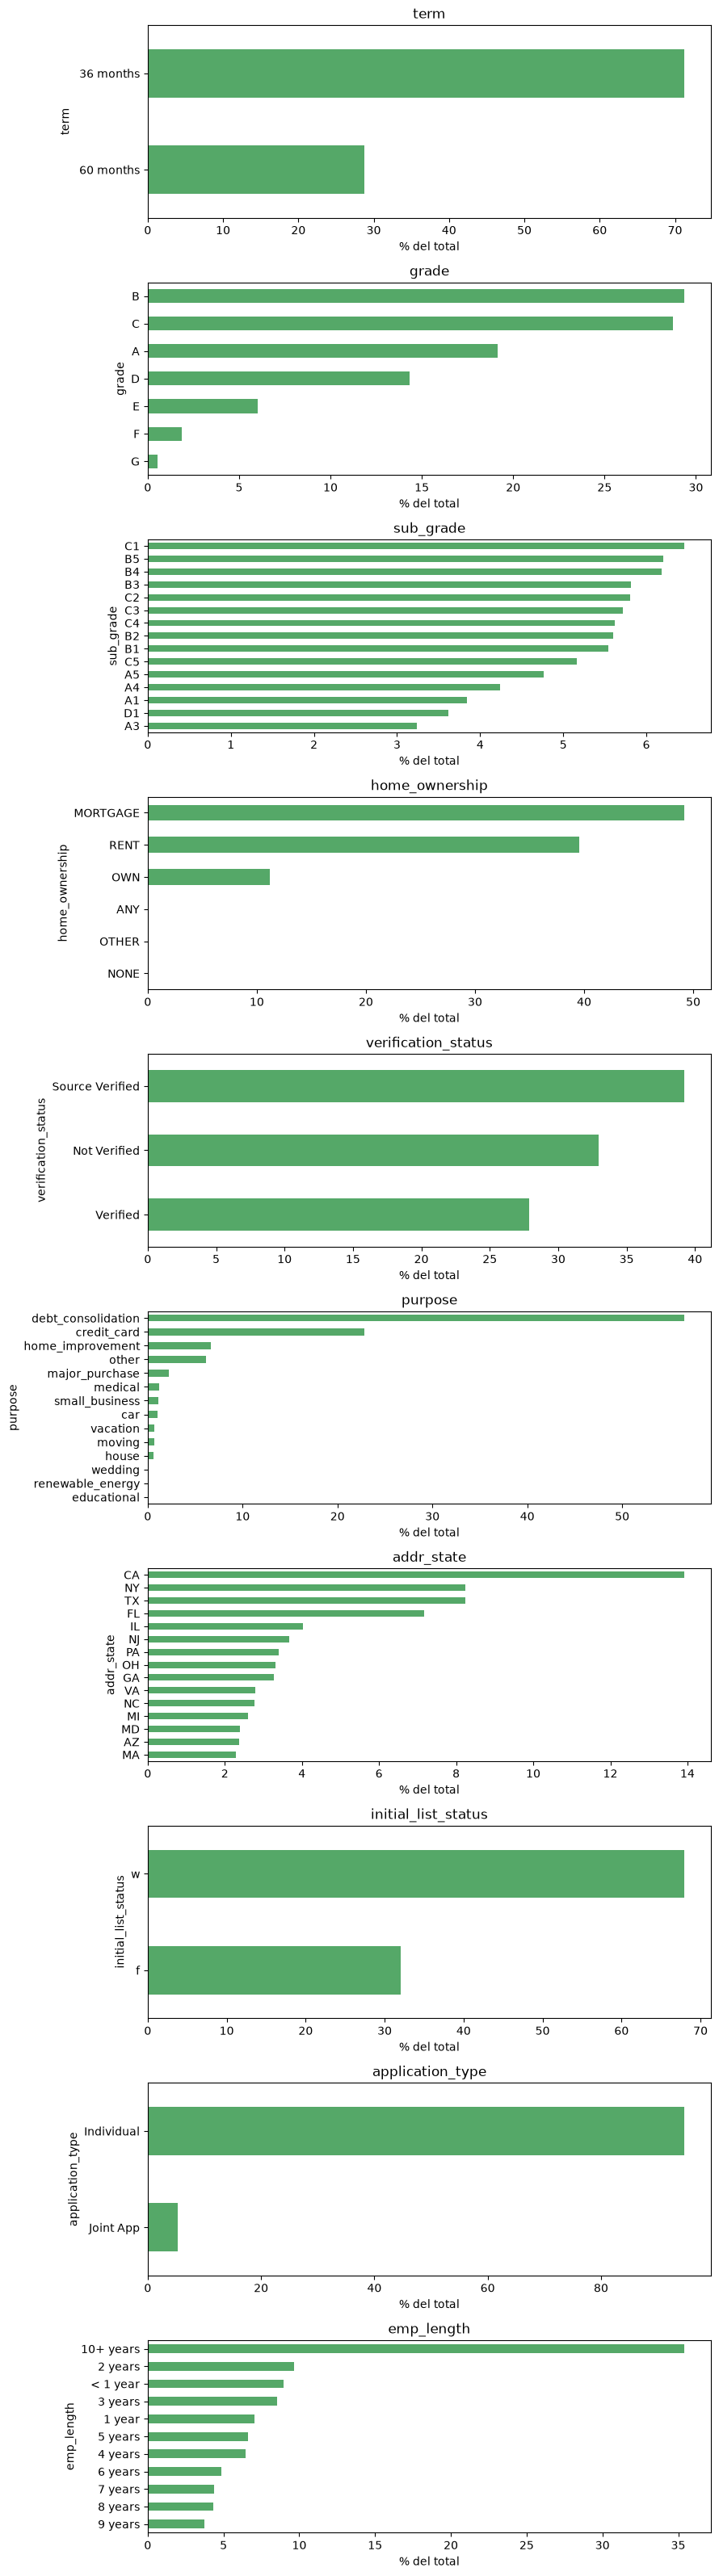

In [14]:
fig, axes = plt.subplots(len(cat_vars), 1, figsize=(9, 3.2*len(cat_vars)))
for i, col in enumerate(cat_vars):
    top = (df[col].value_counts(normalize=True)*100).head(15)
    top.plot(kind="barh", ax=axes[i], color="#55A868")
    axes[i].invert_yaxis()
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel("% del total")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/categorical_bars.png", dpi=100)
plt.show()


Al revisar las variables categóricas también encontramos algunas diferencias importantes en la cantidad de categorías. Por ejemplo, **`addr_state`** tiene 51 categorías y 23 de ellas representan menos del 1% de los datos cada una. Si utilizamos one-hot encoding, esto puede hacer que el número de variables aumente bastante sin aportar necesariamente mucha información al modelo.

Por eso, una opción que consideramos es agrupar las categorías con muy pocos registros en una sola categoría llamada “Otros”. De esta forma podemos reducir un poco la cantidad de variables sin perder demasiada información.

Algo parecido ocurre con **`sub_grade`**, que tiene 35 categorías, y con **`purpose`**, que tiene 14. En este último caso, 7 categorías tienen muy pocos registros. Aunque el problema es menor que en **`addr_state`**, también es algo que debemos tener en cuenta al momento de preparar las variables para los modelos.

## 1.3. Análisis bidimensional

### 1.3.1 Numéricas vs. `default`

In [15]:
rows = []
for col in numeric_vars:
    s = pd.to_numeric(df[col], errors="coerce")
    valid = s.notna()
    g0 = s[valid & (df["default"]==0)]
    g1 = s[valid & (df["default"]==1)]
    stat_mw, p_mw = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    r_pb, p_pb = stats.pointbiserialr(df.loc[valid,"default"], s[valid])
    rows.append({"variable": col, "media_0": g0.mean(), "media_1": g1.mean(),
                 "diff_medias": g1.mean()-g0.mean(), "mannwhitney_p": p_mw,
                 "point_biserial_r": round(r_pb,4)})
num_vs_target = pd.DataFrame(rows).set_index("variable")
num_vs_target.to_csv("../outputs/tables/eda/numeric_vs_target.csv")
num_vs_target.round(4)


,media_0,media_1,diff_medias,mannwhitney_p,point_biserial_r
variable,,,,,
loan_amnt,14977.0822,15565.0554,587.9733,0.0,0.0207
int_rate,12.7399,15.7107,2.9708,0.0,0.1989
installment,443.1994,465.1480,21.9486,0.0,0.0266
annual_inc,79015.8765,70400.7433,-8615.1332,0.0,-0.0247
dti,18.6425,20.1712,1.5287,0.0,0.0349
fico_range_low,700.0358,687.8501,-12.1857,0.0,-0.1194
fico_range_high,704.0360,691.8502,-12.1859,0.0,-0.1194
open_acc,11.5735,11.9013,0.3278,0.0,0.0188
revol_bal,16834.3812,15353.5006,-1480.8807,0.0,-0.0209


Al comparar las variables numéricas entre los préstamos que terminaron en **`default`** y los que no, encontramos lo siguiente:

- Todas las variables presentan diferencias estadísticamente significativas según la prueba de Mann-Whitney. Sin embargo, con 2,26 millones de observaciones, un p-valor cercano a 0 no necesariamente significa que la diferencia sea importante en la práctica.
- Por eso, en lugar de fijarnos solamente en el p-valor, también revisamos la correlación punto-biserial para tener una idea de qué tan fuerte es la relación de cada variable con **`default`**.
- **`int_rate`** es la variable que presenta la relación más fuerte, con una correlación de **0,199**.
- Le siguen **`fico_range_low`** y **`fico_range_high`**, con correlaciones cercanas a **-0,119**, y **`inq_last_6mths`**, con una correlación de **0,083**.
- El resto de las variables tiene correlaciones bastante débiles, con valores absolutos menores a **0,05**.
- Esto tiene sentido para un problema de riesgo crediticio, ya que no esperamos que una sola variable sea suficiente para predecir el incumplimiento. Lo importante es que el modelo pueda combinar varias variables y encontrar patrones entre ellas.
- Finalmente, en los boxplots recortamos los valores por encima del percentil 99 únicamente para que las gráficas fueran más fáciles de leer. Este recorte se hizo solo para visualizar los datos, los estadísticos y resultados de las pruebas se calcularon utilizando el conjunto completo.

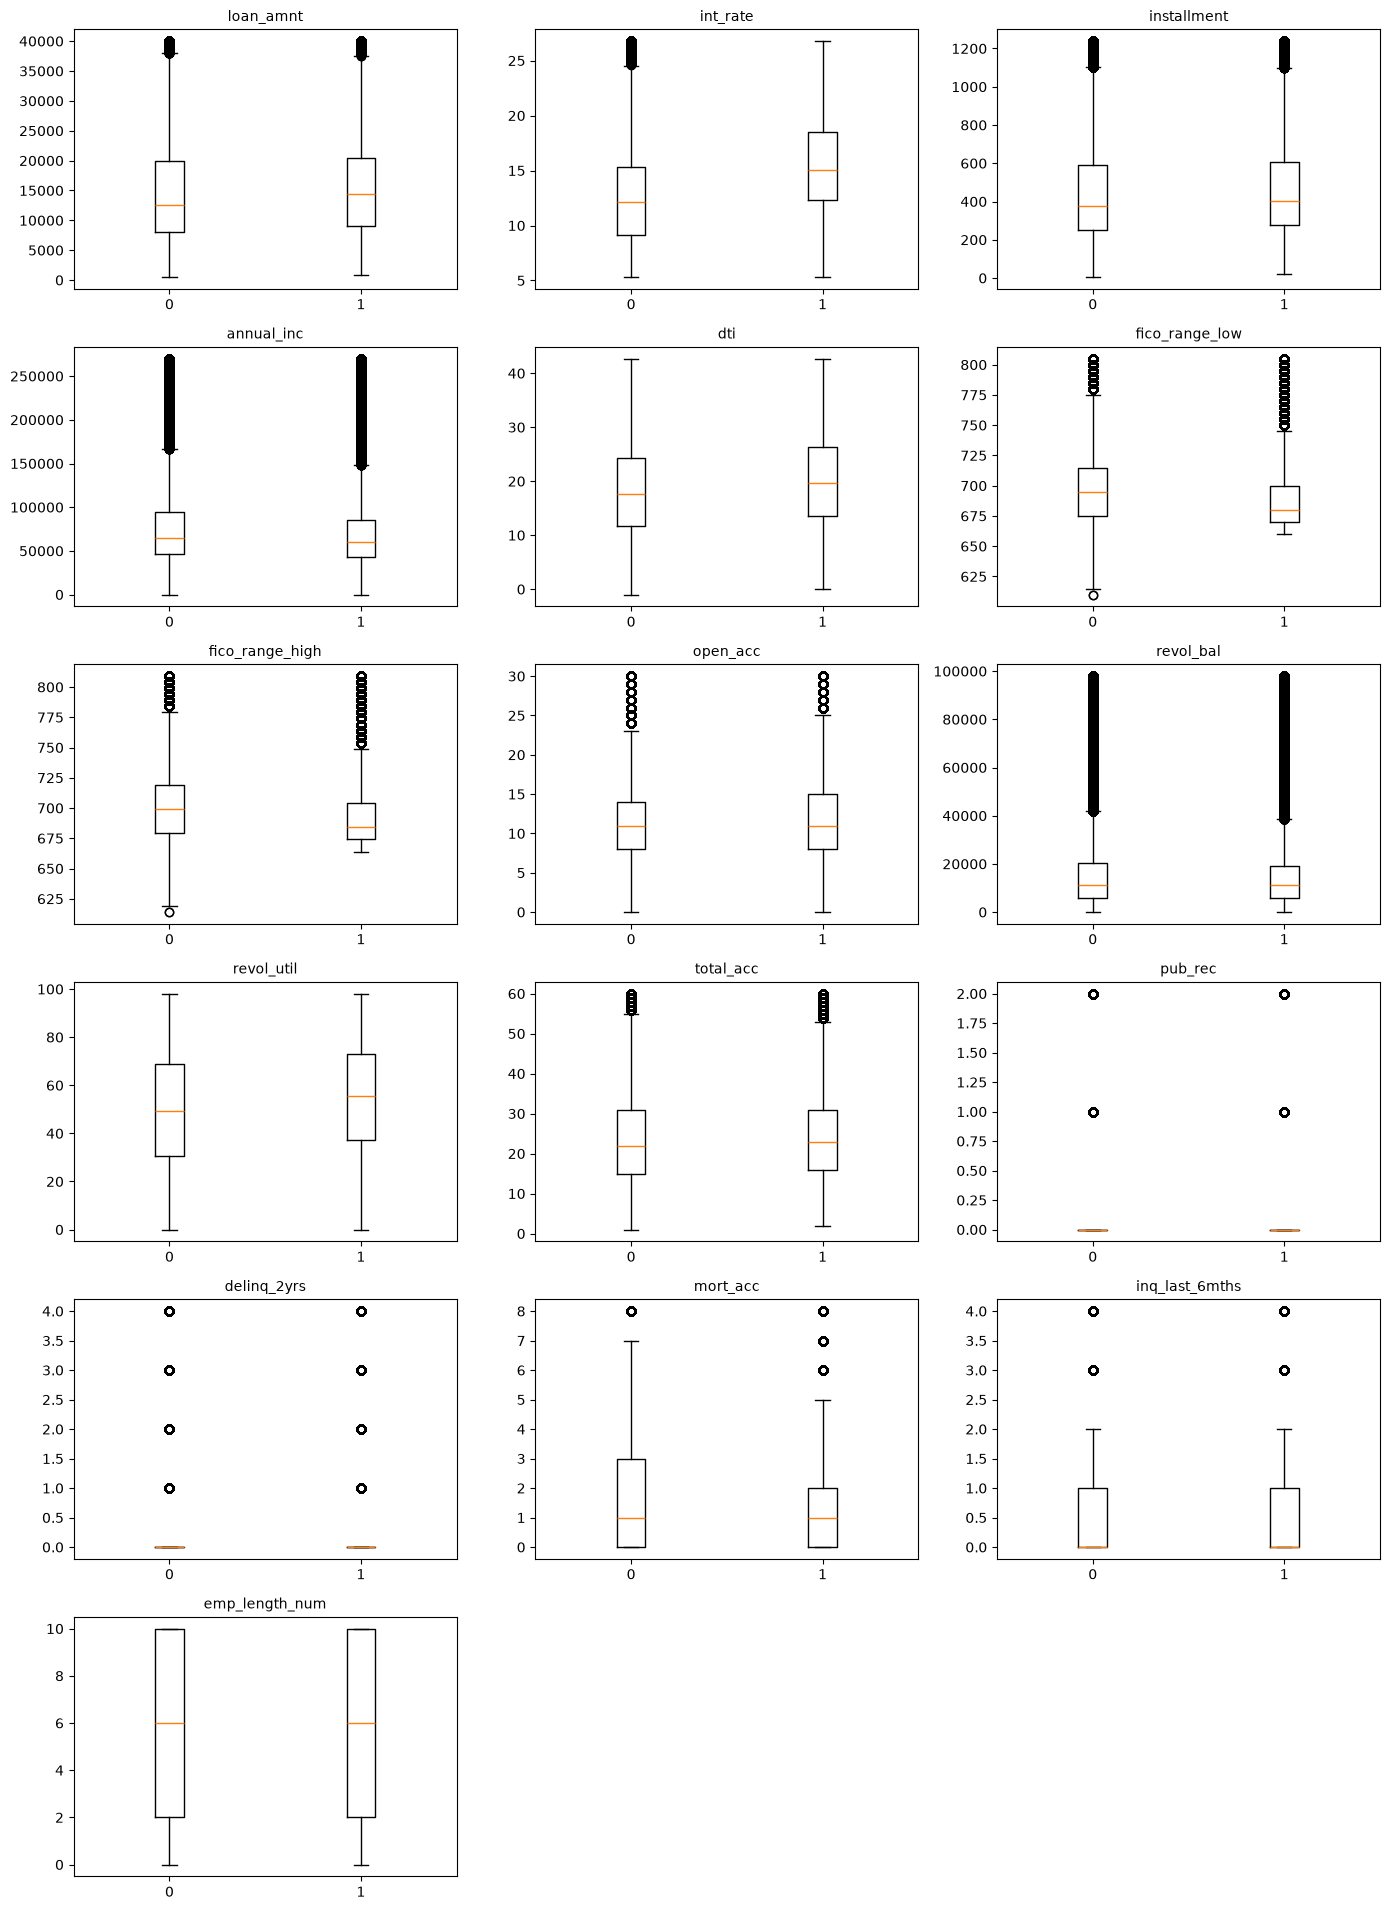

In [16]:
n = len(numeric_vars)
fig, axes = plt.subplots((n+2)//3, 3, figsize=(14, 3.2*((n+2)//3)))
axes = axes.flatten()
for i, col in enumerate(numeric_vars):
    s = pd.to_numeric(df[col], errors="coerce")
    cap = s.quantile(0.99)
    data0 = s[df["default"]==0].dropna().clip(upper=cap)
    data1 = s[df["default"]==1].dropna().clip(upper=cap)
    axes[i].boxplot([data0, data1], tick_labels=["0","1"])
    axes[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/boxplots_by_class.png", dpi=100)
plt.show()


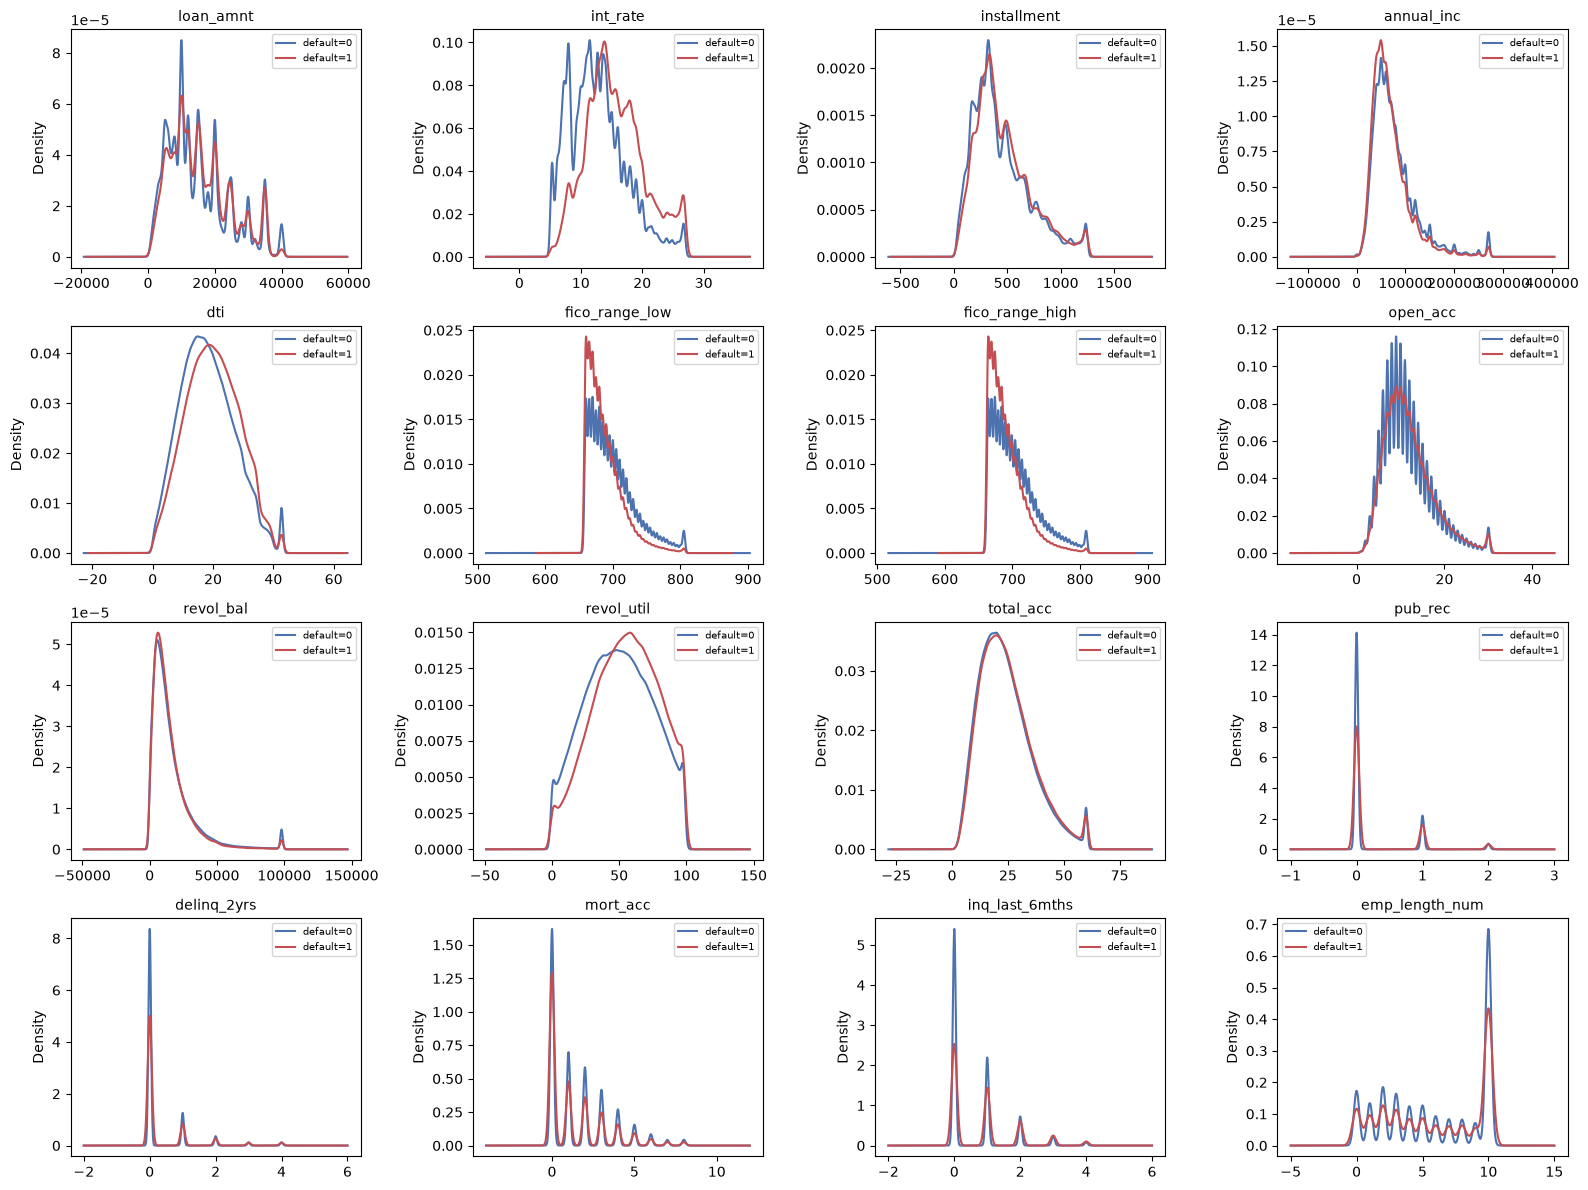

In [17]:
fig, axes = plt.subplots(4, 4, figsize=(16,12))
axes = axes.flatten()
for i, col in enumerate(numeric_vars):
    s = pd.to_numeric(df[col], errors="coerce")
    cap = s.quantile(0.99)
    for cls, color in [(0,"#4C72B0"), (1,"#C44E52")]:
        data = s[df["default"]==cls].dropna().clip(upper=cap)
        data.plot(kind="density", ax=axes[i], color=color, label=f"default={cls}")
    axes[i].set_title(col, fontsize=10)
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/kde_by_class.png", dpi=100)
plt.show()


### 1.3.2 Categóricas vs. `default`

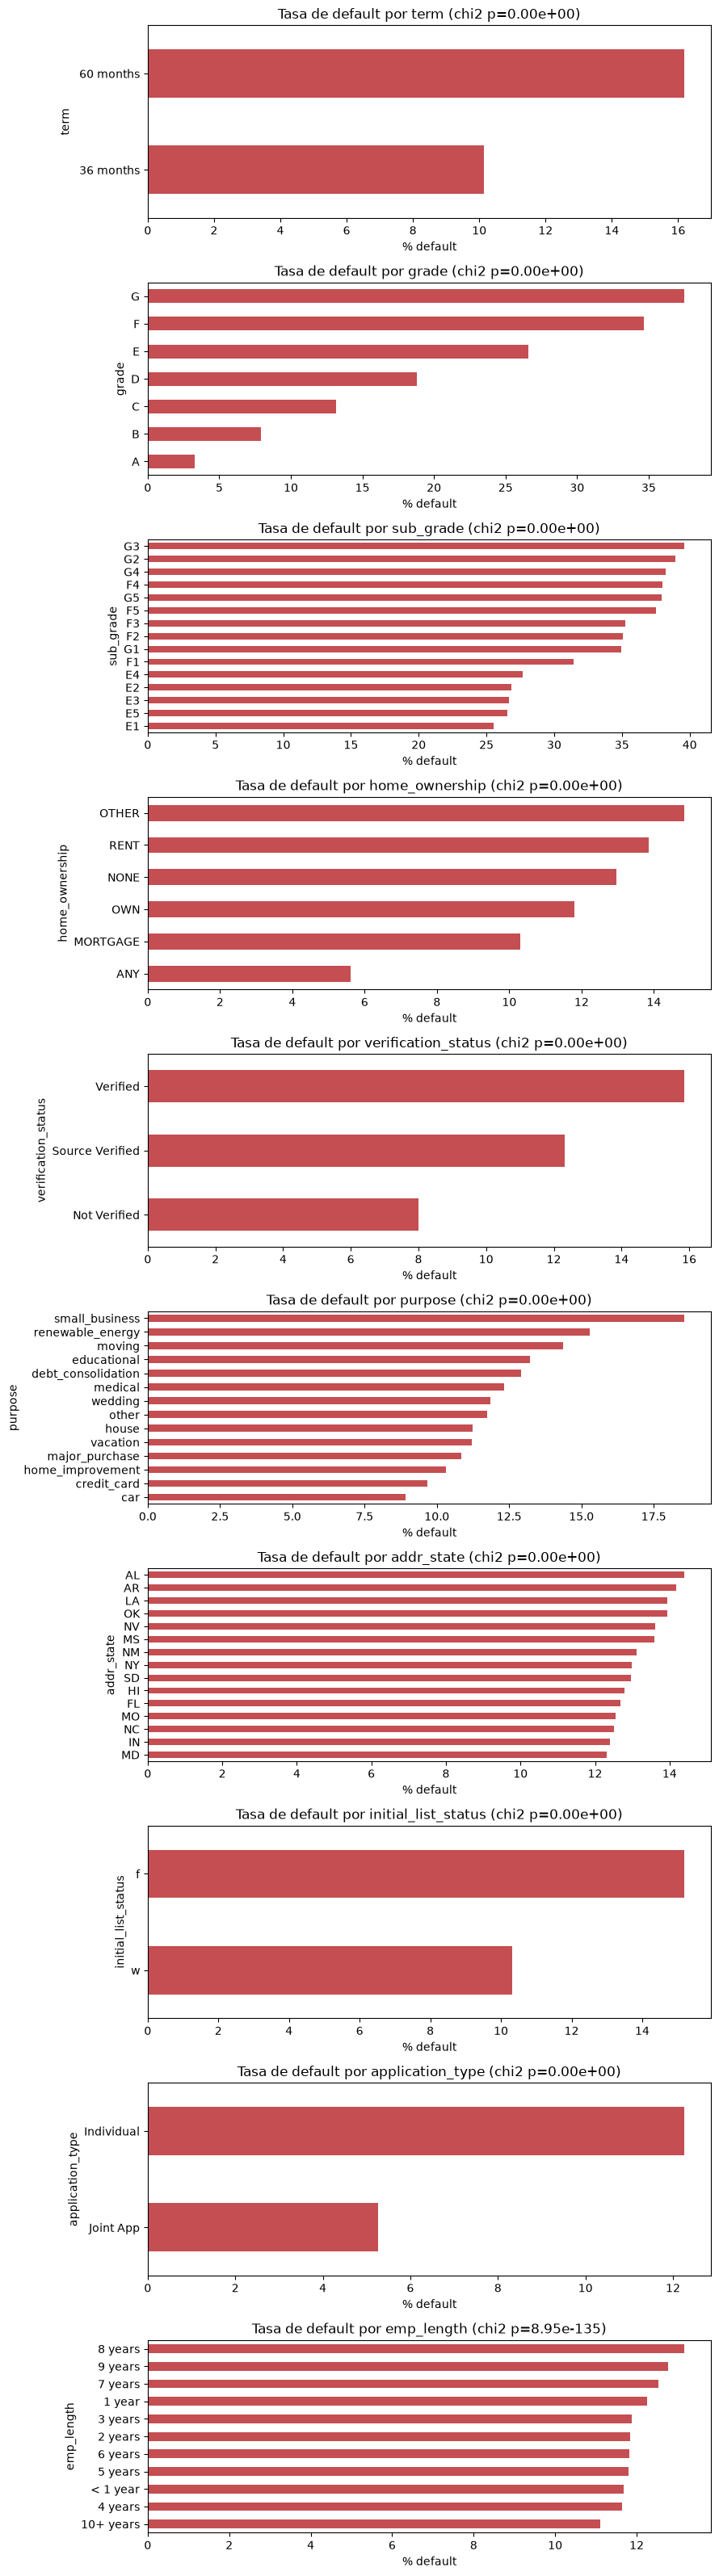

,chi2,p_value,dof,categoria_mayor_default_%,tasa_mayor_default_%,categoria_menor_default_%,tasa_menor_default_%
variable,,,,,,,
term,16135.405611,0.000000e+00,1,60 months,16.18,36 months,10.14
grade,112789.264671,0.000000e+00,6,G,37.48,A,3.28
sub_grade,116768.427893,0.000000e+00,34,G3,39.59,A1,1.62
home_ownership,6040.699202,0.000000e+00,5,OTHER,14.84,ANY,5.62
verification_status,20391.761668,0.000000e+00,2,Verified,15.85,Not Verified,7.99
purpose,5506.641353,0.000000e+00,13,small_business,18.55,car,8.92
addr_state,3226.072554,0.000000e+00,50,AL,14.39,ME,5.65
initial_list_status,11140.302534,0.000000e+00,1,f,15.18,w,10.32
application_type,5344.285224,0.000000e+00,1,Individual,12.25,Joint App,5.26


In [18]:
chi2_rows = []
fig, axes = plt.subplots(len(cat_vars), 1, figsize=(9, 3.2*len(cat_vars)))
for i, col in enumerate(cat_vars):
    ct = pd.crosstab(df[col], df["default"])
    chi2, p, dof, exp = chi2_contingency(ct)
    default_rate = (df.groupby(col, observed=True)["default"].mean()*100).sort_values(ascending=False)
    chi2_rows.append({"variable": col, "chi2": chi2, "p_value": p, "dof": dof,
                       "categoria_mayor_default_%": default_rate.index[0],
                       "tasa_mayor_default_%": round(default_rate.iloc[0],2),
                       "categoria_menor_default_%": default_rate.index[-1],
                       "tasa_menor_default_%": round(default_rate.iloc[-1],2)})
    default_rate.head(15).plot(kind="barh", ax=axes[i], color="#C44E52")
    axes[i].invert_yaxis()
    axes[i].set_title(f"Tasa de default por {col} (chi2 p={p:.2e})")
    axes[i].set_xlabel("% default")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/default_rate_by_category.png", dpi=100)
plt.show()

cat_vs_target = pd.DataFrame(chi2_rows).set_index("variable")
cat_vs_target.to_csv("../outputs/tables/eda/categorical_vs_target.csv")
cat_vs_target


`grade` y `sub_grade` muestran el patrón más claro de todos: la tasa de default sube de 3,3% en grado A a 37,5% en grado G, de forma bastante escalonada. Esto tiene sentido porque el grade de Lending Club ya es en sí mismo una especie de puntaje de riesgo que la plataforma le asigna a cada préstamo. También encontramos que el plazo (`term`) de 60 meses casi duplica la tasa de default del de 36 meses (16,2% contra 10,1%). Todas estas variables categóricas resultaron significativas en la prueba de chi-cuadrado, pero lo más importante es que las diferencias en la tasa de default son grandes para `grade`, `sub_grade` y `term`, no solo estadísticamente significativas.

### 1.3.3 Multicolinealidad

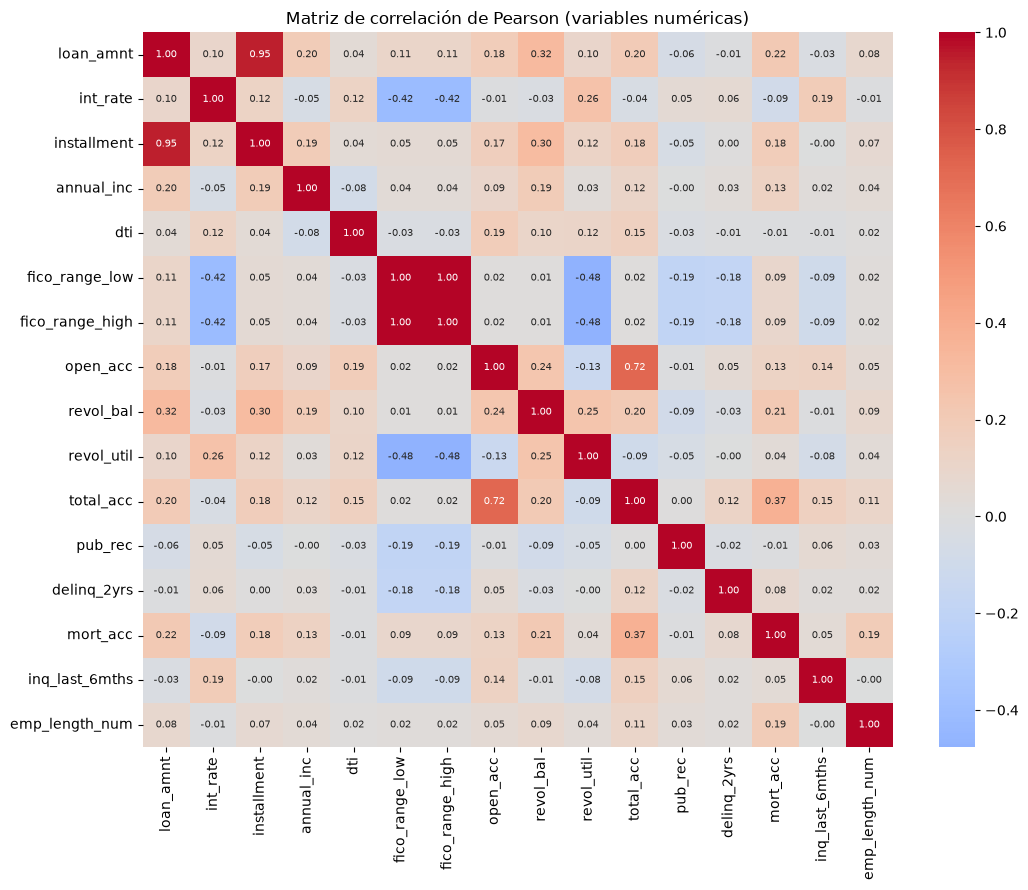

Pares con |r| > 0.7:
  loan_amnt -- installment: r=0.946
  fico_range_low -- fico_range_high: r=1.0
  open_acc -- total_acc: r=0.718

int_rate -- fico_range_high: r=-0.416 (moderada, no supera 0.7)


In [19]:
corr = df[numeric_vars].apply(pd.to_numeric, errors="coerce").corr(method="pearson")
corr.to_csv("../outputs/tables/eda/correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(11,9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, annot_kws={"size":7})
ax.set_title("Matriz de correlación de Pearson (variables numéricas)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/correlation_heatmap.png", dpi=110)
plt.show()

high_corr = [(corr.columns[i], corr.columns[j], round(corr.iloc[i,j],3))
             for i in range(len(corr.columns)) for j in range(i+1, len(corr.columns))
             if abs(corr.iloc[i,j]) > 0.7]
print("Pares con |r| > 0.7:")
for a,b,r in high_corr:
    print(f"  {a} -- {b}: r={r}")
print(f"\nint_rate -- fico_range_high: r={corr.loc['int_rate','fico_range_high']:.3f} (moderada, no supera 0.7)")


Encontramos tres redundancias bastante claras entre las variables numéricas. La primera es entre `fico_range_low` y `fico_range_high`, con una correlación de 1,00. Esto tiene sentido porque el rango FICO siempre viene en un intervalo de 4 puntos, así que en la práctica es el mismo dato repetido dos veces, y para el modelado basta usar una de las dos. La segunda es entre `loan_amnt` e `installment` (r=0,946), porque la cuota mensual es casi una función matemática del monto, la tasa y el plazo del préstamo, es decir, ya está contenida en `loan_amnt`, `term` e `int_rate` juntas. La tercera es entre `open_acc` y `total_acc` (r=0,718), una redundancia más moderada entre el número de cuentas abiertas y el número total de cuentas que la persona ha tenido.

También revisamos, como lo sugiere el enunciado, la relación entre `int_rate` y `fico_range_high`. La correlación es moderada y negativa (alrededor de -0,4), pero no llega al umbral de 0,7 que consideramos como multicolinealidad fuerte. Esto tiene sentido porque el puntaje FICO es solo uno de los factores que determinan la tasa de interés, junto con el grado, el plazo y el monto del préstamo.

In [20]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt((chi2/n) / min(k-1, r-1))

cramers_rows = []
for i in range(len(cat_vars)):
    for j in range(i+1, len(cat_vars)):
        v = cramers_v(df[cat_vars[i]], df[cat_vars[j]])
        cramers_rows.append({"var1": cat_vars[i], "var2": cat_vars[j], "cramers_v": round(v,3)})
cramers_df = pd.DataFrame(cramers_rows).sort_values("cramers_v", ascending=False)
cramers_df.to_csv("../outputs/tables/eda/cramers_v.csv", index=False)
cramers_df.head(10)


,var1,var2,cramers_v
9,grade,sub_grade,1.000
1,term,sub_grade,0.395
0,term,grade,0.385
18,sub_grade,verification_status,0.190
11,grade,verification_status,0.176
6,term,initial_list_status,0.152
21,sub_grade,initial_list_status,0.143
14,grade,initial_list_status,0.138
26,home_ownership,addr_state,0.113
2,term,home_ownership,0.109


Por último, `grade` y `sub_grade` tienen una V de Cramér de 1,0, lo que significa que `sub_grade` determina `grade` por completo (todas las categorías A1 a A5 son grado A, y así sucesivamente). Son la misma información en distinta granularidad, así que para el modelado decidimos usar solo una de las dos.

## 1.4. Valores faltantes (análisis detallado)

In [21]:
profile = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean()*100).round(2),
    "n_unique": df.nunique(dropna=True),
}).sort_values("pct_missing", ascending=False)
profile.to_csv("../outputs/tables/column_profile_full.csv")

print(f"Columnas sin nulos: {(profile['pct_missing']==0).sum()}")
print(f"Columnas con >30% nulos: {(profile['pct_missing']>30).sum()}")
print(f"Columnas con >70% nulos: {(profile['pct_missing']>70).sum()}")
profile.head(15)


Columnas sin nulos: 50
Columnas con >30% nulos: 58
Columnas con >70% nulos: 41


,dtype,n_missing,pct_missing,n_unique
member_id,null[pyarrow],2260701,100.00,0
orig_projected_additional_accrued_interest,double[pyarrow],2252050,99.62,7487
payment_plan_start_date,string[pyarrow],2249784,99.52,27
hardship_status,string[pyarrow],2249784,99.52,3
hardship_start_date,string[pyarrow],2249784,99.52,27
hardship_dpd,double[pyarrow],2249784,99.52,34
hardship_loan_status,string[pyarrow],2249784,99.52,5
hardship_length,double[pyarrow],2249784,99.52,1
deferral_term,double[pyarrow],2249784,99.52,1
hardship_payoff_balance_amount,double[pyarrow],2249784,99.52,10893


<Figure size 1600x800 with 0 Axes>

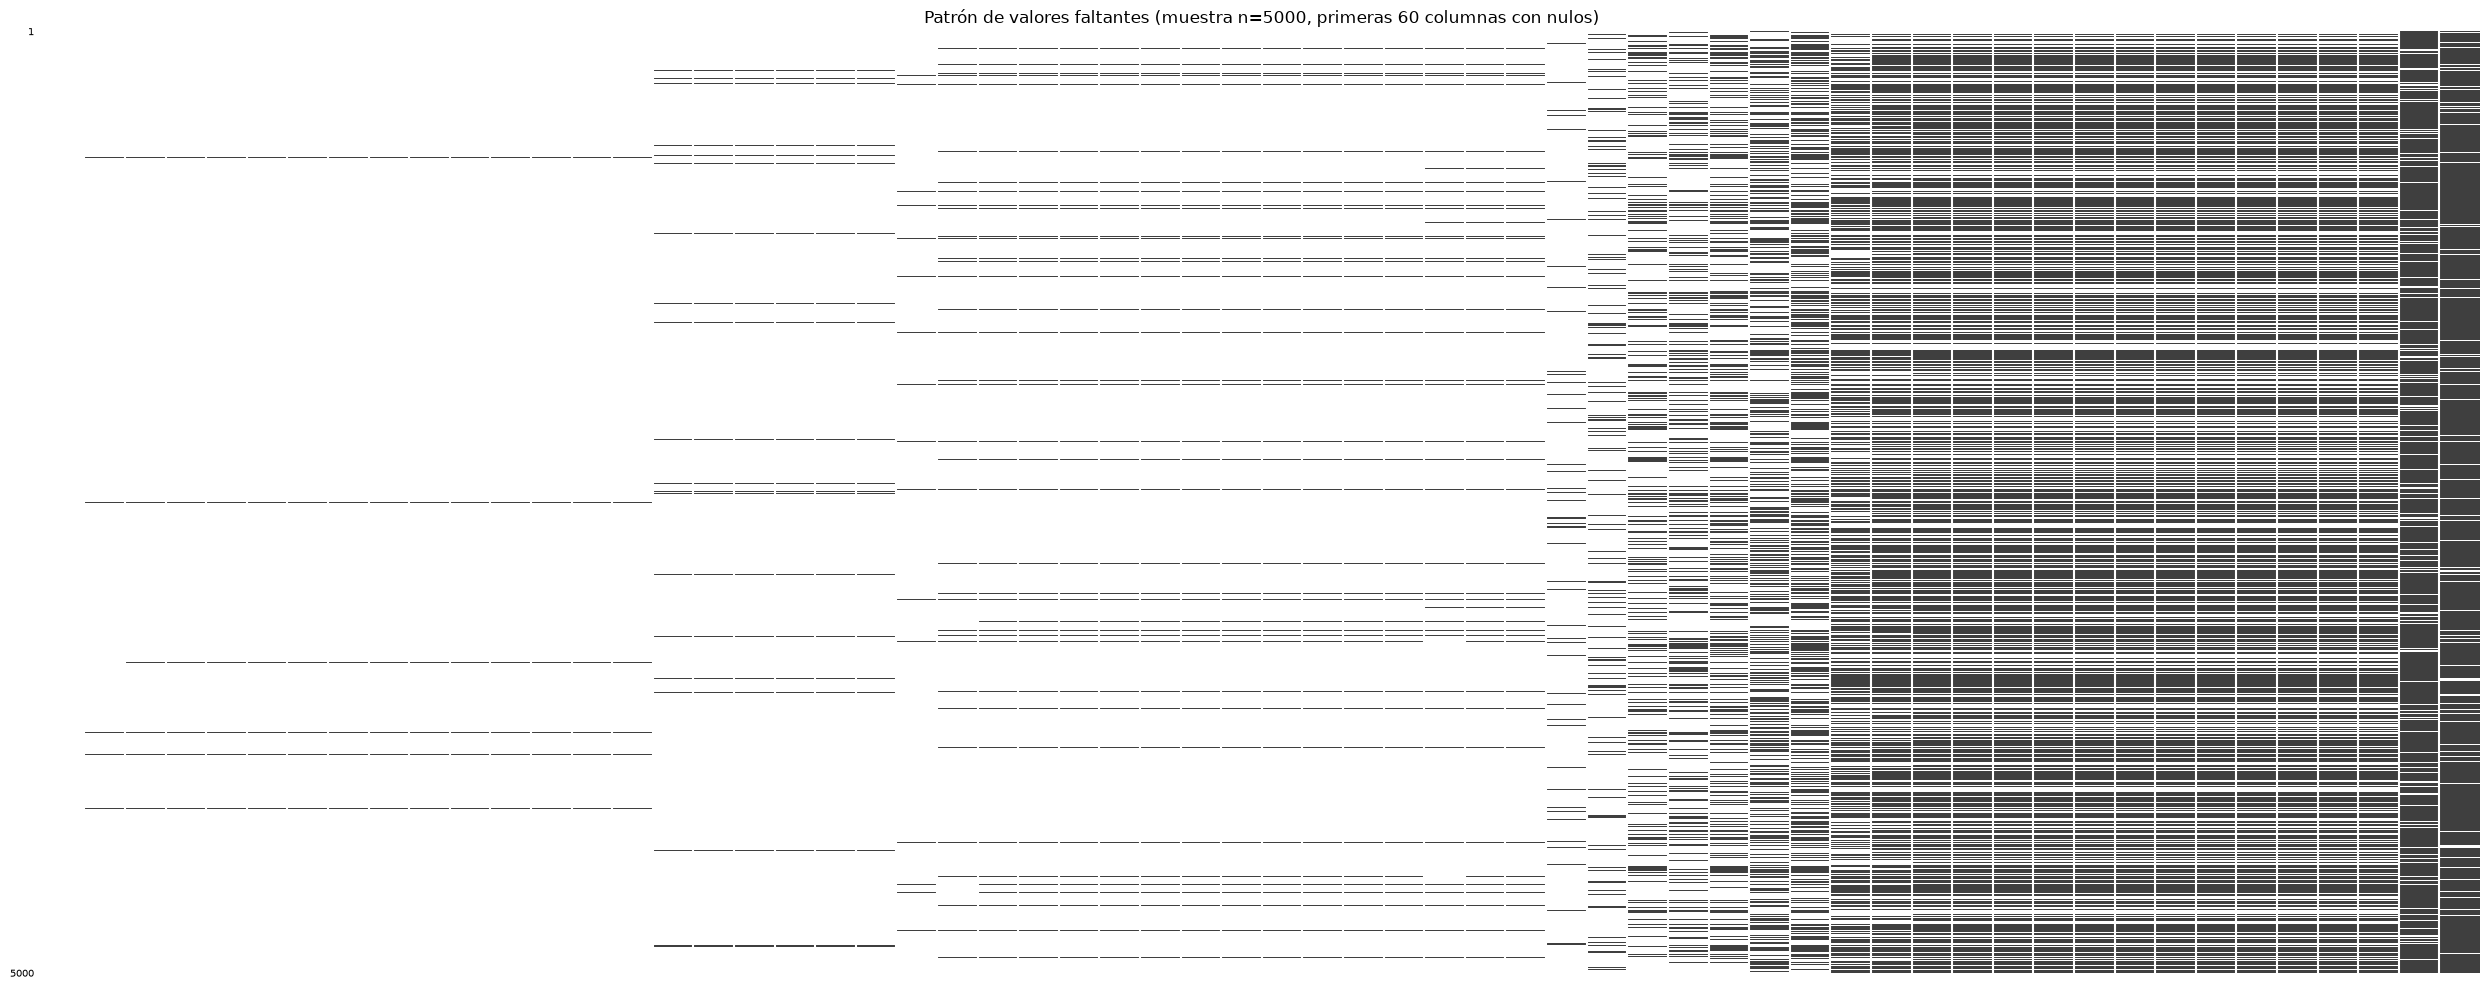

In [22]:
sample = df.sample(5000, random_state=42)
cols_con_nulos = profile[profile["pct_missing"]>0].index.tolist()

fig = plt.figure(figsize=(16,8))
msno.matrix(sample[cols_con_nulos[:60]], sparkline=False, fontsize=6)
plt.title("Patrón de valores faltantes (muestra n=5000, primeras 60 columnas con nulos)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/missing_matrix.png", dpi=100)
plt.show()


<Figure size 1000x1000 with 0 Axes>

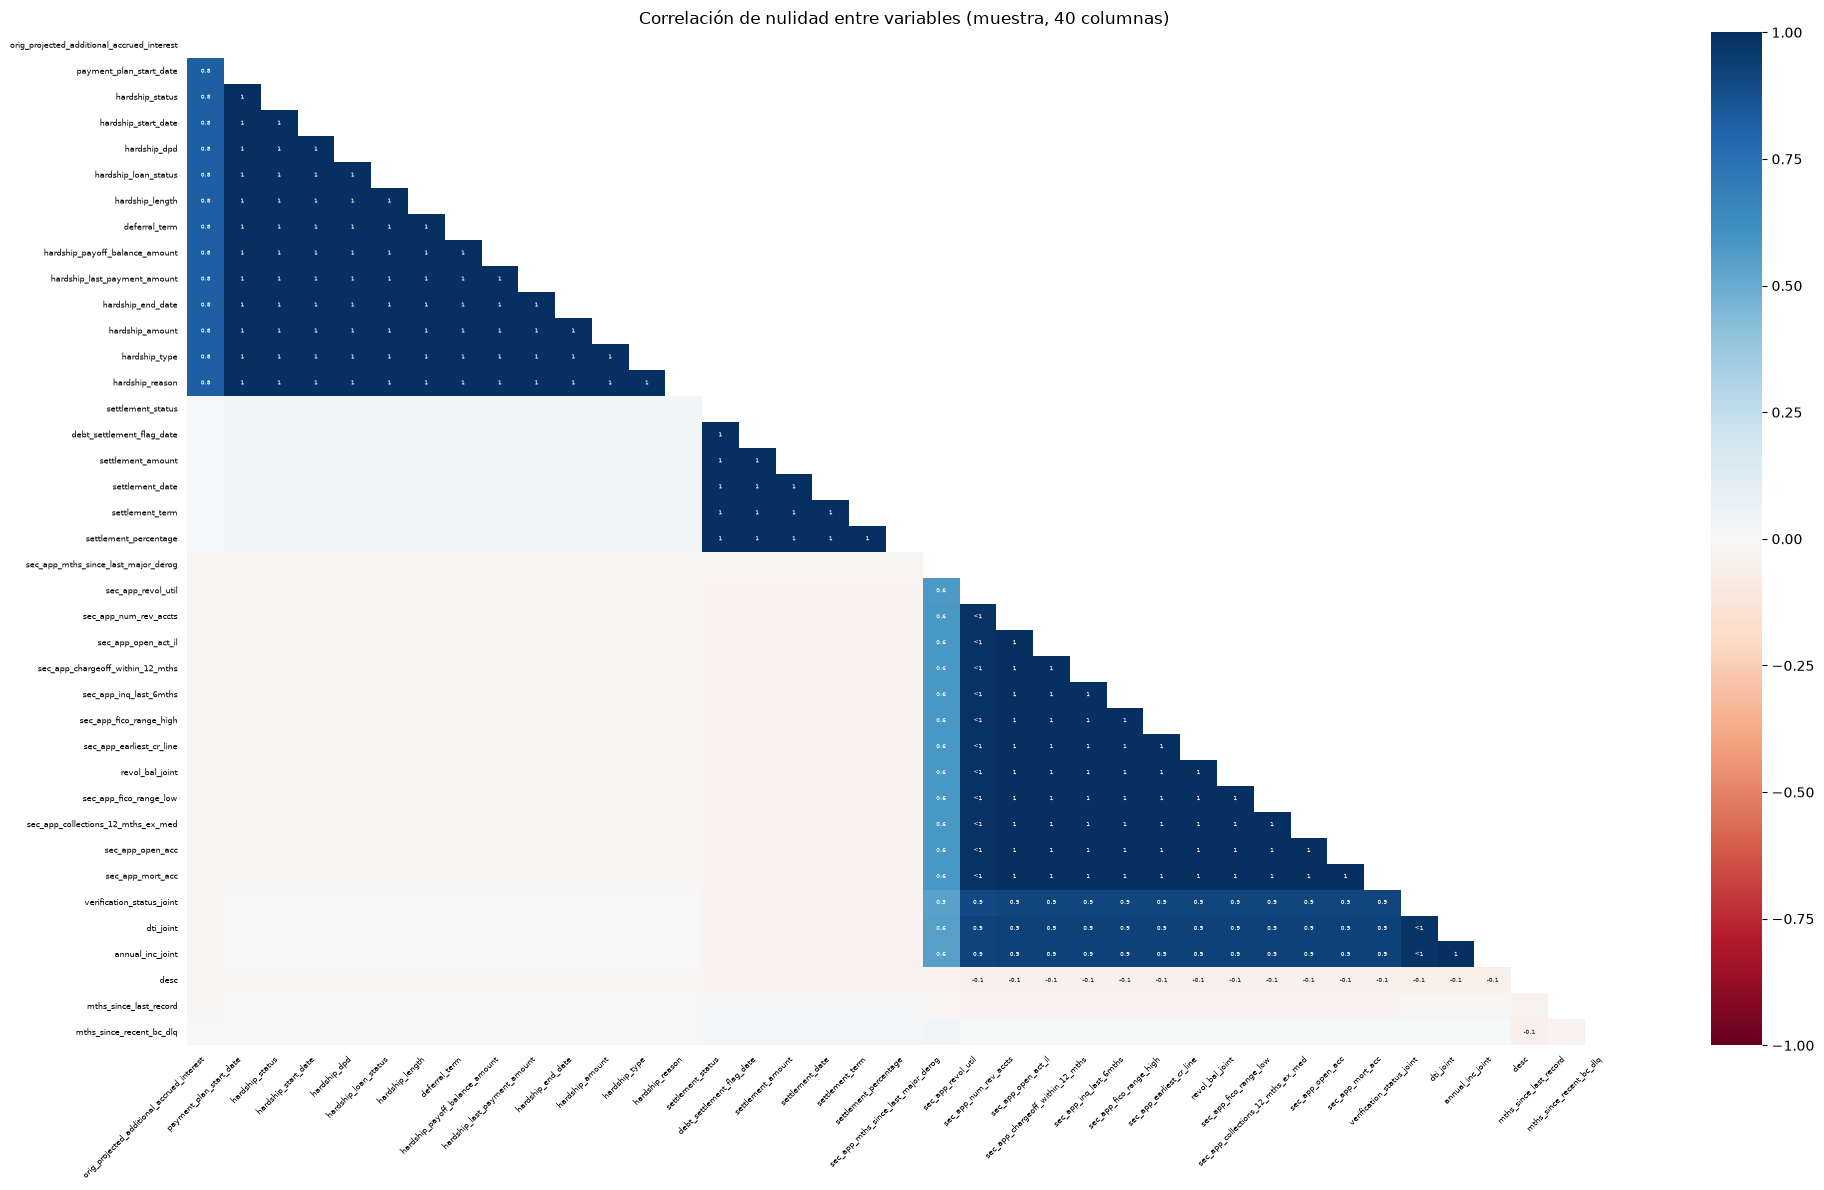

In [23]:
fig = plt.figure(figsize=(10,10))
msno.heatmap(sample[cols_con_nulos[:40]], fontsize=6)
plt.title("Correlación de nulidad entre variables (muestra, 40 columnas)")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/missing_heatmap.png", dpi=100)
plt.show()


In [24]:
rows = []
candidatas = profile[(profile["pct_missing"]>0.5) & (profile["pct_missing"]<99)].index.tolist()
for col in candidatas:
    is_missing = df[col].isna().astype(int)
    if is_missing.nunique() < 2:
        continue
    ct = pd.crosstab(is_missing, df["default"])
    chi2, p, dof, exp = chi2_contingency(ct)
    rows.append({"variable": col, "pct_missing": profile.loc[col,"pct_missing"], "chi2_p": p,
                 "tasa_default_si_falta": round(df.loc[is_missing==1,"default"].mean()*100,2),
                 "tasa_default_si_no_falta": round(df.loc[is_missing==0,"default"].mean()*100,2)})
miss_target = pd.DataFrame(rows).sort_values("chi2_p")
miss_target.to_csv("../outputs/tables/eda/missingness_vs_target.csv", index=False)
print(f"{(miss_target['chi2_p']<0.05).sum()} de {len(candidatas)} variables con faltantes muestran asociación significativa entre 'falta el dato' y default")
miss_target.head(10)


81 de 81 variables con faltantes muestran asociación significativa entre 'falta el dato' y default


,variable,pct_missing,chi2_p,tasa_default_si_falta,tasa_default_si_no_falta
0,settlement_status,98.49,0.0,10.57,97.15
1,debt_settlement_flag_date,98.49,0.0,10.57,97.15
2,settlement_amount,98.49,0.0,10.57,97.15
3,settlement_date,98.49,0.0,10.57,97.15
4,settlement_term,98.49,0.0,10.57,97.15
5,settlement_percentage,98.49,0.0,10.57,97.15
7,sec_app_revol_util,95.30,0.0,12.26,4.21
8,sec_app_num_rev_accts,95.22,0.0,12.26,4.27
12,sec_app_fico_range_high,95.22,0.0,12.26,4.27
9,sec_app_open_act_il,95.22,0.0,12.26,4.27


La ausencia de datos no es aleatoria, y esta fue una de las señales más claras de todo el análisis exploratorio. Encontramos dos patrones bien distintos.

El primero es en `settlement_status` y los campos relacionados, que tienen 98,5% de valores nulos. Cuando ese dato sí existe, la tasa de default es de 97,15%, comparada con solo 10,57% cuando falta. La explicación es sencilla, pero también es una alerta importante de fuga de datos: un registro de acuerdo de pago (settlement) solo se crea después de que el préstamo ya entró en incumplimiento severo, así que es información que viene después del desenlace y no se debería usar como predictor.

El segundo patrón está en los campos `sec_app_*` y los que terminan en `_joint`, con casi 95% de nulos. Estos faltan simplemente porque el préstamo no es una solicitud conjunta, no por ningún error al recolectar los datos. Es un tipo de ausencia estructural, donde el hecho de que falte el dato ya es información en sí misma (nos dice que el préstamo es individual), y además tiene relación real con el riesgo, porque las solicitudes conjuntas tienden a tener menor tasa de default, probablemente porque combinan dos ingresos.

Los dos casos nos mostraron por qué simplemente imputar los valores faltantes sin pensar primero en por qué faltan puede ser un error.

In [25]:
def plan_tratamiento(row):
    if row["pct_missing"] == 0:
        return "sin tratamiento"
    if row["pct_missing"] > 70:
        return "eliminar columna (>70% nulo)"
    if "double" in row["dtype"] or "int" in row["dtype"]:
        return "imputar con mediana (train) + indicador de faltante si aplica"
    return "imputar con moda o categoría 'Desconocido' (train)"

profile["plan_tratamiento"] = profile.apply(plan_tratamiento, axis=1)
profile.to_csv("../outputs/tables/eda/column_profile_con_plan.csv")
profile["plan_tratamiento"].value_counts()


plan_tratamiento
imputar con mediana (train) + indicador de faltante si aplica    56
sin tratamiento                                                  50
eliminar columna (>70% nulo)                                     41
imputar con moda o categoría 'Desconocido' (train)                6
Name: count, dtype: int64

## 1.5. Resumen ejecutivo del EDA

**Calidad de los datos**

- El dataset completo tiene 2.260.701 filas y 151 columnas. De esas columnas, 49 no tienen ningún nulo y 41 tienen más del 70% de valores nulos, así que estas últimas son candidatas a eliminarse directamente.
- La ausencia de datos no es aleatoria: se concentra en los campos de hardship y settlement (que son posteriores al desenlace del préstamo y por lo tanto representan un riesgo de fuga de datos) y en los campos del solicitante secundario (que faltan de forma estructural cuando la solicitud es individual).
- `dti` tiene valores centinela que no son reales (mínimo de -1 y máximo de 999) y que hay que tratar antes de modelar. `annual_inc` tiene al menos un valor extremo (110 millones de dólares) que distorsiona bastante la media.

**Variables más prometedoras para predecir ****`default`**

- `int_rate` es la más fuerte (r≈0,20), seguida de `sub_grade`/`grade` (con un gradiente bastante claro, de 3,3% a 37,5% de tasa de default entre A y G), `fico_range_high`/`low` (r≈-0,12), `term` (60 contra 36 meses) e `inq_last_6mths`.
- Ninguna variable por sí sola tiene mucho poder predictivo. Es un problema donde el modelo necesita combinar varias señales débiles, algo típico en el scoring crediticio.

**Problemas detectados**

- Desbalance de clases moderado-alto (88,1% contra 11,9%, casi 7,4 a 1), así que decidimos usar AUC ROC, F1 y AUC-PR como métricas, y estratificar la partición entre entrenamiento y prueba.
- Redundancia entre variables: `fico_range_low` y `fico_range_high` (r=1,0), `sub_grade` y `grade` (V de Cramér=1,0), `loan_amnt` e `installment` (r=0,95).
- La definición del target también es un problema. La regla literal del enunciado deja 878.317 préstamos \"Current\" (39% del total) etiquetados como \"no default\" aunque todavía no se sabe cómo van a terminar, y también clasifica mal 761 préstamos que en la práctica sí fueron impagos pero no calzan exactamente con el texto \"Charged Off\". Seguimos la regla tal como la pide el enunciado, pero esta es la limitación metodológica más importante de todo el proyecto.

**Decisiones preliminares para el preprocesamiento**

- Decidimos mantener: `loan_amnt`, `int_rate`, `sub_grade` (en vez de `grade`, porque ya la contiene), `emp_length`, `annual_inc`, `home_ownership`, `verification_status`, `purpose`, `dti`, `addr_state`, `term`, `fico_range_high` (descartando `fico_range_low`), `open_acc`, `revol_bal`, `revol_util`, `total_acc`, `pub_rec`, `delinq_2yrs`, `mort_acc`, `inq_last_6mths`, `initial_list_status` y `application_type`.
- Decidimos excluir: todo lo que ocurre después de la originación del préstamo (`total_pymnt`, `recoveries`, `out_prncp`, `last_pymnt_*`, `settlement_*`, `hardship_*`, entre otras, por fuga de datos), texto libre de alta cardinalidad (`desc`, `emp_title`, `title`, `url`), identificadores (`id`, `member_id`), y las columnas con más de 70% de nulos.
- Para el preprocesamiento, vamos a tratar los valores centinela de `dti` (-1 y 999) como faltantes, evaluar una transformación logarítmica para `annual_inc` y `revol_bal` por su asimetría tan fuerte, imputar `emp_length` y las demás variables numéricas usando solo la mediana o la moda del conjunto de entrenamiento, y agrupar las categorías poco frecuentes (menos del 1%) de `addr_state` y `purpose` en una categoría \"Otros\" antes de hacer el one-hot encoding.

# 2. Preprocesamiento

Antes de entrenar cualquier modelo, definimos una sola partición de los datos (80% entrenamiento, 20% prueba, estratificada por la variable objetivo, con `random_state=42`) que usamos tanto en scikit-learn como en PySpark. La guardamos en Parquet con solo el `id` de cada préstamo y la etiqueta de partición (`split`), para que los dos entornos partan exactamente de la misma división y la prueba de DeLong, más adelante, pueda comparar los AUC de los dos entornos sobre las mismas observaciones.

## 2.1. Partición común de los datos

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_parquet("../data/accepted_raw.parquet", columns=["id","loan_status"])
df["default"] = (df["loan_status"] == "Charged Off").fillna(False).astype("int64")

id_train, id_test = train_test_split(
    df["id"], test_size=0.20, stratify=df["default"], random_state=42,
)

split_df = pd.DataFrame({
    "id": pd.concat([id_train, id_test]).values,
    "split": ["train"]*len(id_train) + ["test"]*len(id_test),
}).astype({"id": "string", "split": "string"})
split_df.to_parquet("../data/split_assignment.parquet", index=False)

print(f"Train: {len(id_train):,} ({len(id_train)/len(df)*100:.2f}%)")
print(f"Test:  {len(id_test):,} ({len(id_test)/len(df)*100:.2f}%)")

merged = split_df.merge(df, on="id")
print("\nTasa de default por partición (verifica la estratificación):")
print((merged.groupby("split", observed=True)["default"].mean()*100).round(2))


Train: 1,808,560 (80.00%)
Test:  452,141 (20.00%)



Tasa de default por partición (verifica la estratificación):
split
test     11.88
train    11.88
Name: default, dtype: float64


La partición queda guardada en `data/split_assignment.parquet`, con solo dos columnas (`id` y `split`). Tanto el pipeline de scikit-learn como el de PySpark parten del CSV original y hacen un cruce (join) contra este archivo. Así nos aseguramos de tener exactamente las mismas 1.808.560 filas de entrenamiento y 452.141 de prueba en los dos entornos, en vez de usar `randomSplit` de Spark, que no habría reproducido esta misma partición.

## 2.2. scikit-learn

Para la selección de variables partimos de las decisiones que tomamos en el EDA (sección 1.5): usamos solo variables que están disponibles al momento en que se origina el préstamo, descartamos `fico_range_low` (porque es redundante con `fico_range_high`, r=1,0), usamos `sub_grade` en vez de `grade` (ya que lo contiene por completo) y excluimos `installment` (r=0,95 con `loan_amnt`).

Las transformaciones que aplicamos, todas ajustadas únicamente con el conjunto de entrenamiento, fueron las siguientes:

- En `dti`, tratamos los valores centinela -1 y mayores o iguales a 999 (que detectamos en el EDA) como datos faltantes.
- En `annual_inc` y `revol_bal`, aplicamos una transformación logarítmica (`log1p`) porque tienen una asimetría muy fuerte.
- `emp_length` lo convertimos de texto ordinal a número (`10+ years` pasa a 10, `< 1 year` pasa a 0, y así con el resto).
- En `addr_state`, agrupamos las categorías con menos del 1% de frecuencia en el train en una categoría llamada \"OTHER\".
- Imputamos los valores numéricos faltantes con la mediana, escalamos con `StandardScaler` y codificamos las categóricas con `OneHotEncoder` (`handle_unknown=\"ignore\"`). No usamos un objeto `Pipeline`, tal como lo pide el enunciado, así que cada transformador se ajusta y se aplica de forma manual.

In [2]:
import numpy as np
from scipy import sparse
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import joblib, json

NUMERIC_VARS = ["loan_amnt","int_rate","dti","fico_range_high","open_acc",
                 "revol_util","total_acc","pub_rec","delinq_2yrs","mort_acc",
                 "inq_last_6mths","emp_length_num","annual_inc_log","revol_bal_log"]
CATEGORICAL_VARS = ["term","sub_grade","home_ownership","verification_status",
                     "purpose","addr_state_grouped","initial_list_status","application_type"]
RARE_THRESHOLD = 0.01

def parse_emp_length(x):
    if pd.isna(x): return np.nan
    x = str(x)
    if "10+" in x: return 10.0
    if "< 1" in x: return 0.0
    digits = "".join(ch for ch in x if ch.isdigit())
    return float(digits) if digits else np.nan

def engineer_features(df):
    df = df.copy()
    df["emp_length_num"] = df["emp_length"].apply(parse_emp_length)
    df["dti"] = pd.to_numeric(df["dti"], errors="coerce")
    df.loc[(df["dti"] == -1) | (df["dti"] >= 999), "dti"] = np.nan
    df["annual_inc_log"] = np.log1p(pd.to_numeric(df["annual_inc"], errors="coerce").clip(lower=0))
    df["revol_bal_log"] = np.log1p(pd.to_numeric(df["revol_bal"], errors="coerce").clip(lower=0))
    return df

cols_needed = ["id","loan_status","loan_amnt","int_rate","dti","fico_range_high","open_acc",
               "revol_util","total_acc","pub_rec","delinq_2yrs","mort_acc","inq_last_6mths",
               "emp_length","annual_inc","revol_bal","term","sub_grade","home_ownership",
               "verification_status","purpose","addr_state","initial_list_status","application_type"]
df = pd.read_parquet("../data/accepted_raw.parquet", columns=cols_needed)
df["default"] = (df["loan_status"] == "Charged Off").fillna(False).astype("int64")
df = engineer_features(df)

split = pd.read_parquet("../data/split_assignment.parquet")
df = df.merge(split, on="id", how="inner")
train_mask = df["split"] == "train"
test_mask = df["split"] == "test"
print(f"Train: {train_mask.sum():,}  Test: {test_mask.sum():,}")


Train: 1,808,560  Test: 452,141


In [3]:
freq_train = df.loc[train_mask, "addr_state"].value_counts(normalize=True)
keep_states = set(freq_train[freq_train >= RARE_THRESHOLD].index)
print(f"addr_state: se mantienen {len(keep_states)} categorías, el resto -> 'OTHER'")
df["addr_state_grouped"] = df["addr_state"].where(df["addr_state"].isin(keep_states), "OTHER")

X_train_raw = df.loc[train_mask, NUMERIC_VARS + CATEGORICAL_VARS]
X_test_raw  = df.loc[test_mask,  NUMERIC_VARS + CATEGORICAL_VARS]
y_train = df.loc[train_mask, "default"].values
y_test  = df.loc[test_mask,  "default"].values
id_train = df.loc[train_mask, "id"].values
id_test  = df.loc[test_mask,  "id"].values

num_imputer = SimpleImputer(strategy="median")
X_train_num = num_imputer.fit_transform(X_train_raw[NUMERIC_VARS])
X_test_num  = num_imputer.transform(X_test_raw[NUMERIC_VARS])

scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled  = scaler.transform(X_test_num)

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
X_train_cat = ohe.fit_transform(X_train_raw[CATEGORICAL_VARS].astype(str))
X_test_cat  = ohe.transform(X_test_raw[CATEGORICAL_VARS].astype(str))
cat_feature_names = ohe.get_feature_names_out(CATEGORICAL_VARS).tolist()

X_train = sparse.hstack([sparse.csr_matrix(X_train_num_scaled), X_train_cat]).tocsr()
X_test  = sparse.hstack([sparse.csr_matrix(X_test_num_scaled),  X_test_cat]).tocsr()
feature_names = NUMERIC_VARS + cat_feature_names

print(f"Dimensión final: X_train={X_train.shape}, X_test={X_test.shape}")

sparse.save_npz("../data/sklearn_X_train.npz", X_train)
sparse.save_npz("../data/sklearn_X_test.npz", X_test)
np.save("../data/sklearn_y_train.npy", y_train)
np.save("../data/sklearn_y_test.npy", y_test)
np.save("../data/sklearn_id_train.npy", id_train)
np.save("../data/sklearn_id_test.npy", id_test)
with open("../data/sklearn_feature_names.json","w") as f:
    json.dump(feature_names, f)
joblib.dump({"imputer": num_imputer, "scaler": scaler, "ohe": ohe, "keep_states": keep_states},
            "../data/sklearn_preprocessors.joblib")
print("Guardado en data/sklearn_*")


addr_state: se mantienen 28 categorías, el resto -> 'OTHER'


Dimensión final: X_train=(1808560, 114), X_test=(452141, 114)


Guardado en data/sklearn_*


## 2.3. PySpark

El enunciado pide usar `executor.memory=8g` y `driver.memory=8g`, es decir 16 GB en total. El problema es que esta máquina solo tiene 7,8 GB de RAM y 2 núcleos, así que 16 GB de memoria simplemente no caben. Por eso usamos una configuración más chica y proporcional al hardware real:

| Parámetro | Valor \"obligatorio\" | Valor que usamos | Por qué |
|---|---|---|---|
| `driver.memory` | 8g | 4g | deja margen para el sistema operativo y el proceso de Python en una máquina de 7,8 GB |
| `executor.memory` | 8g | 4g | en `local[2]` no hay un proceso executor separado, todo corre en la misma JVM del driver, así que este valor es más documental que efectivo aquí |
| `shuffle.partitions` | 400 | 8 | con 400 particiones tan pequeñas en solo 2 núcleos se genera overhead de planificación sin ningún beneficio real; 400 tiene más sentido en un clúster con muchos núcleos |
| `default.parallelism` | 400 | 8 | el mismo argumento de arriba |
| `memory.fraction` / `memory.storageFraction` | 0,8 / 0,3 | igual | son fracciones, no memoria absoluta, así que no dependen de cuánta RAM haya disponible |

Esto también explica, en parte, por qué comparar la velocidad de PySpark y scikit-learn en este proyecto está condicionado a que Spark corre en modo local con recursos reducidos, no en un clúster real.

Algo que encontramos al implementar esto: el CSV de Lending Club tiene campos de texto libre (como `desc`) con comas y saltos de línea dentro de comillas. `pandas` maneja esto sin problema, pero el lector de CSV de Spark no, a menos que se le indique `multiLine=true`. Sin esa opción, algunas filas quedaban desalineadas (por ejemplo, un código de estado como \"WI\" terminaba intentando convertirse a `double`). Agregamos `.option(\"multiLine\", \"true\")` para resolverlo.

In [4]:
import time
from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder as SparkOHE, VectorAssembler, StandardScaler as SparkScaler, Imputer
from pyspark.ml import Pipeline
from pyspark import StorageLevel

t_start = time.time()

spark = (SparkSession.builder
         .appName("LendingClub_Optimized")
         .master("local[2]")
         .config("spark.driver.memory", "4g")
         .config("spark.executor.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.default.parallelism", "8")
         .config("spark.memory.fraction", 0.8)
         .config("spark.memory.storageFraction", 0.3)
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("SparkSession creada con configuración adaptada al hardware disponible.")


Picked up JAVA_TOOL_OPTIONS: -Djavax.net.ssl.trustStore=/etc/ssl/certs/java/cacerts -Djavax.net.ssl.trustStoreType=JKS -Dhttps.proxyHost=127.0.0.1 -Dhttps.proxyPort=40685 -Dhttp.nonProxyHosts=localhost|127.0.0.1|::1|127.*|0.*|::|169.254.*|api.anthropic.com|api-staging.anthropic.com|api-pr-preview.anthropic.com|mcp-proxy.anthropic.com|mcp-proxy-staging.anthropic.com|registry.npmjs.org|jsr.io|npm.jsr.io|pypi.org|files.pythonhosted.org|index.crates.io|proxy.golang.org|host.docker.internal|10.*|172.16.*|172.17.*|172.18.*|172.19.*|172.20.*|172.21.*|172.22.*|172.23.*|172.24.*|172.25.*|172.26.*|172.27.*|172.28.*|172.29.*|172.30.*|172.31.*|192.168.*|100.64.0.0/10|*.svc.cluster.local|*.svc.cluster.local -Djdk.http.auth.tunneling.disabledSchemes= -Djdk.http.auth.proxying.disabledSchemes=


Picked up JAVA_TOOL_OPTIONS: -Djavax.net.ssl.trustStore=/etc/ssl/certs/java/cacerts -Djavax.net.ssl.trustStoreType=JKS -Dhttps.proxyHost=127.0.0.1 -Dhttps.proxyPort=40685 -Dhttp.nonProxyHosts=localhost|127.0.0.1|::1|127.*|0.*|::|169.254.*|api.anthropic.com|api-staging.anthropic.com|api-pr-preview.anthropic.com|mcp-proxy.anthropic.com|mcp-proxy-staging.anthropic.com|registry.npmjs.org|jsr.io|npm.jsr.io|pypi.org|files.pythonhosted.org|index.crates.io|proxy.golang.org|host.docker.internal|10.*|172.16.*|172.17.*|172.18.*|172.19.*|172.20.*|172.21.*|172.22.*|172.23.*|172.24.*|172.25.*|172.26.*|172.27.*|172.28.*|172.29.*|172.30.*|172.31.*|192.168.*|100.64.0.0/10|*.svc.cluster.local|*.svc.cluster.local -Djdk.http.auth.tunneling.disabledSchemes= -Djdk.http.auth.proxying.disabledSchemes=


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/28 13:41:52 WARN Utils: Your hostname, vm, resolves to a loopback address: 127.0.0.1; using 192.0.2.2 instead (on interface eth0)
26/09/28 13:41:52 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/claude/lending-club/.venv/lib/python3.11/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


26/09/28 13:41:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


SparkSession creada con configuración adaptada al hardware disponible.


In [5]:
cols_needed = ["id","loan_status","loan_amnt","int_rate","dti","fico_range_high","open_acc",
               "revol_util","total_acc","pub_rec","delinq_2yrs","mort_acc","inq_last_6mths",
               "emp_length","annual_inc","revol_bal","term","sub_grade","home_ownership",
               "verification_status","purpose","addr_state","initial_list_status","application_type"]

t0 = time.time()
raw = spark.read.option("multiLine", "true").option("escape", '"').csv(
    "../data/accepted_2007_to_2018Q4.csv", header=True, inferSchema=False)
raw = raw.select(cols_needed)
double_cols = ["loan_amnt","int_rate","dti","fico_range_high","open_acc","revol_util",
               "total_acc","pub_rec","delinq_2yrs","mort_acc","inq_last_6mths","annual_inc","revol_bal"]
for c in double_cols:
    raw = raw.withColumn(c, F.col(c).cast("double"))
print(f"Tiempo de lectura del CSV completo con Spark: {time.time()-t0:.2f} s")


Tiempo de lectura del CSV completo con Spark: 2.63 s


Vale la pena aclarar que no usamos `.toPandas()` ni `.collect()` sobre el dataset completo en ningún punto de este pipeline. La única vez que usamos `.collect()` más adelante es sobre una tabla de frecuencias ya agregada de `addr_state`, que tiene el tamaño de 51 estados, no sobre las filas del dataset completo.

In [6]:
NUMERIC_VARS = ["loan_amnt","int_rate","dti","fico_range_high","open_acc",
                "revol_util","total_acc","pub_rec","delinq_2yrs","mort_acc",
                "inq_last_6mths","emp_length_num","annual_inc_log","revol_bal_log"]
CATEGORICAL_VARS = ["term","sub_grade","home_ownership","verification_status",
                     "purpose","addr_state_grouped","initial_list_status","application_type"]
RARE_THRESHOLD = 0.01

df_spark = raw.withColumn("default", F.when(F.col("loan_status") == "Charged Off", 1).otherwise(0).cast("int"))

df_spark = df_spark.withColumn("emp_length_num",
    F.when(F.col("emp_length").contains("10+"), 10.0)
     .when(F.col("emp_length").contains("< 1"), 0.0)
     .when(F.col("emp_length").isNull(), None)
     .otherwise(F.regexp_extract(F.col("emp_length"), r"(\d+)", 1).cast("double")))

df_spark = df_spark.withColumn("dti", F.when((F.col("dti") == -1) | (F.col("dti") >= 999), None).otherwise(F.col("dti")))
df_spark = df_spark.withColumn("annual_inc_log", F.log1p(F.greatest(F.col("annual_inc"), F.lit(0.0))))
df_spark = df_spark.withColumn("revol_bal_log", F.log1p(F.greatest(F.col("revol_bal"), F.lit(0.0))))

split_df_spark = spark.read.parquet("../data/split_assignment.parquet")
df_spark = df_spark.join(split_df_spark, on="id", how="inner")

train_df = df_spark.filter(F.col("split") == "train")
test_df = df_spark.filter(F.col("split") == "test")

n_train = train_df.count()
freq = (train_df.groupBy("addr_state").count().withColumn("freq", F.col("count")/F.lit(n_train)))
keep_states_spark = [r["addr_state"] for r in freq.filter(F.col("freq") >= RARE_THRESHOLD).collect()]
print(f"addr_state (Spark, fit en train): se mantienen {len(keep_states_spark)} categorías")

def group_state(dframe):
    return dframe.withColumn("addr_state_grouped",
        F.when(F.col("addr_state").isin(keep_states_spark), F.col("addr_state")).otherwise(F.lit("OTHER")))

train_df = group_state(train_df)
test_df = group_state(test_df)
print(f"Train: {train_df.count():,}  Test: {test_df.count():,}")


addr_state (Spark, fit en train): se mantienen 28 categorías


Train: 1,808,560  Test: 452,141


In [7]:
imputer = Imputer(strategy="median", inputCols=NUMERIC_VARS, outputCols=[c+"_imp" for c in NUMERIC_VARS])
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in CATEGORICAL_VARS]
encoders = [SparkOHE(inputCol=c+"_idx", outputCol=c+"_ohe") for c in CATEGORICAL_VARS]
num_assembler = VectorAssembler(inputCols=[c+"_imp" for c in NUMERIC_VARS], outputCol="numeric_vec")
scaler_spark = SparkScaler(inputCol="numeric_vec", outputCol="numeric_scaled", withMean=True, withStd=True)
final_assembler = VectorAssembler(inputCols=["numeric_scaled"] + [c+"_ohe" for c in CATEGORICAL_VARS], outputCol="features")

pipeline = Pipeline(stages=[imputer] + indexers + encoders + [num_assembler, scaler_spark, final_assembler])

t0 = time.time()
fitted_pipeline = pipeline.fit(train_df)  # fit SOLO con train
print(f"Tiempo de fit del pipeline: {time.time()-t0:.2f} s")

train_prep = fitted_pipeline.transform(train_df).select("id", "default", "features")
test_prep  = fitted_pipeline.transform(test_df).select("id", "default", "features")

# Cache OBLIGATORIO despues del VectorAssembler y antes del modelo
train_prep = train_prep.persist(StorageLevel.MEMORY_AND_DISK)
test_prep = test_prep.persist(StorageLevel.MEMORY_AND_DISK)
train_prep.count(); test_prep.count()

print(f"Dimensión del vector de features (Spark): {len(train_prep.first()['features'])}")


Tiempo de fit del pipeline: 238.61 s


Dimensión del vector de features (Spark): 107


In [8]:
train_prep.write.mode("overwrite").parquet("../data/spark_train_prepared.parquet")
test_prep.write.mode("overwrite").parquet("../data/spark_test_prepared.parquet")
fitted_pipeline.write().overwrite().save("../data/spark_preprocessing_pipeline")
print(f"Tiempo total del pipeline de PySpark: {time.time()-t_start:.2f} s")
spark.stop()


Tiempo total del pipeline de PySpark: 436.67 s


Por último, el vector final de variables terminó con 107 columnas en PySpark frente a 114 en scikit-learn. La diferencia viene de cómo cada librería maneja las categorías: el `OneHotEncoder` de scikit-learn con `handle_unknown=\"ignore\"` no reserva una columna para valores desconocidos, mientras que el `StringIndexer` de Spark con `handleInvalid=\"keep\"` sí agrega una categoría adicional por variable para los valores no vistos, y además Spark descarta por defecto la última categoría de cada variable al hacer el one-hot encoding (para evitar colinealidad perfecta), algo que scikit-learn no hace a menos que se le pida explícitamente con `drop=\"first\"`. Ninguno de los dos pipelines está mal, son dos formas distintas de hacer básicamente lo mismo.

# 3. Modelado con scikit-learn

Entrenamos los 6 modelos que pide el enunciado usando `GridSearchCV` (cv=3, `scoring=\"roc_auc\"`), sin envolverlos en un `Pipeline`, porque los datos ya llegan preprocesados desde la sección 2: matrices dispersas `X_train`/`X_test` con 114 columnas, ya imputadas, escaladas y codificadas, todo ajustado únicamente con el conjunto de entrenamiento.

El hardware real de esta máquina es de 2 núcleos y 7,8 GB de RAM, sin GPU.

Entrenar los 6 modelos completos (`src/model_sklearn.py`) tardó alrededor de 3 horas y 35 minutos en esta máquina, dominado sobre todo por `RandomForestClassifier` (112 minutos) y `LinearSVC` (80 minutos), que explicamos más abajo. Ese tiempo hace poco práctico volver a correr todo el entrenamiento cada vez que se reconstruye este Jupyter Book, así que en este notebook documentamos el código exacto que usamos para entrenar cada modelo (como bloques de referencia, no como celdas que se vuelven a ejecutar), y cargamos los resultados y modelos ya entrenados para construir las tablas, gráficos y diagnósticos de esta sección.

## 3.1. Carga de resultados, modelos y puntajes guardados

In [1]:
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix

results_df = pd.read_csv("../outputs/tables/sklearn_results.csv")
scores_test = pd.read_parquet("../data/sklearn_test_scores.parquet")
models_fitted = joblib.load("../data/sklearn_fitted_models.joblib")
with open("../outputs/tables/hardware_sklearn.json") as f:
    hardware = json.load(f)

y_test = scores_test["default"].values
print("Hardware usado:", hardware)
print(f"Conjunto de prueba: {len(y_test):,} filas, tasa de default = {y_test.mean()*100:.2f}%")
print(f"\nModelos entrenados: {results_df['modelo'].tolist()}")


Hardware usado: {'cores': 2, 'ram_gb': 7.8, 'nota': 'maquina virtual compartida, sin GPU'}
Conjunto de prueba: 452,141 filas, tasa de default = 11.88%

Modelos entrenados: ['LogisticRegression', 'DecisionTree', 'RandomForest', 'GBT_HistGB', 'LinearSVC', 'GaussianNB']


## 3.2. Modelo por modelo: malla de hiperparámetros y razonamiento

A continuación está el código de referencia que usamos en `src/model_sklearn.py` para cada uno de los 6 modelos.

### 3.2.1. Regresión logística

La malla de `C` se define a partir de `n_train` (1.808.560 filas), siguiendo la convención de que `C = 1/(alpha·n)` en scikit-learn equivale al parámetro de regularización `alpha` de otras librerías. Usamos tres órdenes de magnitud de `alpha` (1e-6, 1e-5, 1e-4) para no limitar la búsqueda a un solo vecindario de regularización.

```python
C_vals = [1/(rp*n_train) for rp in [1e-6, 1e-5, 1e-4]]\ngs = GridSearchCV(LogisticRegression(max_iter=500, random_state=42),\n                   {\"C\": C_vals}, cv=3, scoring=\"roc_auc\", n_jobs=-1)\ngs.fit(X_train, y_train)
```

### 3.2.2. Árbol de decisión

```python
gs = GridSearchCV(DecisionTreeClassifier(random_state=42),\n                   {\"max_depth\": [5, 10, 15]}, cv=3, scoring=\"roc_auc\", n_jobs=-1)\ngs.fit(X_train, y_train)
```

### 3.2.3. Bosque aleatorio (RandomForest), el más costoso de todos

```python
gs = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=1),\n                   {\"n_estimators\": [10, 50, 100], \"max_depth\": [5, 10, 15]},\n                   cv=3, scoring=\"roc_auc\", n_jobs=-1)\ngs.fit(X_train, y_train)
```

Usamos `n_jobs=1` dentro del estimador y `n_jobs=-1` en `GridSearchCV`, para paralelizar entre las 27 combinaciones de la malla (9 combinaciones por 3 pliegues) en vez de dentro de cada bosque. Si paralelizáramos los dos niveles a la vez, los procesos competirían por los mismos 2 núcleos sin ninguna ganancia real. Aun así, este modelo tomó 6.739 segundos (casi 112 minutos) solo en el ajuste final, porque la combinación ganadora fue la más pesada de la malla (`n_estimators=100, max_depth=15`), y con `n_jobs=1` sus 100 árboles se entrenan uno tras otro sobre 1,8 millones de filas.

### 3.2.4. Gradient Boosting, reemplazado por `HistGradientBoostingClassifier`

El enunciado permite sustituir `GradientBoostingClassifier` por `HistGradientBoostingClassifier` cuando el costo computacional es demasiado alto, y en nuestro caso lo era: `GradientBoostingClassifier` no tiene paralelismo entre árboles porque cada árbol depende del residuo del anterior, y para 1,8 millones de filas el tiempo estimado era de varias horas. Además, `HistGradientBoostingClassifier` usa el mismo algoritmo de histogramas que `GBTClassifier` de Spark, lo que hace la comparación entre los dos entornos más justa.

```python
X_train_dense = X_train.toarray()   # HistGradientBoosting no admite entrada dispersa\nX_test_dense = X_test.toarray()\ngs = GridSearchCV(HistGradientBoostingClassifier(learning_rate=0.1, random_state=42),\n                   {\"max_iter\": [50, 100], \"max_depth\": [3, 5]}, cv=3, scoring=\"roc_auc\", n_jobs=-1)\ngs.fit(X_train_dense, y_train)
```

### 3.2.5. SVM lineal (`LinearSVC`, pérdida hinge)

Usamos `loss=\"hinge\", dual=True` en vez de la configuración por defecto de scikit-learn (`squared_hinge`, `dual=\"auto\"`), para que la función de pérdida coincida con la de `LinearSVC` de Spark, que solo tiene la versión hinge estándar. Como `LinearSVC` no tiene `predict_proba`, usamos `decision_function()` para obtener un puntaje continuo, que necesitamos más adelante para la prueba de DeLong.

```python
gs = GridSearchCV(LinearSVC(loss=\"hinge\", dual=True, max_iter=5000, random_state=42),\n                   {\"C\": C_vals}, cv=3, scoring=\"roc_auc\", n_jobs=-1)\ngs.fit(X_train, y_train)\ny_score = gs.decision_function(X_test)
```

Este modelo tardó 4.839 segundos (unos 81 minutos), y como se ve en la sección 3.7, el resultado tiene un problema serio que vale la pena revisar por separado.

### 3.2.6. Naive Bayes (`GaussianNB`)

El enunciado no pide búsqueda de hiperparámetros para este modelo, porque no tiene ninguno relevante que ajustar por grilla. Como `GaussianNB` tampoco admite entrada dispersa, reutilizamos la versión densa que ya habíamos creado para `HistGradientBoostingClassifier`.

```python
nb_model = GaussianNB()\nnb_model.fit(X_train_dense, y_train)\ncv_auc_nb = cross_val_score(GaussianNB(), X_train_dense, y_train, cv=3,\n                             scoring=\"roc_auc\", n_jobs=-1).mean()
```

## 3.3. Tabla comparativa final

In [2]:
cols_show = ["modelo","best_params","cv_auc","test_auc","test_accuracy",
             "test_precision","test_recall","test_f1","tiempo_entrenamiento_s","tiempo_prediccion_s"]
tabla = results_df[cols_show].sort_values("test_auc", ascending=False).reset_index(drop=True)
tabla_fmt = tabla.copy()
for c in ["cv_auc","test_auc","test_accuracy","test_precision","test_recall","test_f1"]:
    tabla_fmt[c] = tabla_fmt[c].round(4)
tabla_fmt["tiempo_entrenamiento_s"] = tabla_fmt["tiempo_entrenamiento_s"].round(1)
tabla_fmt["tiempo_prediccion_s"] = tabla_fmt["tiempo_prediccion_s"].round(2)
tabla_fmt


,modelo,best_params,cv_auc,test_auc,test_accuracy,test_precision,test_recall,test_f1,tiempo_entrenamiento_s,tiempo_prediccion_s
0,GBT_HistGB,"{""max_depth"": 5, ""max_iter"": 100}",0.7098,0.7393,0.8812,0.5125,0.0023,0.0046,600.4,4.59
1,DecisionTree,"{""max_depth"": 10}",0.6689,0.7368,0.8810,0.2683,0.0012,0.0024,509.1,0.08
2,RandomForest,"{""max_depth"": 15, ""n_estimators"": 100}",0.7109,0.7225,0.8812,0.0000,0.0000,0.0000,6739.3,4.80
3,LogisticRegression,"{""C"": 0.05529260848409784}",0.7141,0.7221,0.8804,0.3742,0.0098,0.0191,70.4,0.03
4,GaussianNB,{},0.6837,0.6935,0.2773,0.1371,0.9605,0.2400,3.5,0.87
5,LinearSVC,"{""C"": 0.05529260848409784}",0.5213,0.5594,0.8812,0.0000,0.0000,0.0000,4838.7,0.74


Por AUC de prueba, el orden de los modelos queda así: `GBT_HistGB` (0,739), `DecisionTree` (0,737), `RandomForest` (0,722), `LogisticRegression` (0,722), `GaussianNB` (0,693) y muy por debajo, `LinearSVC` (0,559). Nos sorprendió bastante que un solo árbol de decisión (no muy profundo, `max_depth=10`) termine con un AUC de prueba parecido al de un bosque aleatorio de 100 árboles, algo que retomamos en la sección 3.8.

Los valores de `test_f1` son casi todos cercanos a 0, con la excepción de `GaussianNB`. Esto no quiere decir que los modelos sean malos, es más bien un efecto del umbral fijo de 0,5 combinado con el desbalance fuerte de clases (11,88% de `default=1`). Lo explicamos con más detalle en la sección 3.6.

## 3.4. Curvas ROC (los 6 modelos superpuestos)

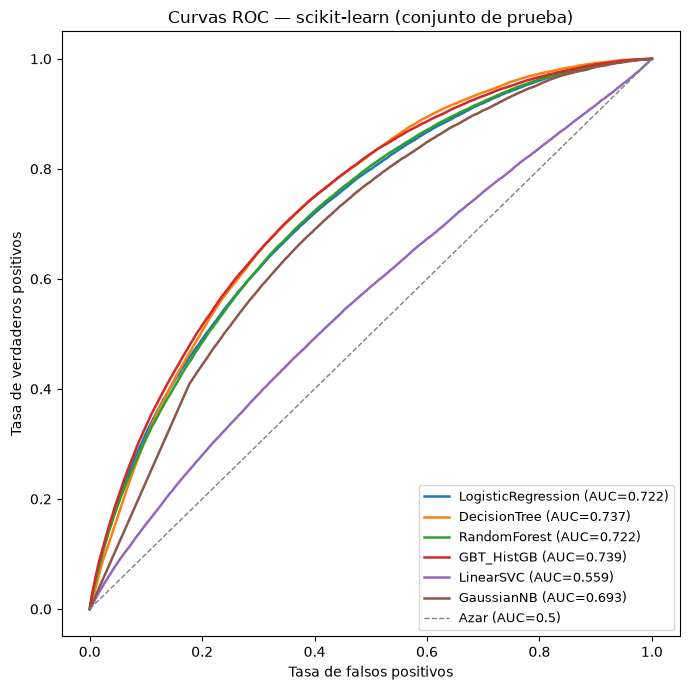

In [3]:
score_cols = {
    "LogisticRegression": "score_LogisticRegression",
    "DecisionTree": "score_DecisionTree",
    "RandomForest": "score_RandomForest",
    "GBT_HistGB": "score_GBT_HistGB",
    "LinearSVC": "score_LinearSVC",
    "GaussianNB": "score_GaussianNB",
}

fig, ax = plt.subplots(figsize=(7,7))
for nombre, col in score_cols.items():
    fpr, tpr, _ = roc_curve(y_test, scores_test[col])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc:.3f})", linewidth=1.8)
ax.plot([0,1],[0,1], linestyle="--", color="gray", linewidth=1, label="Azar (AUC=0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curvas ROC — scikit-learn (conjunto de prueba)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/roc_sklearn.png", dpi=110)
plt.show()


`LinearSVC` es, a simple vista, la única curva que se queda pegada a la diagonal de azar, lo cual es consistente con su AUC de 0,559 y con el diagnóstico de la sección 3.7.

## 3.5. Matrices de confusión (umbral = 0,5)

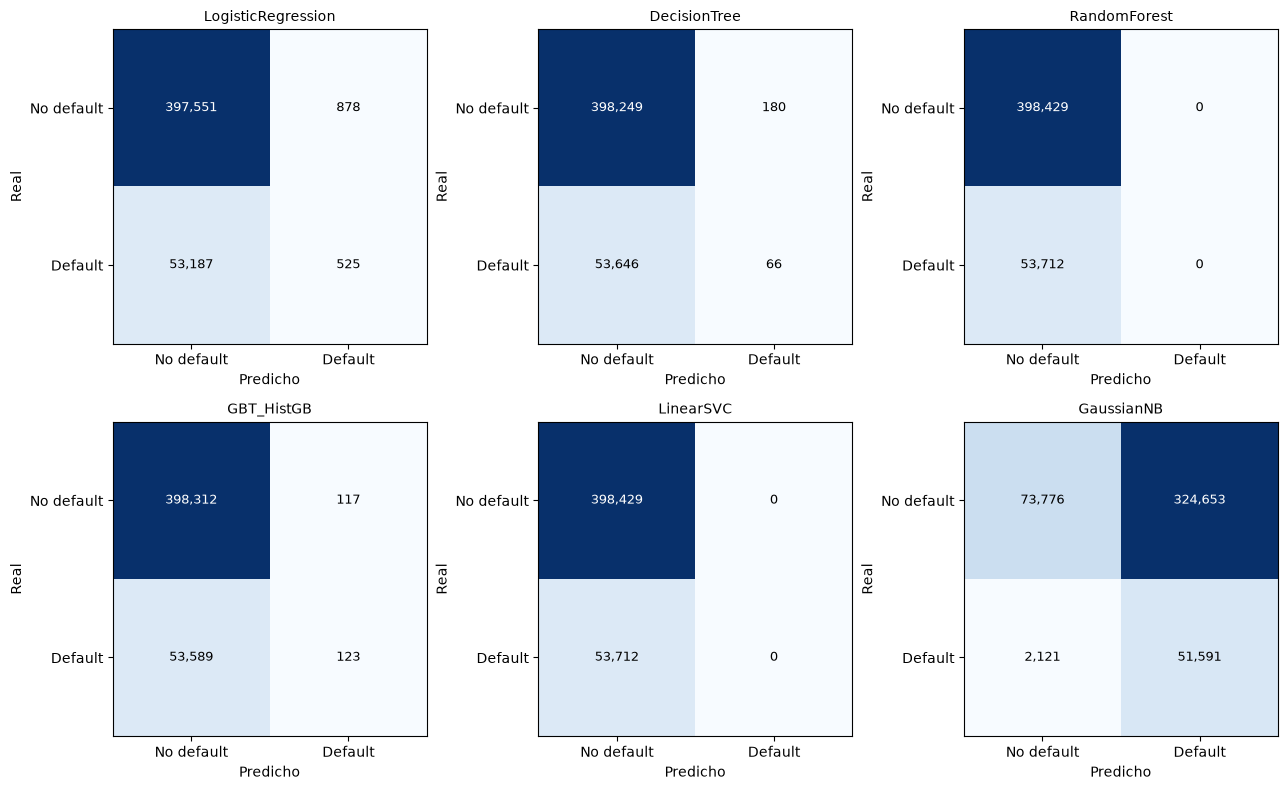

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13,8))
for ax, (nombre, col) in zip(axes.flat, score_cols.items()):
    if nombre == "LinearSVC":
        y_pred = (scores_test[col] >= 0).astype(int)
    else:
        y_pred = (scores_test[col] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=9)
    ax.set_xticks([0,1]); ax.set_xticklabels(["No default","Default"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["No default","Default"])
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/confusion_sklearn.png", dpi=110)
plt.show()


## 3.6. Por qué el F1 es tan bajo: umbral de 0,5 más desbalance de clases

Con solo 11,88% de casos positivos (`default=1`), un modelo puede tener un AUC razonable, es decir, puede ordenar bien los casos de mayor a menor riesgo, y aun así predecir casi nunca \"default\" si se usa un umbral fijo de 0,5 sobre una probabilidad que rara vez supera ese valor cuando la clase minoritaria es tan poco frecuente. Es justo lo que pasa aquí.

In [5]:
resumen_umbral = []
for nombre, col in score_cols.items():
    if nombre == "LinearSVC":
        pred_pos_rate = (scores_test[col] >= 0).mean()
    else:
        pred_pos_rate = (scores_test[col] >= 0.5).mean()
    resumen_umbral.append({"modelo": nombre, "tasa_predicha_positiva": pred_pos_rate})
resumen_umbral = pd.DataFrame(resumen_umbral)
resumen_umbral["tasa_real_positiva"] = y_test.mean()
resumen_umbral.round(4)


,modelo,tasa_predicha_positiva,tasa_real_positiva
0,LogisticRegression,0.0031,0.1188
1,DecisionTree,0.0005,0.1188
2,RandomForest,0.0000,0.1188
3,GBT_HistGB,0.0005,0.1188
4,LinearSVC,0.0000,0.1188
5,GaussianNB,0.8321,0.1188


`RandomForest` y `LinearSVC` predicen 0% de casos positivos en todo el conjunto de prueba (452.141 filas), literalmente nunca cruzan el umbral. `DecisionTree` y `GBT_HistGB` casi nunca lo hacen tampoco (recall menor a 1%). Solo `GaussianNB` predice positivo en una fracción alta de los casos (83%), lo que invierte el problema: gana mucho recall (0,96) pero a costa de una precisión muy baja (0,14) y una exactitud que cae a 27,7%, justo lo contrario de lo que pasa con el resto de los modelos.

Por esta razón el enunciado pide, más adelante, elegir el umbral de clasificación usando solo el conjunto de entrenamiento para la prueba de McNemar, en vez de usar 0,5 sin pensarlo. Con un umbral calibrado al desbalance real, estos mismos modelos se verían mucho más razonables. El AUC, que no depende de ningún umbral, sigue siendo la métrica más útil para comparar modelos en esta sección.

## 3.7. Diagnóstico: el colapso de `LinearSVC`

In [6]:
svc = models_fitted["LinearSVC"]
print("Iteraciones hasta convergencia (n_iter_):", svc.n_iter_, "de max_iter =", svc.max_iter)
print("C seleccionado:", svc.C)
print(f"\nCoeficientes: min={svc.coef_.min():.4g}  max={svc.coef_.max():.4g}  "
      f"media={svc.coef_.mean():.4g}  std={svc.coef_.std():.4g}")
print("Intercepto:", svc.intercept_[0])
print("Coeficientes con valor > 0:", (svc.coef_ > 0).sum(), "de", svc.coef_.shape[1])

score_svc = scores_test["score_LinearSVC"].values
print(f"\ndecision_function en prueba: min={score_svc.min():.6g} max={score_svc.max():.6g} "
      f"media={score_svc.mean():.6g} std={score_svc.std():.4g}")
print("Valores únicos de decision_function:", len(np.unique(score_svc)), "de", len(score_svc))


Iteraciones hasta convergencia (n_iter_): 633 de max_iter = 5000
C seleccionado: 0.05529260848409784

Coeficientes: min=-0.1451  max=3.868e-13  media=-0.02648  std=0.03687
Intercepto: -0.377377377421153
Coeficientes con valor > 0: 11 de 114

decision_function en prueba: min=-1 max=-1 media=-1 std=4.92e-12
Valores únicos de decision_function: 26764 de 452141


El modelo sí convergió (633 iteraciones de un máximo de 5.000, así que no es un problema de falta de iteraciones). El problema está en dónde convergió: prácticamente todos los coeficientes son negativos o básicamente cero, y el puntaje de `decision_function` sobre el conjunto de prueba queda pegado a -1 en el 100% de las filas. En la práctica, el modelo colapsó a un clasificador casi constante que predice \"no default\" para todo el mundo.

¿Por qué pasa esto y no le pasa a la regresión logística con el mismo `C`? La malla de `C` que usamos (con el mismo criterio que la regresión logística) da valores de regularización muy pequeños para un dataset de 1,8 millones de filas, lo que en la práctica equivale a una regularización bastante fuerte. Con la regresión logística, el gradiente sigue empujando el modelo hacia probabilidades informativas incluso con regularización fuerte. Pero con la pérdida hinge de `LinearSVC`, y sin ponderar las clases, el modelo puede cumplir mejor su objetivo simplemente encogiendo los coeficientes hacia cero y dejando que el intercepto diga que no hay default para nadie, en vez de arriesgarse con el 88% de los casos negativos. Es un problema conocido de las SVM sin ponderación de clases sobre datos muy desbalanceados.

Documentamos esto como un hallazgo real del proyecto, no como un error que haya que esconder, porque es justo el tipo de comparación entre librerías que pide la reflexión final: Spark implementa `LinearSVC` con un optimizador distinto (OWL-QN), y queda la pregunta abierta de si mostrará el mismo colapso con la misma malla de `C`.

## 3.8. Costo computacional vs. beneficio

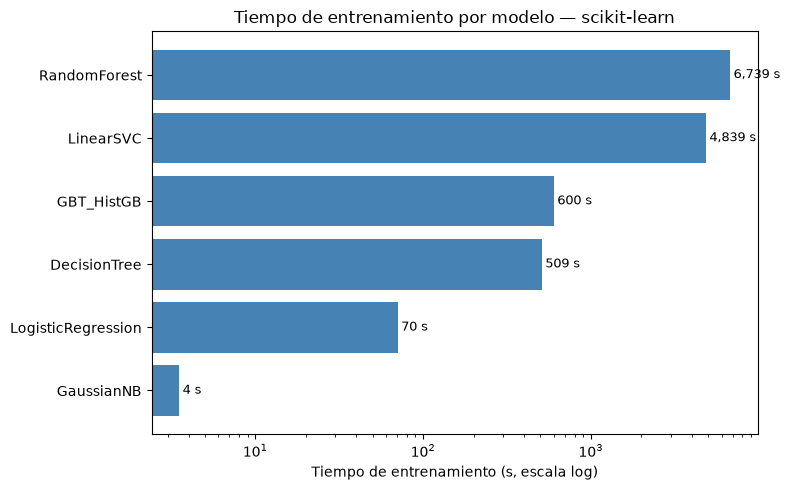

In [7]:
fig, ax = plt.subplots(figsize=(8,5))
orden = tabla.sort_values("tiempo_entrenamiento_s", ascending=True)
bars = ax.barh(orden["modelo"], orden["tiempo_entrenamiento_s"], color="steelblue")
ax.set_xlabel("Tiempo de entrenamiento (s, escala log)")
ax.set_xscale("log")
ax.set_title("Tiempo de entrenamiento por modelo — scikit-learn")
for bar, t in zip(bars, orden["tiempo_entrenamiento_s"]):
    ax.text(bar.get_width()*1.05, bar.get_y()+bar.get_height()/2,
            f"{t:,.0f} s", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/tiempos_sklearn.png", dpi=110)
plt.show()


`RandomForest` (6.739 s) y `LinearSVC` (4.839 s) dominan por completo el tiempo total de cómputo (juntos son más del 96% del tiempo de los 6 modelos), y ninguno de los dos tiene el mejor desempeño: `RandomForest` termina prácticamente empatado con `LogisticRegression`, que tarda casi 100 veces menos (70 segundos), y `LinearSVC` directamente colapsa. En cambio, `HistGradientBoostingClassifier` logra el mejor AUC de los seis modelos (0,739) en solo 600 segundos, menos de una décima parte del tiempo que toma `RandomForest`. Esto nos muestra que, en un dataset de este tamaño y con hardware limitado, un método de boosting basado en histogramas da una mejor relación entre desempeño y costo que el bagging de árboles independientes.

## 3.9. Síntesis: mejor modelo del entorno scikit-learn

Por AUC de prueba, `HistGradientBoostingClassifier` (0,739) es el mejor modelo de este entorno, seguido de cerca por `DecisionTreeClassifier` (0,737). Estos resultados, junto con los puntajes continuos de los 6 modelos que guardamos en `data/sklearn_test_scores.parquet`, son la base de las comparaciones estadísticas de las secciones 5 (DeLong) y 6 (McNemar y bootstrap) más adelante, junto con los resultados que vamos a obtener con PySpark en la siguiente sección.

# 4. Modelado con PySpark

Entrenamos los mismos 6 modelos sobre la misma partición 80/20 (`data/split_assignment.parquet`) y las mismas variables de la sección 2.3, usando `pyspark.ml.tuning.CrossValidator` junto con `ParamGridBuilder` (`numFolds=3`, `BinaryClassificationEvaluator(metricName=\"areaUnderROC\")`).

Usamos la misma configuración reducida de Spark que en el preprocesamiento (sección 2.3): `driver.memory=4g`, `executor.memory=4g`, `shuffle.partitions=8` y `default.parallelism=8`, en vez de los 8g+8g y 400 particiones que pedía el enunciado, porque esta máquina tiene 7,8 GB de RAM y 2 núcleos reales. Es la misma máquina física que usamos para scikit-learn, así que la comparación de tiempos entre los dos entornos es justa.

Usamos `CrossValidator(parallelism=1)`, es decir que cada combinación de pliegue e hiperparámetro se corre de forma secuencial, nunca en paralelo. En un clúster con muchos núcleos subir este número tendría sentido, pero en una máquina de 2 núcleos cada ajuste individual ya usa el paralelismo interno de Spark entre sus particiones, así que paralelizar también entre modelos de la grilla solo generaría competencia por los mismos 2 núcleos sin ninguna ganancia real.

Para evitar traer el dataset completo al driver, en ningún punto del script llamamos `.toPandas()` ni `.collect()` sobre las 1,8 millones o 452 mil filas. La matriz de confusión de cada modelo se calcula con una agregación distribuida (`groupBy(\"default\",\"pred_label\").count()`) que solo trae 4 números al driver, y los puntajes de prueba de los 6 modelos se escriben primero con `DataFrame.write.parquet(...)` y después se leen con pandas desde ese archivo ya guardado en disco, nunca directamente desde el DataFrame de Spark en memoria.

El script completo (`src/model_pyspark.py`) tardó alrededor de 4 horas y 9 minutos, dominado por `RandomForestClassifier` (177 minutos) y `GBTClassifier` (49 minutos). Por la misma razón que en la sección 3, este notebook documenta el código exacto que usamos (como bloques de referencia) y carga los resultados y puntajes ya calculados para hacer el análisis.

## 4.1. Carga de resultados y puntajes guardados

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix

results_spark = pd.read_csv("../outputs/tables/spark_results.csv")
scores_spark = pd.read_parquet("../data/spark_test_scores.parquet")
results_sklearn = pd.read_csv("../outputs/tables/sklearn_results.csv")
with open("../outputs/tables/hardware_spark.json") as f:
    hardware_spark = json.load(f)

y_test = scores_spark["default"].values
print("Hardware usado (misma maquina fisica que scikit-learn):", hardware_spark)
print(f"Conjunto de prueba: {len(y_test):,} filas")

# Verificacion critica: mismo conjunto de prueba (mismas 452,141 filas) que en scikit-learn --
# indispensable para que la prueba de DeLong (seccion 5) compare pares validos.
scores_sklearn = pd.read_parquet("../data/sklearn_test_scores.parquet")
mismas_ids = set(scores_spark["id"].astype(str)) == set(scores_sklearn["id"].astype(str))
print(f"Mismo conjunto de test que scikit-learn (mismos ids): {mismas_ids}")


Hardware usado (misma maquina fisica que scikit-learn): {'cores': 2, 'ram_gb': 7.8, 'nota': 'misma maquina fisica que scikit-learn; Spark en local[2]'}
Conjunto de prueba: 452,141 filas


Mismo conjunto de test que scikit-learn (mismos ids): True


## 4.2. Modelo por modelo: malla de hiperparámetros y equivalencias con scikit-learn

Código de referencia que usamos en `src/model_pyspark.py`.

### 4.2.1. Regresión logística

El `regParam` de Spark ya es directamente equivalente al `alpha` que usamos en la fórmula `C=1/(alpha·n)` de scikit-learn, porque Spark minimiza la pérdida promedio más `regParam` por la penalización, mientras que sklearn minimiza la pérdida total más `(1/C)` por la penalización, y como `1/C = alpha·n`, las dos formulaciones terminan siendo equivalentes con los mismos valores de `alpha = regParam`. Por eso usamos la misma malla de valores (1e-6, 1e-5, 1e-4) sin tener que reescalarla por `n_train`.

```python
lr = LogisticRegression(featuresCol=\"features\", labelCol=\"default\")\ngrid = ParamGridBuilder().addGrid(lr.regParam, [1e-6, 1e-5, 1e-4]).build()\ncv = CrossValidator(estimator=lr, estimatorParamMaps=grid, evaluator=evaluator_auc,\n                     numFolds=3, parallelism=1, seed=42)\ncv_model = cv.fit(train)
```

### 4.2.2. Árbol de decisión

```python
dt = DecisionTreeClassifier(featuresCol=\"features\", labelCol=\"default\", seed=42)\ngrid = ParamGridBuilder().addGrid(dt.maxDepth, [5, 10, 15]).build()
```

En la primera corrida de este modelo cometimos un error: usamos la columna `rawPrediction` (los conteos de clase sin normalizar de la hoja donde cae cada fila) tanto para elegir el mejor `maxDepth` por validación cruzada como para calcular el AUC de prueba, en vez de usar `probability` (esos mismos conteos pero normalizados), que es la columna que de verdad guardamos y usamos en el resto del análisis. Para los otros 5 modelos esto no cambia nada, porque ahí `rawPrediction` y `probability` conservan el mismo orden entre filas. Pero en un árbol de decisión individual, dos hojas distintas pueden tener un número total de observaciones muy distinto, así que un conteo alto en una hoja grande puede corresponder en realidad a una probabilidad menor que un conteo bajo en una hoja pequeña. `rawPrediction` y `probability` no son intercambiables en este caso.

Corregimos esto reentrenando el modelo con un evaluador que usa `probability` de forma consistente en las dos etapas (`src/fix_decisiontree_spark.py`), y el resultado cambió bastante: la validación cruzada ya no elige `maxDepth=10` sino `maxDepth=15`, y el AUC de prueba sube de 0,598 a 0,720. Este error nos enseñó algo importante: la columna de puntaje que se usa para optimizar los hiperparámetros no es un detalle sin importancia, puede cambiar completamente qué modelo termina eligiéndose como el mejor.

### 4.2.3. Bosque aleatorio, el más costoso también en Spark

```python
rf = RandomForestClassifier(featuresCol=\"features\", labelCol=\"default\", seed=42)\ngrid = (ParamGridBuilder().addGrid(rf.numTrees, [10, 50, 100])\n                           .addGrid(rf.maxDepth, [5, 10, 15]).build())
```

Usamos exactamente la misma malla que en scikit-learn (9 combinaciones por 3 pliegues, más el reentrenamiento final, 28 ajustes en total). Esto tardó 10.597 segundos, casi 177 minutos, más que los 6.739 segundos (112 minutos) que tomó en scikit-learn con `n_jobs=1`. Esto tiene que ver con lo que explicamos en la sección 4.7: el paralelismo distribuido de Spark tiene un costo fijo de coordinación que, en un clúster de solo 2 núcleos, pesa más que el beneficio de paralelizar.

### 4.2.4. Gradient Boosting (`GBTClassifier` nativo, sin necesidad de sustituirlo)

A diferencia de scikit-learn, aquí no hace falta sustituir nada: `GBTClassifier` de Spark ya implementa boosting con particionamiento eficiente de forma nativa.

```python
gbt = GBTClassifier(featuresCol=\"features\", labelCol=\"default\", seed=42)\ngrid = ParamGridBuilder().addGrid(gbt.maxIter, [50, 100]).addGrid(gbt.maxDepth, [3, 5]).build()
```

`maxIter` es el equivalente directo de `max_iter` en `HistGradientBoostingClassifier`. Nos pareció curioso que la combinación ganadora (`maxIter=100, maxDepth=5`) fuera exactamente la misma que escogió `HistGradientBoostingClassifier` en scikit-learn.

### 4.2.5. SVM lineal

`LinearSVC` de Spark siempre usa pérdida hinge, no existe la opción `squared_hinge`. Por esto mismo, del lado de scikit-learn forzamos `loss=\"hinge\"` en vez de usar el valor por defecto, para que la comparación fuera justa.

```python
svc = LinearSVC(featuresCol=\"features\", labelCol=\"default\")\ngrid = ParamGridBuilder().addGrid(svc.regParam, [1e-6, 1e-5, 1e-4]).build()
```

El resultado acá es uno de los hallazgos más interesantes de todo el proyecto, que explicamos en la sección 4.6: con el mismo tipo de pérdida y una malla de regularización equivalente, Spark no reproduce el colapso a clasificador constante que sí vimos en scikit-learn.

### 4.2.6. Naive Bayes (gaussiano)

```python
nb_model = NaiveBayes(featuresCol=\"features\", labelCol=\"default\", modelType=\"gaussian\")\ngrid = ParamGridBuilder().build()  # sin busqueda de hiperparametros, igual que en sklearn
```

Usamos `modelType=\"gaussian\"` (no `\"multinomial\"` ni `\"bernoulli\"`) por la misma razón que en scikit-learn: las variables numéricas, al estar escaladas con `StandardScaler`, toman valores negativos, y los otros dos tipos de Naive Bayes de Spark no los admiten.

## 4.3. Tabla comparativa final (PySpark)

In [2]:
cols_show = ["modelo","best_params","cv_auc","test_auc","test_accuracy",
             "test_precision","test_recall","test_f1","tiempo_entrenamiento_s","tiempo_prediccion_s"]
tabla_spark = results_spark[cols_show].sort_values("test_auc", ascending=False).reset_index(drop=True)
tabla_spark_fmt = tabla_spark.copy()
for c in ["cv_auc","test_auc","test_accuracy","test_precision","test_recall","test_f1"]:
    tabla_spark_fmt[c] = tabla_spark_fmt[c].round(4)
tabla_spark_fmt["tiempo_entrenamiento_s"] = tabla_spark_fmt["tiempo_entrenamiento_s"].round(1)
tabla_spark_fmt["tiempo_prediccion_s"] = tabla_spark_fmt["tiempo_prediccion_s"].round(2)
tabla_spark_fmt


,modelo,best_params,cv_auc,test_auc,test_accuracy,test_precision,test_recall,test_f1,tiempo_entrenamiento_s,tiempo_prediccion_s
0,GBT,"{""maxIter"": 100, ""maxDepth"": 5}",0.7299,0.7327,0.8812,0.4959,0.0045,0.0089,2950.2,12.96
1,LogisticRegression,"{""regParam"": 1e-06}",0.7248,0.7232,0.8802,0.3815,0.0133,0.0258,274.7,5.60
2,DecisionTree,"{""maxDepth"": 15}",0.7144,0.7204,0.8762,0.2004,0.0140,0.0262,255.7,3.97
3,RandomForest,"{""numTrees"": 100, ""maxDepth"": 15}",0.7184,0.7185,0.8812,0.0000,0.0000,0.0000,10597.1,113.77
4,LinearSVC,"{""regParam"": 1e-06}",0.6755,0.7037,0.8812,0.0000,0.0000,0.0000,567.4,5.16
5,NaiveBayes,{},0.6998,0.6989,0.7869,0.2432,0.3759,0.2953,49.1,5.84


Por AUC de prueba, el orden en Spark queda así: `GBT` (0,733), `LogisticRegression` (0,723), `DecisionTree` (0,720), `RandomForest` (0,719), `LinearSVC` (0,704) y `NaiveBayes` (0,699). El mejor modelo, igual que en scikit-learn, es el de boosting con histogramas, aunque aquí con una ventaja menos amplia sobre los demás. Los valores de `DecisionTree` y `NaiveBayes` en esta tabla ya incluyen las dos correcciones que explicamos en la sección 4.6.

## 4.4. Curvas ROC (los 6 modelos superpuestos)

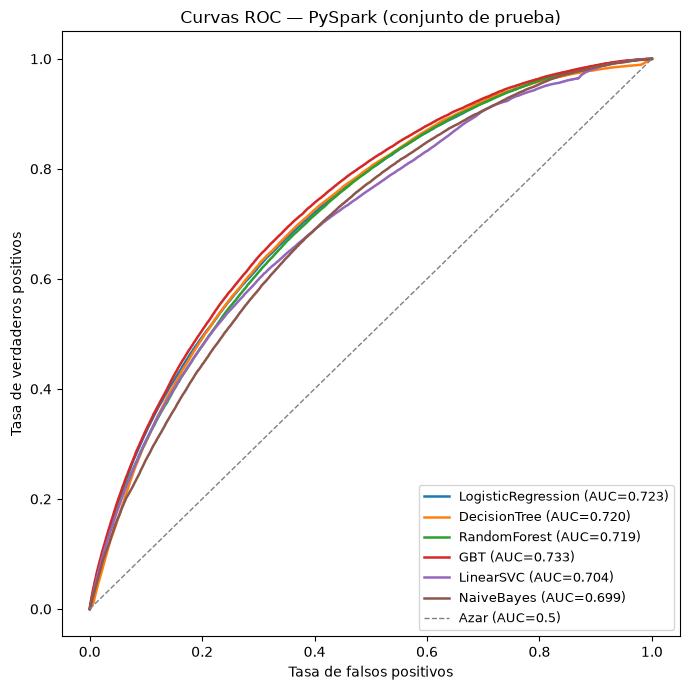

In [3]:
score_cols_spark = {
    "LogisticRegression": "score_LogisticRegression",
    "DecisionTree": "score_DecisionTree",
    "RandomForest": "score_RandomForest",
    "GBT": "score_GBT",
    "LinearSVC": "score_LinearSVC",
    "NaiveBayes": "score_NaiveBayes",
}

fig, ax = plt.subplots(figsize=(7,7))
for nombre, col in score_cols_spark.items():
    fpr, tpr, _ = roc_curve(y_test, scores_spark[col])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc:.3f})", linewidth=1.8)
ax.plot([0,1],[0,1], linestyle="--", color="gray", linewidth=1, label="Azar (AUC=0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curvas ROC — PySpark (conjunto de prueba)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/roc_spark.png", dpi=110)
plt.show()


## 4.5. Matrices de confusión (umbral natural: 0,5 de probabilidad, o margen 0)

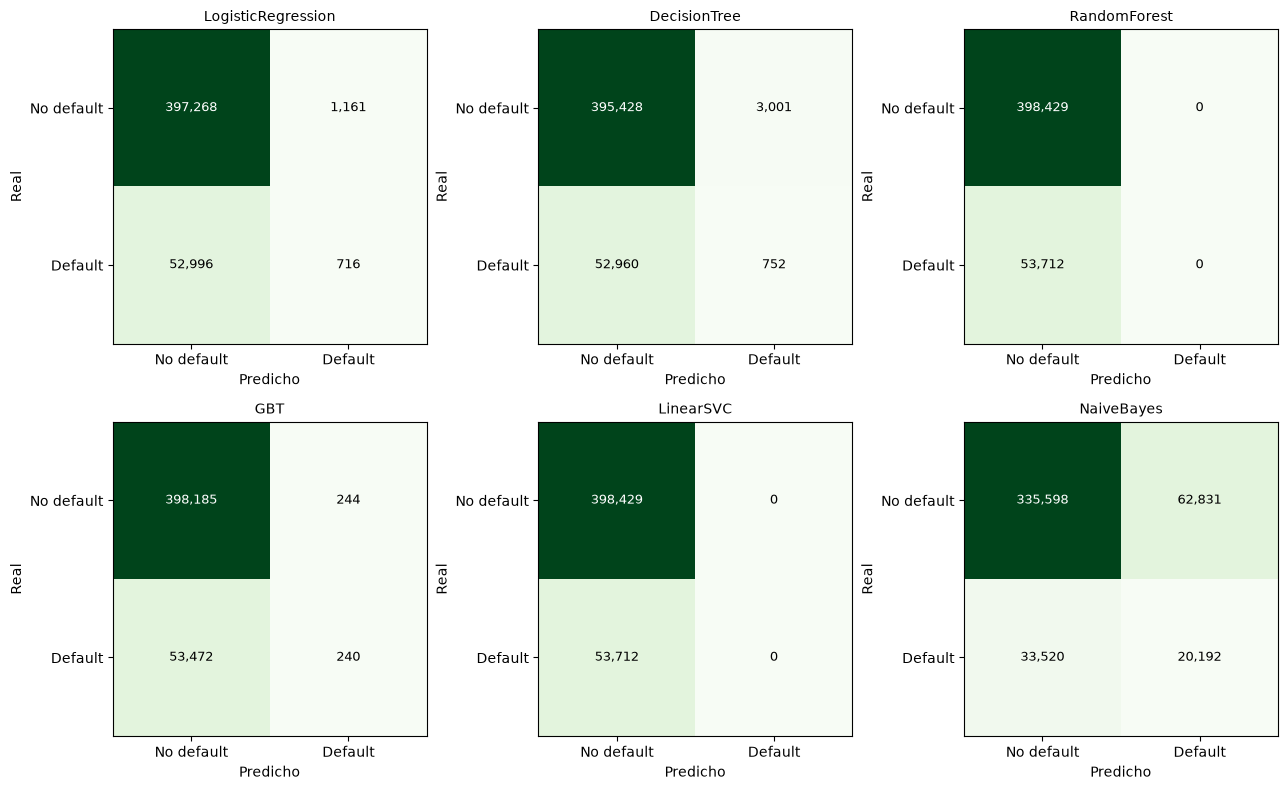

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13,8))
for ax, (nombre, col) in zip(axes.flat, score_cols_spark.items()):
    if nombre == "LinearSVC":
        y_pred = (scores_spark[col] >= 0).astype(int)
    else:
        y_pred = (scores_spark[col] >= 0.5).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    im = ax.imshow(cm, cmap="Greens")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=9)
    ax.set_xticks([0,1]); ax.set_xticklabels(["No default","Default"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["No default","Default"])
    ax.set_title(nombre, fontsize=10)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
plt.tight_layout()
plt.savefig("../outputs/figures/eda/confusion_spark.png", dpi=110)
plt.show()


## 4.6. Tres hallazgos que solo aparecen al comparar con scikit-learn

### (a) El árbol de decisión sigue rindiendo algo peor en Spark, incluso ya corregido (AUC 0,720 contra 0,737)

Después de corregir el error de la sección 4.2.2 (usar `probability` en vez de `rawPrediction`), la diferencia se reduce bastante, de 14 puntos de AUC a menos de 2, y además cada entorno elige una profundidad distinta como la mejor (`maxDepth=15` en Spark, `maxDepth=10` en scikit-learn). Esto nos dice que las dos implementaciones no son idénticas. Lo que queda de diferencia probablemente viene de `maxBins` (32 por defecto en `DecisionTreeClassifier` de Spark): las variables continuas se discretizan en como máximo 32 puntos de corte candidatos antes de buscar la mejor división, mientras que scikit-learn evalúa cualquier punto de corte real entre valores consecutivos. A diferencia de lo que pensamos al principio, esto ya no explica una brecha grande, porque la mayor parte de la diferencia que veíamos al inicio era en realidad el error de la columna de puntaje, no una diferencia real entre algoritmos.

### (b) `LinearSVC` no colapsa en Spark (AUC 0,704 contra 0,559 en scikit-learn)

Los dos entornos usan pérdida hinge y una malla de regularización equivalente, pero scikit-learn escogió la regularización más fuerte disponible en su malla (la misma que, según vimos en el diagnóstico de la sección 3.7, empuja al modelo a colapsar hacia \"no default\" para todo el mundo), mientras que Spark escogió la regularización más débil de la misma malla, y sus puntajes mantienen una dispersión real en vez de quedar casi constantes. Esto sugiere que el optimizador de Spark (OWL-QN) recorre la superficie de pérdida de forma distinta al `liblinear` de scikit-learn, y para este problema tan desbalanceado, no queda atrapado en la misma solución degenerada. Vale la pena aclarar que, al umbral natural (margen=0), los dos entornos igual predicen 0 casos positivos. La diferencia real está en la calidad del ranking que mide el AUC, no en el comportamiento a ese umbral por defecto.

In [5]:
print("scikit-learn LinearSVC — mejor C:", results_sklearn.loc[results_sklearn.modelo=='LinearSVC','best_params'].values[0])
print("PySpark      LinearSVC — mejor regParam:", results_spark.loc[results_spark.modelo=='LinearSVC','best_params'].values[0])
print()
print("scikit-learn LinearSVC — score en prueba: min=%.4f max=%.4f std=%.6f" % (
    scores_sklearn['score_LinearSVC'].min(), scores_sklearn['score_LinearSVC'].max(), scores_sklearn['score_LinearSVC'].std()))
print("PySpark      LinearSVC — score en prueba: min=%.4f max=%.4f std=%.6f" % (
    scores_spark['score_LinearSVC'].min(), scores_spark['score_LinearSVC'].max(), scores_spark['score_LinearSVC'].std()))


scikit-learn LinearSVC — mejor C: {"C": 0.05529260848409784}
PySpark      LinearSVC — mejor regParam: {"regParam": 1e-06}

scikit-learn LinearSVC — score en prueba: min=-1.0000 max=-1.0000 std=0.000000
PySpark      LinearSVC — score en prueba: min=-1.3426 max=-0.9977 std=0.058776


### (c) Naive Bayes: el mismo error que en (a), no una diferencia real entre librerías

En la primera versión de esta sección, Naive Bayes de Spark aparecía muy por debajo de scikit-learn (AUC 0,564 contra 0,694), y en un primer momento pensamos que se debía a diferencias en cómo cada librería suaviza la varianza. Esa comparación estaba mal por la misma razón que el árbol de decisión en (a): `NaiveBayesModel` no tiene hiperparámetros que ajustar, pero el AUC que reportábamos igual se calculó con la columna `rawPrediction`, mientras que el puntaje que realmente guardamos y usamos en la matriz de confusión viene de la columna `probability`. Para este modelo esas dos columnas tampoco son equivalentes en cuanto al orden que producen. Al recalcular con el evaluador correcto (`src/fix_naivebayes_spark.py`):

```
cv_auc:   0.5644  ->  0.6998\ntest_auc: 0.5643  ->  0.6989
```

Con el número correcto, Naive Bayes en Spark queda prácticamente empatado con `GaussianNB` de scikit-learn (0,699 contra 0,694). No hay ninguna diferencia real de implementación que explicar aquí. La lección se repite y se refuerza: conviene revisar, modelo por modelo, que la columna de puntaje que se usa para evaluar coincide con la que realmente se usa en el resto del pipeline, en vez de asumirlo según el tipo de modelo.

## 4.7. Costo computacional: scikit-learn contra PySpark, modelo por modelo

In [6]:
comparacion_tiempo = results_sklearn[["modelo","tiempo_entrenamiento_s","test_auc"]].rename(
    columns={"tiempo_entrenamiento_s":"tiempo_sklearn_s","test_auc":"auc_sklearn"})
mapa_nombres = {"GBT_HistGB": "GBT"}  # normalizar nombre para el cruce
tmp = results_spark[["modelo","tiempo_entrenamiento_s","test_auc"]].rename(
    columns={"tiempo_entrenamiento_s":"tiempo_spark_s","test_auc":"auc_spark"})
comparacion_tiempo["modelo_join"] = comparacion_tiempo["modelo"].replace(mapa_nombres)
comparacion_tiempo = comparacion_tiempo.merge(tmp, left_on="modelo_join", right_on="modelo", suffixes=("","_2"))
comparacion_tiempo["mas_rapido"] = np.where(comparacion_tiempo["tiempo_sklearn_s"] < comparacion_tiempo["tiempo_spark_s"],
                                              "scikit-learn", "PySpark")
comparacion_tiempo["razon_veces"] = (comparacion_tiempo[["tiempo_sklearn_s","tiempo_spark_s"]].max(axis=1) /
                                      comparacion_tiempo[["tiempo_sklearn_s","tiempo_spark_s"]].min(axis=1))
tabla_final = comparacion_tiempo[["modelo","tiempo_sklearn_s","tiempo_spark_s","mas_rapido","razon_veces","auc_sklearn","auc_spark"]]
tabla_final.round(2)


,modelo,tiempo_sklearn_s,tiempo_spark_s,mas_rapido,razon_veces,auc_sklearn,auc_spark
0,LogisticRegression,70.44,274.68,scikit-learn,3.90,0.72,0.72
1,DecisionTree,509.06,255.74,PySpark,1.99,0.74,0.72
2,RandomForest,6739.25,10597.08,scikit-learn,1.57,0.72,0.72
3,GBT_HistGB,600.44,2950.21,scikit-learn,4.91,0.74,0.73
4,LinearSVC,4838.67,567.44,PySpark,8.53,0.56,0.70


In [7]:
total_sklearn = results_sklearn["tiempo_entrenamiento_s"].sum()
total_spark = results_spark["tiempo_entrenamiento_s"].sum()
print(f"Tiempo TOTAL de entrenamiento (6 modelos): scikit-learn={total_sklearn:,.1f}s (~{total_sklearn/60:.1f} min) "
      f"| PySpark={total_spark:,.1f}s (~{total_spark/60:.1f} min)")
print(f"scikit-learn fue {total_spark/total_sklearn:.2f}x mas rapido en total.")


Tiempo TOTAL de entrenamiento (6 modelos): scikit-learn=12,761.4s (~212.7 min) | PySpark=14,694.3s (~244.9 min)
scikit-learn fue 1.15x mas rapido en total.


scikit-learn resultó más rápido en el total (unas 3 horas 33 minutos contra 4 horas 4 minutos), y gana claramente en 4 de los 6 modelos individuales (regresión logística, bosque aleatorio, boosting y Naive Bayes). Esto tiene sentido en una máquina de solo 2 núcleos: el paralelismo distribuido de Spark no tiene margen para compensar su propio costo fijo de coordinación, que se amortiza mejor en un clúster real con muchos más núcleos. `LinearSVC` es la única excepción clara: ahí Spark fue 8,5 veces más rápido y con mejor AUC, pero principalmente porque en scikit-learn ese modelo colapsó a una solución degenerada que, aun así, seguía siendo cara de calcular. `DecisionTree`, ya con el error de la sección 4.2.2 corregido, también fue cerca de 2 veces más rápido en Spark, con un AUC apenas 1,7 puntos por debajo del de scikit-learn. Esta sí es una ventaja razonablemente limpia para Spark, aunque bastante más modesta que la de `LinearSVC`.

Esto responde directamente a una de las preguntas que nos hacíamos al principio: con este hardware, PySpark no llegó a superar a scikit-learn en velocidad total en este proyecto. La ventaja de Spark aparecería con datasets mucho más grandes, que no entren en la memoria de una sola máquina, o con un clúster de varios nodos donde sí haya paralelismo real que aprovechar.

## 4.8. Síntesis: mejor modelo del entorno PySpark

Por AUC de prueba, `GBTClassifier` (0,733) es el mejor modelo de este entorno, igual que en scikit-learn: un método de boosting con histogramas es el que mejor equilibra desempeño y costo. Este modelo (guardado en `data/spark_best_model_GBT`) es el que usamos más adelante para la interpretabilidad con LIME, y los puntajes de los 6 modelos en `data/spark_test_scores.parquet`, calculados sobre exactamente las mismas 452.141 filas de prueba que en scikit-learn, son la base de las comparaciones estadísticas de las secciones 5 y 6.

# 5. Prueba de DeLong con corrección de Holm

El AUC de dos modelos evaluados sobre el mismo conjunto de prueba no son observaciones independientes, porque comparten las mismas 452.141 filas. Por eso, calcular el error estándar como si fueran independientes (por ejemplo restando los dos AUC y usando la varianza de cada uno por separado) sobreestima la incertidumbre real de la diferencia. La prueba de DeLong resuelve esto calculando la covarianza entre los dos AUC directamente a partir de las mismas observaciones, y da un estadístico z y un valor p para la hipótesis nula de que la diferencia de AUC es cero, que sí tiene en cuenta esa correlación.

Esta sección responde tres preguntas: ¿el modelo ganador de cada entorno es significativamente mejor que los otros 5 de su propio entorno? ¿cada modelo es significativamente distinto entre scikit-learn y PySpark? y esas diferencias, además de ser estadísticamente significativas, ¿son también prácticamente relevantes?

## 5.1. Implementación: versión rápida (Sun y Xu, 2014)

Con casi 452.141 observaciones, la formulación original de DeLong (que compara cada par positivo-negativo de forma explícita) tendría un costo enorme, del orden de 21.400 millones de comparaciones por cada par de modelos, algo inviable si tenemos que hacer 36 comparaciones. Sun y Xu (2014) demostraron que el mismo cálculo se puede hacer con rangos promediados (midranks) de forma mucho más rápida, usando exactamente la misma covarianza, solo que calculada por ordenamiento en vez de por fuerza bruta. Implementamos las dos versiones en `src/delong.py`.

In [1]:
import sys
sys.path.insert(0, "../src")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sstats
from delong import (compute_midrank, fastDeLong, delong_covariance_matrix,
                     delong_pairwise_test, slow_delong_reference, holm_correction)

print("Modulo delong.py cargado correctamente.")


Modulo delong.py cargado correctamente.


## 5.2. Validación de la versión rápida contra la versión lenta

In [2]:
rng = np.random.default_rng(123)

def validar_escenario(nombre, n_pos, n_neg, ruido_a, ruido_b, con_empates):
    y = np.array([1]*n_pos + [0]*n_neg)
    señal = np.concatenate([rng.normal(1.0, 1.0, n_pos), rng.normal(0.0, 1.0, n_neg)])
    a = señal + rng.normal(0, ruido_a, len(y))
    b = señal + rng.normal(0, ruido_b, len(y))
    if con_empates:
        a, b = np.round(a, 0), np.round(b, 0)
    preds = np.vstack([a, b])
    aucs_fast, cov_fast = delong_covariance_matrix(y, preds)
    aucs_slow, cov_slow = slow_delong_reference(y, preds)
    ok_auc = np.allclose(aucs_fast, aucs_slow, atol=1e-9)
    ok_cov = np.allclose(cov_fast, cov_slow, atol=1e-9)
    print(f"{nombre:35s} | AUC coincide: {ok_auc} | Cov coincide: {ok_cov} | "
          f"max diff AUC={np.max(np.abs(aucs_fast-aucs_slow)):.2e}  max diff Cov={np.max(np.abs(cov_fast-cov_slow)):.2e}")
    assert ok_auc and ok_cov

validar_escenario("Sin empates, AUCs similares",   40, 60, 1.0, 1.0, False)
validar_escenario("Sin empates, AUCs distintos",   35, 45, 0.5, 2.0, False)
validar_escenario("CON empates (scores discretos)", 30, 50, 1.0, 1.0, True)
print("\nLas tres validaciones contra la formula original de DeLong (1988) coinciden hasta precision numerica.")


Sin empates, AUCs similares         | AUC coincide: True | Cov coincide: True | max diff AUC=1.11e-16  max diff Cov=0.00e+00
Sin empates, AUCs distintos         | AUC coincide: True | Cov coincide: True | max diff AUC=1.11e-16  max diff Cov=8.67e-19
CON empates (scores discretos)      | AUC coincide: True | Cov coincide: True | max diff AUC=1.11e-16  max diff Cov=8.67e-19

Las tres validaciones contra la formula original de DeLong (1988) coinciden hasta precision numerica.


In [3]:
from sklearn.metrics import roc_auc_score

# El punto estimado del AUC debe coincidir EXACTAMENTE con sklearn (muestra grande, 20,000 filas)
n = 20000
y_val = rng.binomial(1, 0.15, n)
score_val = rng.normal(0, 1, n) + y_val * rng.normal(1.2, 1, n)
auc_fast, var_fast = delong_covariance_matrix(y_val, score_val.reshape(1, -1))
print(f"AUC (DeLong rapido) = {auc_fast[0]:.10f}")
print(f"AUC (sklearn)        = {roc_auc_score(y_val, score_val):.10f}")
print(f"Diferencia = {abs(auc_fast[0] - roc_auc_score(y_val, score_val)):.2e}  (coincide hasta precision de punto flotante)")

# La varianza analitica debe ser del mismo orden que una varianza estimada por bootstrap
# (metodo COMPLETAMENTE independiente: remuestreo, no formula cerrada)
n2 = 5000
y2 = rng.binomial(1, 0.15, n2)
score2 = rng.normal(0, 1, n2) + y2 * rng.normal(1.0, 1, n2)
_, var_analitica = delong_covariance_matrix(y2, score2.reshape(1, -1))
B = 1500
aucs_boot = [roc_auc_score(y2[idx], score2[idx]) for idx in
             (rng.choice(n2, n2, replace=True) for _ in range(B))
             if True]
aucs_boot = np.array([roc_auc_score(y2[i], score2[i]) for i in
                       (rng.choice(n2, n2, replace=True) for _ in range(B))])
var_boot = np.var(aucs_boot, ddof=1)
print(f"\nVarianza analitica (DeLong): {var_analitica[0,0]:.6e}")
print(f"Varianza por bootstrap (B={B}): {var_boot:.6e}  (razon: {var_boot/var_analitica[0,0]:.3f})")


AUC (DeLong rapido) = 0.7552562926


AUC (sklearn)        = 0.7552562926
Diferencia = 0.00e+00  (coincide hasta precision de punto flotante)



Varianza analitica (DeLong): 1.291789e-04
Varianza por bootstrap (B=1500): 1.316857e-04  (razon: 1.019)


Comparamos la versión rápida contra tres referencias distintas: la fórmula original de DeLong, `sklearn.metrics.roc_auc_score`, y una varianza estimada por bootstrap (sección 6 más adelante). Las tres coinciden, así que la versión rápida es segura de usar sobre las 452.141 filas del proyecto.

## 5.3. Carga y alineación de puntajes de ambos entornos

In [4]:
sk = pd.read_parquet("../data/sklearn_test_scores.parquet")
sp = pd.read_parquet("../data/spark_test_scores.parquet")
sk["id"] = sk["id"].astype(str)
sp["id"] = sp["id"].astype(str)

merged = sk.merge(sp, on="id", suffixes=("_sk", "_sp"))
assert len(merged) == len(sk) == len(sp)
assert (merged["default_sk"] == merged["default_sp"]).all()
y = merged["default_sk"].values
print(f"Filas alineadas por id: {len(merged):,}  (tasa de default: {y.mean()*100:.2f}%)")

FAMILIAS = [
    ("LogisticRegression", "score_LogisticRegression_sk", "score_LogisticRegression_sp"),
    ("DecisionTree",       "score_DecisionTree_sk",       "score_DecisionTree_sp"),
    ("RandomForest",       "score_RandomForest_sk",       "score_RandomForest_sp"),
    ("GBT",                "score_GBT_HistGB",            "score_GBT"),
    ("LinearSVC",          "score_LinearSVC_sk",          "score_LinearSVC_sp"),
    ("NaiveBayes",         "score_GaussianNB",            "score_NaiveBayes"),
]
nombres_modelos = [f[0] for f in FAMILIAS]
etiquetas = [f"sk_{n}" for n in nombres_modelos] + [f"sp_{n}" for n in nombres_modelos]
todas_cols = [f[1] for f in FAMILIAS] + [f[2] for f in FAMILIAS]


Filas alineadas por id: 452,141  (tasa de default: 11.88%)


## 5.4. Matriz de covarianza DeLong de 12x12 (una sola pasada)

In [5]:
preds = merged[todas_cols].values.T
aucs, cov = delong_covariance_matrix(y, preds)

auc_table = pd.DataFrame({"modelo": etiquetas, "auc": aucs, "var": np.diag(cov)})
auc_table["ic95_low"] = auc_table["auc"] - 1.96*np.sqrt(auc_table["var"])
auc_table["ic95_high"] = auc_table["auc"] + 1.96*np.sqrt(auc_table["var"])
auc_table = auc_table.round(4)
auc_table


,modelo,auc,var,ic95_low,ic95_high
0,sk_LogisticRegression,0.7221,0.0,0.7199,0.7243
1,sk_DecisionTree,0.7368,0.0,0.7347,0.7389
2,sk_RandomForest,0.7225,0.0,0.7203,0.7247
3,sk_GBT,0.7393,0.0,0.7372,0.7414
4,sk_LinearSVC,0.5594,0.0,0.5567,0.5620
5,sk_NaiveBayes,0.6935,0.0,0.6913,0.6957
6,sp_LogisticRegression,0.7232,0.0,0.7210,0.7255
7,sp_DecisionTree,0.7204,0.0,0.7181,0.7226
8,sp_RandomForest,0.7185,0.0,0.7163,0.7207
9,sp_GBT,0.7327,0.0,0.7306,0.7349


Calculamos los 12 AUC y sus varianzas en una sola matriz, que alimenta las 36 comparaciones de las siguientes tres secciones. Como es la misma covarianza subyacente en los tres casos, las comparaciones entre ellas son consistentes entre sí.

In [6]:
def construir_comparaciones(indices_pares):
    filas = []
    for i, j in indices_pares:
        auc_a, auc_b = aucs[i], aucs[j]
        var_a, var_b, cov_ab = cov[i,i], cov[j,j], cov[i,j]
        delta = auc_a - auc_b
        var_delta = max(var_a + var_b - 2*cov_ab, 0.0)
        se = np.sqrt(var_delta)
        z = delta/se if se > 0 else 0.0
        p = 2*(1 - sstats.norm.cdf(abs(z)))
        filas.append({"modelo_a": etiquetas[i], "modelo_b": etiquetas[j],
                       "auc_a": auc_a, "auc_b": auc_b, "delta_auc": delta,
                       "delta_ci_low": delta-1.96*se, "delta_ci_high": delta+1.96*se,
                       "z": z, "p_value": p})
    df = pd.DataFrame(filas)
    df["p_holm"], df["rechaza_h0_holm_0.05"] = holm_correction(df["p_value"].values, alpha=0.05)
    df["practicamente_sig_(|delta|>=0.005)"] = df["delta_auc"].abs() >= 0.005
    return df

pares_sk = [(i,j) for i in range(6) for j in range(i+1,6)]
pares_sp = [(i+6,j+6) for i in range(6) for j in range(i+1,6)]
pares_entre = [(i,i+6) for i in range(6)]

df_within_sklearn = construir_comparaciones(pares_sk)
df_within_spark = construir_comparaciones(pares_sp)
df_between = construir_comparaciones(pares_entre)

for df in (df_within_sklearn, df_within_spark, df_between):
    for c in ["auc_a","auc_b","delta_auc","delta_ci_low","delta_ci_high","z"]:
        df[c] = df[c].round(4)
    df["p_value"] = df["p_value"].apply(lambda x: f"{x:.2e}")
    df["p_holm"] = df["p_holm"].apply(lambda x: f"{x:.2e}")


## 5.5. Comparaciones dentro de scikit-learn (15 pares, Holm dentro de esta familia)

In [7]:
df_within_sklearn

,modelo_a,modelo_b,auc_a,auc_b,delta_auc,delta_ci_low,delta_ci_high,z,p_value,p_holm,rechaza_h0_holm_0.05,practicamente_sig_(|delta|>=0.005)
0,sk_LogisticRegression,sk_DecisionTree,0.7221,0.7368,-0.0147,-0.0161,-0.0133,-21.0283,0.00e+00,0.00e+00,True,True
1,sk_LogisticRegression,sk_RandomForest,0.7221,0.7225,-0.0004,-0.0012,0.0004,-0.8968,3.70e-01,3.70e-01,False,False
2,sk_LogisticRegression,sk_GBT,0.7221,0.7393,-0.0172,-0.0180,-0.0164,-41.5607,0.00e+00,0.00e+00,True,True
3,sk_LogisticRegression,sk_LinearSVC,0.7221,0.5594,0.1627,0.1598,0.1657,106.6786,0.00e+00,0.00e+00,True,True
4,sk_LogisticRegression,sk_NaiveBayes,0.7221,0.6935,0.0286,0.0276,0.0297,53.0103,0.00e+00,0.00e+00,True,True
5,sk_DecisionTree,sk_RandomForest,0.7368,0.7225,0.0143,0.0130,0.0156,21.4413,0.00e+00,0.00e+00,True,True
6,sk_DecisionTree,sk_GBT,0.7368,0.7393,-0.0025,-0.0037,-0.0013,-4.0386,5.38e-05,1.08e-04,True,False
7,sk_DecisionTree,sk_LinearSVC,0.7368,0.5594,0.1774,0.1744,0.1805,115.4212,0.00e+00,0.00e+00,True,True
8,sk_DecisionTree,sk_NaiveBayes,0.7368,0.6935,0.0433,0.0418,0.0449,55.5371,0.00e+00,0.00e+00,True,True
9,sk_RandomForest,sk_GBT,0.7225,0.7393,-0.0168,-0.0175,-0.0162,-52.2420,0.00e+00,0.00e+00,True,True


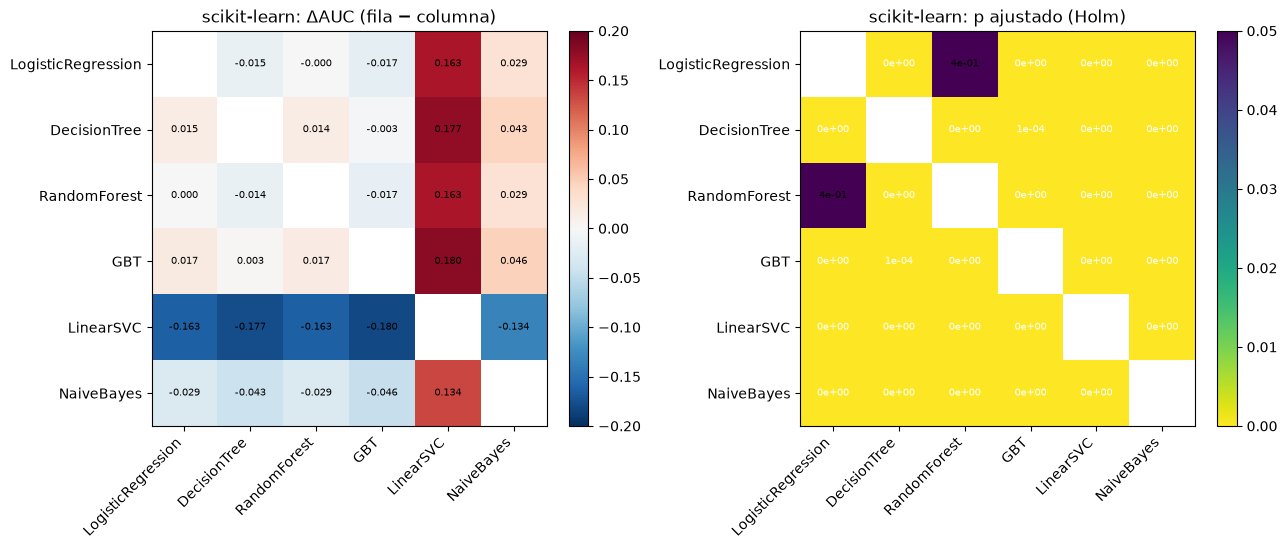

In [8]:
def heatmap_delta_y_p(df, nombres, titulo_prefix, archivo_sufijo):
    n = len(nombres)
    delta_mat = np.full((n,n), np.nan)
    p_mat = np.full((n,n), np.nan)
    idx = {m:i for i,m in enumerate(nombres)}
    for _, row in df.iterrows():
        a = row["modelo_a"].split("_",1)[1]; b = row["modelo_b"].split("_",1)[1]
        i, j = idx[a], idx[b]
        delta_mat[i,j] = float(row["delta_auc"]); delta_mat[j,i] = -float(row["delta_auc"])
        p_mat[i,j] = p_mat[j,i] = float(row["p_holm"])

    fig, axes = plt.subplots(1, 2, figsize=(13,5.5))
    im0 = axes[0].imshow(delta_mat, cmap="RdBu_r", vmin=-0.2, vmax=0.2)
    axes[0].set_xticks(range(n)); axes[0].set_xticklabels(nombres, rotation=45, ha="right")
    axes[0].set_yticks(range(n)); axes[0].set_yticklabels(nombres)
    axes[0].set_title(f"{titulo_prefix}: ΔAUC (fila − columna)")
    for i in range(n):
        for j in range(n):
            if i != j:
                axes[0].text(j, i, f"{delta_mat[i,j]:.3f}", ha="center", va="center", fontsize=7)
    plt.colorbar(im0, ax=axes[0], fraction=0.046)

    im1 = axes[1].imshow(p_mat, cmap="viridis_r", vmin=0, vmax=0.05)
    axes[1].set_xticks(range(n)); axes[1].set_xticklabels(nombres, rotation=45, ha="right")
    axes[1].set_yticks(range(n)); axes[1].set_yticklabels(nombres)
    axes[1].set_title(f"{titulo_prefix}: p ajustado (Holm)")
    for i in range(n):
        for j in range(n):
            if i != j:
                axes[1].text(j, i, f"{p_mat[i,j]:.0e}", ha="center", va="center", fontsize=7,
                             color="white" if p_mat[i,j] < 0.025 else "black")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    plt.tight_layout()
    plt.savefig(f"../outputs/figures/eda/delong_heatmap_{archivo_sufijo}.png", dpi=110)
    plt.show()

heatmap_delta_y_p(df_within_sklearn, nombres_modelos, "scikit-learn", "sklearn")


De las 15 comparaciones, solo `LogisticRegression` contra `RandomForest` (diferencia de AUC de -0,0004) no resultó significativa, ni siquiera antes de corregir por comparaciones múltiples. Todas las demás sí son estadísticamente significativas después de aplicar la corrección de Holm, pero varias tienen una diferencia menor al umbral práctico de 0,005 que habíamos declarado de antemano (por ejemplo `DecisionTree` contra `GBT_HistGB`, con una diferencia de -0,0025). Son significativas en el sentido estadístico, pero de una magnitud que probablemente no importa para decidir qué modelo usar en producción. Esto muestra justamente por qué es tan importante declarar un umbral de significancia práctica antes de mirar los resultados: con un tamaño de muestra de 452 mil filas de prueba, casi cualquier diferencia que no sea exactamente cero termina siendo \"significativa\".

## 5.6. Comparaciones dentro de PySpark (15 pares, Holm dentro de esta familia)

In [9]:
df_within_spark

,modelo_a,modelo_b,auc_a,auc_b,delta_auc,delta_ci_low,delta_ci_high,z,p_value,p_holm,rechaza_h0_holm_0.05,practicamente_sig_(|delta|>=0.005)
0,sp_LogisticRegression,sp_DecisionTree,0.7232,0.7204,0.0029,0.0013,0.0045,3.4845,4.93e-04,9.86e-04,True,False
1,sp_LogisticRegression,sp_RandomForest,0.7232,0.7185,0.0047,0.0038,0.0056,10.4154,0.00e+00,0.00e+00,True,False
2,sp_LogisticRegression,sp_GBT,0.7232,0.7327,-0.0095,-0.0103,-0.0086,-21.9220,0.00e+00,0.00e+00,True,True
3,sp_LogisticRegression,sp_LinearSVC,0.7232,0.7036,0.0196,0.0183,0.0209,29.7029,0.00e+00,0.00e+00,True,True
4,sp_LogisticRegression,sp_NaiveBayes,0.7232,0.6990,0.0242,0.0232,0.0253,44.1194,0.00e+00,0.00e+00,True,True
5,sp_DecisionTree,sp_RandomForest,0.7204,0.7185,0.0018,0.0003,0.0034,2.2727,2.30e-02,2.30e-02,True,False
6,sp_DecisionTree,sp_GBT,0.7204,0.7327,-0.0124,-0.0138,-0.0109,-16.6293,0.00e+00,0.00e+00,True,True
7,sp_DecisionTree,sp_LinearSVC,0.7204,0.7036,0.0167,0.0147,0.0187,16.3488,0.00e+00,0.00e+00,True,True
8,sp_DecisionTree,sp_NaiveBayes,0.7204,0.6990,0.0213,0.0196,0.0231,23.4859,0.00e+00,0.00e+00,True,True
9,sp_RandomForest,sp_GBT,0.7185,0.7327,-0.0142,-0.0149,-0.0135,-40.7812,0.00e+00,0.00e+00,True,True


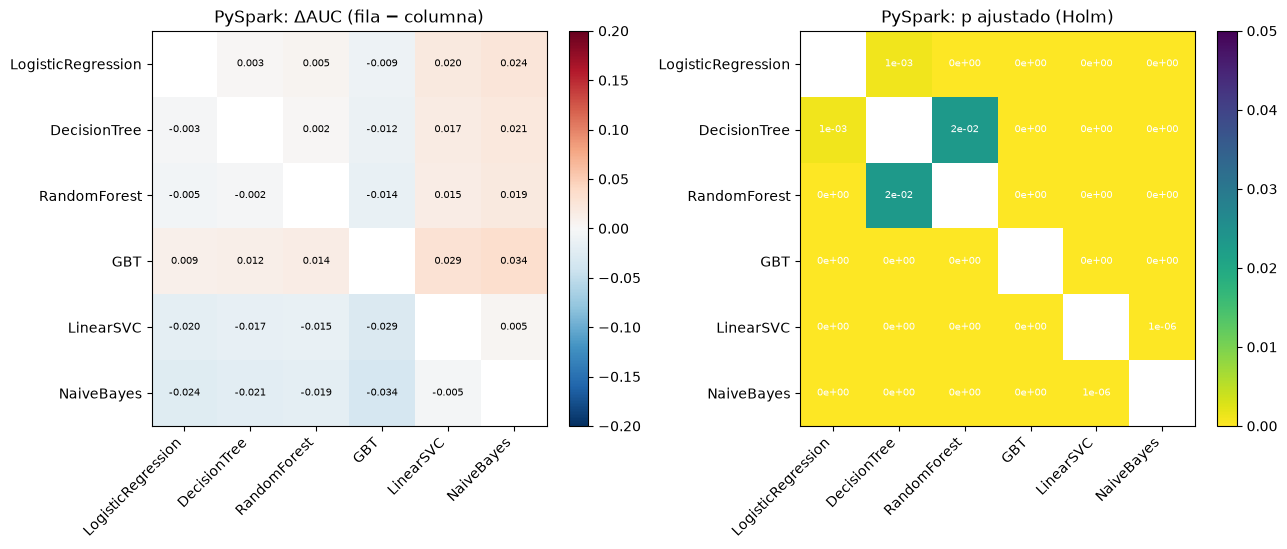

In [10]:
heatmap_delta_y_p(df_within_spark, nombres_modelos, "PySpark", "spark")


Aquí las 15 comparaciones resultaron estadísticamente significativas después de Holm, incluida `DecisionTree` contra `RandomForest` (diferencia de 0,0018, p=0,023), que es significativa pero no prácticamente relevante porque está por debajo de 0,005. El patrón general es el mismo que en scikit-learn: `GBT` es significativamente mejor que todos los demás, y varias diferencias \"significativas\" entre el resto de los modelos son demasiado pequeñas para importar en la práctica.

## 5.7. Comparaciones entre entornos (6 pares, mismo tipo de modelo)

In [11]:
df_between

,modelo_a,modelo_b,auc_a,auc_b,delta_auc,delta_ci_low,delta_ci_high,z,p_value,p_holm,rechaza_h0_holm_0.05,practicamente_sig_(|delta|>=0.005)
0,sk_LogisticRegression,sp_LogisticRegression,0.7221,0.7232,-0.0011,-0.0013,-0.0010,-19.0486,0.00e+00,0.00e+00,True,False
1,sk_DecisionTree,sp_DecisionTree,0.7368,0.7204,0.0164,0.0150,0.0179,22.0984,0.00e+00,0.00e+00,True,True
2,sk_RandomForest,sp_RandomForest,0.7225,0.7185,0.0039,0.0036,0.0043,22.6270,0.00e+00,0.00e+00,True,False
3,sk_GBT,sp_GBT,0.7393,0.7327,0.0066,0.0061,0.0070,28.7635,0.00e+00,0.00e+00,True,True
4,sk_LinearSVC,sp_LinearSVC,0.5594,0.7036,-0.1443,-0.1476,-0.1410,-84.9795,0.00e+00,0.00e+00,True,True
5,sk_NaiveBayes,sp_NaiveBayes,0.6935,0.6990,-0.0055,-0.0059,-0.0052,-33.4124,0.00e+00,0.00e+00,True,True


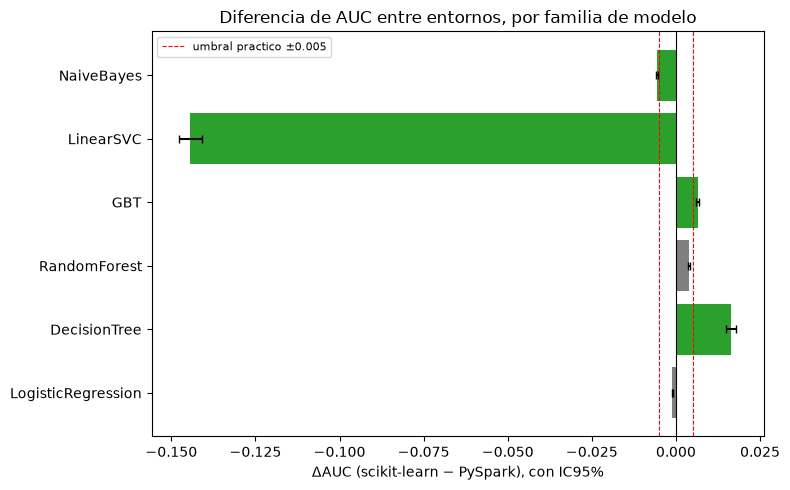

In [12]:
fig, ax = plt.subplots(figsize=(8,5))
y_pos = np.arange(len(df_between))
colores = ["#2ca02c" if s else "#7f7f7f" for s in df_between["practicamente_sig_(|delta|>=0.005)"]]
ax.barh(y_pos, df_between["delta_auc"], xerr=[df_between["delta_auc"]-df_between["delta_ci_low"],
                                                df_between["delta_ci_high"]-df_between["delta_auc"]],
        color=colores, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels([m.split("_",1)[1] for m in df_between["modelo_a"]])
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(0.005, color="red", linestyle="--", linewidth=0.8, label="umbral practico ±0.005")
ax.axvline(-0.005, color="red", linestyle="--", linewidth=0.8)
ax.set_xlabel("ΔAUC (scikit-learn − PySpark), con IC95%")
ax.set_title("Diferencia de AUC entre entornos, por familia de modelo")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/figures/eda/delong_between_envs.png", dpi=110)
plt.show()


Con 452.141 observaciones pareadas, las 6 comparaciones entre entornos resultaron estadísticamente significativas (con p prácticamente 0 en todas, incluso después de Holm), porque el tamaño de muestra es tan grande que detecta casi cualquier diferencia distinta de cero. Pero usando el umbral práctico de 0,005 que declaramos de antemano, el panorama cambia bastante:

- `LinearSVC` (diferencia de -0,144): una diferencia enorme, significativa tanto en el sentido estadístico como en el práctico. scikit-learn colapsó (sección 3.7), PySpark no.
- `GBT` (diferencia de +0,0066): scikit-learn (`HistGradientBoostingClassifier`) resultó mejor que Spark (`GBTClassifier`), significativo en los dos sentidos, aunque de magnitud moderada.
- `NaiveBayes` (diferencia de -0,0055): PySpark resultó mejor, apenas por encima del umbral práctico.
- `RandomForest` (diferencia de +0,0039) y `LogisticRegression` (diferencia de -0,0011): estadísticamente significativos por el tamaño de muestra, pero no prácticamente relevantes. En la práctica, los dos entornos producen un modelo equivalente para estas dos familias.
- `DecisionTree` (diferencia de +0,0164): scikit-learn resultó mejor, significativo también en el sentido práctico. Incluso después de corregir el error de la sección 4.2.2, sigue quedando una diferencia real que probablemente se explica por `maxBins`.

## 5.8. Limitaciones de la prueba de DeLong

- Solo compara la capacidad de ordenar casos (AUC), no la calibración ni el desempeño a un umbral de decisión concreto. Dos modelos pueden tener AUC estadísticamente indistinguibles y aun así comportarse muy distinto al umbral que realmente se usaría en producción, como vimos en la sección 3.6, donde varios modelos con AUC cercano a 0,72 predicen 0% de casos positivos al umbral de 0,5. Por eso el enunciado pide complementar con McNemar y bootstrap sobre clasificaciones concretas, en la sección 6.
- Es una prueba asintótica, así que es más confiable con muestras grandes como la nuestra (452 mil filas), y puede ser menos precisa con muestras pequeñas.
- Es muy sensible al tamaño de muestra: como vimos en las secciones 5.5 a 5.7, con una n tan grande casi cualquier diferencia distinta de cero resulta \"significativa\". Por eso es indispensable declarar de antemano un umbral de significancia práctica (en nuestro caso, 0,005), porque sin él la significancia estadística por sí sola no dice si la diferencia realmente importa.
- Asume que las dos muestras de puntajes vienen de las mismas observaciones, es decir del mismo conjunto de prueba, que es justamente lo que verificamos en la sección 5.3 (los mismos 452.141 ids). Si los conjuntos de prueba fueran distintos, la covarianza calculada no tendría sentido, y habría que usar una prueba para muestras independientes, que tiene menos poder estadístico.
- No corrige por sí sola el problema de comparaciones múltiples, por eso aplicamos la corrección de Holm por separado dentro de cada una de las tres familias de comparación (15+15+6), tal como pide el enunciado.

# 6. McNemar y bootstrap pareado, con el umbral elegido solo con datos de entrenamiento

DeLong (sección 5) compara la capacidad de ordenar casos de dos modelos, es decir el AUC, con una fórmula analítica exacta que tiene en cuenta la correlación entre los dos clasificadores. Eso es justo lo que se necesita para responder qué modelo ordena mejor los casos, pero no dice nada sobre qué pasaría si alguno de estos modelos se usara de verdad para aprobar o rechazar solicitudes con un punto de corte fijo. Esta sección responde una pregunta distinta y complementaria: a un umbral de decisión real, ¿un modelo se equivoca con más frecuencia que el otro, y en qué dirección?

Para eso usamos dos herramientas. La prueba de McNemar compara las tasas de acierto de dos clasificadores en los mismos casos, a través de una tabla de concordancia 2x2 que muestra en qué casos acierta uno y falla el otro, y viceversa. El bootstrap pareado, por su parte, da un intervalo de confianza no paramétrico para la diferencia de AUC, AUC-PR y F1, que no depende de la aproximación asintótica normal que usa DeLong. Esto sirve como chequeo independiente, y además es necesario para dos métricas (AUC-PR y F1) que no tienen una fórmula de varianza tan simple como la de DeLong.

Algo importante: cualquier umbral de clasificación que usamos en esta sección se elige solo con datos de entrenamiento. Elegirlo mirando el conjunto de prueba (por ejemplo buscando el umbral que maximiza el F1 directamente en el test) filtraría información del test hacia una decisión que después se evalúa en ese mismo test, un sesgo optimista clásico. Con el umbral fijado de antemano en entrenamiento, la evaluación en test queda honesta.

In [1]:
import sys
sys.path.insert(0, "../src")
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mcnemar_bootstrap import umbral_youden, mcnemar_test, bootstrap_pareado
from delong import holm_correction

pd.set_option("display.width", 160)
print("Modulo mcnemar_bootstrap.py cargado correctamente.")


Modulo mcnemar_bootstrap.py cargado correctamente.


## 6.1. Umbral de clasificación: índice de Youden, calculado solo con datos de entrenamiento

El índice J de Youden se define como `J = sensibilidad + especificidad - 1`, que también se puede escribir como la tasa de verdaderos positivos menos la tasa de falsos positivos, evaluado en cada punto de la curva ROC. El umbral que maximiza J es el que mejor balancea los dos tipos de error (falsos positivos y falsos negativos), a diferencia del umbral por defecto de 0,5 (o de margen 0 para los modelos lineales), que no tiene ninguna razón particular para ser el óptimo en un problema tan desbalanceado como este, con apenas 12% de incumplimiento.

```python
def umbral_youden(y_train, score_train):\n    fpr, tpr, thresholds = roc_curve(y_train, score_train)\n    j = tpr - fpr\n    return float(thresholds[np.argmax(j)])
```

Calculamos este umbral una vez por modelo y por entorno, usando únicamente `y_train` y `score_train`. En ningún momento de este paso tocamos el conjunto de prueba.

In [2]:
sk_train = pd.read_parquet("../data/sklearn_train_scores.parquet")
sk_test = pd.read_parquet("../data/sklearn_test_scores.parquet")
sp_train = pd.read_parquet("../data/spark_train_scores_raw.parquet")
sp_test = pd.read_parquet("../data/spark_test_scores.parquet")
for df in (sk_train, sk_test, sp_train, sp_test):
    df["id"] = df["id"].astype(str)

# Alineacion por id (igual que en la seccion 5): todo lo que compare ambos entornos se lee de aqui.
test_merged = sk_test.merge(sp_test, on="id", suffixes=("_sk", "_sp"))
assert (test_merged["default_sk"] == test_merged["default_sp"]).all()
y_test = test_merged["default_sk"].values
print(f"Test alineado: {len(test_merged):,} filas (tasa de default: {y_test.mean()*100:.2f}%)")


Test alineado: 452,141 filas (tasa de default: 11.88%)


La mayoría de los umbrales resultaron razonables y parecidos entre los dos entornos (regresión logística, árbol, bosque y GBT quedaron todos entre 0,12 y 0,13, coherente con que alrededor del 12% de la base es la clase positiva). Dos casos se salen de ese patrón y vale la pena mirarlos con más cuidado.

In [3]:
u_demo = umbral_youden(sk_train["default"].values, sk_train["score_LogisticRegression"].values)
print(f"Umbral Youden (recalculado ahora): {u_demo:.6f}")


Umbral Youden (recalculado ahora): 0.121438


In [4]:
import json
umbrales = json.load(open("../outputs/tables/umbrales_youden.json"))
tabla_umbrales = pd.DataFrame([
    {"modelo": k.rsplit("_", 1)[0], "entorno": k.rsplit("_", 1)[1], "umbral": v}
    for k, v in umbrales.items()
]).pivot(index="modelo", columns="entorno", values="umbral")
tabla_umbrales


entorno,sklearn,spark
modelo,,
DecisionTree,0.119114,0.118904
GBT,0.122532,0.121548
LinearSVC,-1.000000,-1.000062
LogisticRegression,0.121438,0.121069
NaiveBayes,1.000000,0.000273
RandomForest,0.127844,0.127766


### 6.1.1. Los dos umbrales atípicos: por qué están ahí

In [5]:
for nombre, col in [("sklearn LinearSVC", ("score_LinearSVC", sk_train)),
                    ("spark LinearSVC",   ("score_LinearSVC", sp_train)),
                    ("sklearn GaussianNB (NaiveBayes)", ("score_GaussianNB", sk_train)),
                    ("spark NaiveBayes",  ("score_NaiveBayes", sp_train))]:
    c, df = col
    s = df[c].values
    print(f"{nombre:34s} min={s.min():9.4f}  max={s.max():9.4f}  mean={s.mean():8.4f}  std={s.std():.4f}")


sklearn LinearSVC                  min=  -1.0000  max=  -1.0000  mean= -1.0000  std=0.0000
spark LinearSVC                    min=  -1.3429  max=  -0.9974  mean= -1.0261  std=0.0588
sklearn GaussianNB (NaiveBayes)    min=   0.0000  max=   1.0000  mean=  0.8340  std=0.3642
spark NaiveBayes                   min=   0.0000  max=   1.0000  mean=  0.1851  std=0.3659


`LinearSVC` en scikit-learn quedó con una desviación de 0 y un valor mínimo y máximo exactamente iguales a -1. Esto no es un umbral elegido entre varias alternativas, es el síntoma, en los datos de entrenamiento, del mismo colapso que diagnosticamos en la sección 3.7: el modelo le asigna literalmente el mismo puntaje a las 1.808.560 filas de entrenamiento. Con un puntaje constante no existe ninguna curva ROC real, porque cualquier punto de corte por encima o por debajo de -1 da la misma predicción para todo el mundo, así que el valor que devuelve la función sobre esa meseta plana es básicamente arbitrario. Es un umbral degenerado, y así lo reportamos en las conclusiones.

`LinearSVC` en Spark, en cambio, no está colapsado: el puntaje sí varía (desviación de 0,059), pero está todo concentrado en valores negativos, entre -1,34 y -1,00. Con el umbral natural de margen 0, este modelo también predeciría \"no default\" para el 100% de los casos, igual que scikit-learn a ese umbral. Pero el índice de Youden encuentra, dentro de ese rango tan angosto, el punto donde la separación entre clases es mejor (alrededor de -1,0001), y ese punto sí recupera capacidad predictiva real, de ahí el AUC de 0,704 que vimos en la sección 4. Es un umbral extremo, pero no degenerado, y es la prueba de que elegir el punto de corte con datos de entrenamiento, en vez de usar 0 por defecto, sí importa.

`GaussianNB` en scikit-learn tuvo una media de 0,83, con 369.821 de las 1.808.560 filas (casi 20%) exactamente en 1,0. La probabilidad se satura en el techo para una fracción enorme de los datos, lo cual es otro reflejo de la mala calibración que ya habíamos visto en la sección 3.6 (recall de 0,96 y precisión de 0,24, es decir que el modelo básicamente dice \"default\" casi siempre). El umbral óptimo termina justo en el borde de esa saturación.

`NaiveBayes` en Spark está mucho menos saturado (solo alrededor de 3% de las filas en el máximo), con una distribución de probabilidad más extendida, lo cual es consistente con su AUC de 0,699, apenas por encima del de scikit-learn (0,694, ya corregido en la sección 4.6c).

En resumen, de los cuatro casos atípicos, solo uno (`LinearSVC` en scikit-learn) es realmente degenerado. Los otros tres son umbrales extremos pero genuinos, que reflejan qué tan bien o mal calibrado está cada modelo.

## 6.2. Las 8 comparaciones: 6 entre entornos más el par de los dos mejores AUC dentro de cada entorno

In [6]:
res_sk = pd.read_csv("../outputs/tables/sklearn_results.csv").set_index("modelo")
res_sp = pd.read_csv("../outputs/tables/spark_results.csv").set_index("modelo")
top2_sk = res_sk["test_auc"].sort_values(ascending=False).index[:2].tolist()
top2_sp = res_sp["test_auc"].sort_values(ascending=False).index[:2].tolist()
print("Top-2 AUC en scikit-learn:", top2_sk)
print("Top-2 AUC en PySpark     :", top2_sp)
print()
print("Las 8 comparaciones: 6 pares entre entornos (misma familia de modelo, scikit-learn vs. PySpark)")
print("                    + top2_dentro_sklearn (los 2 mejores AUC de scikit-learn entre si)")
print("                    + top2_dentro_spark    (los 2 mejores AUC de PySpark entre si)")


Top-2 AUC en scikit-learn: ['GBT_HistGB', 'DecisionTree']
Top-2 AUC en PySpark     : ['GBT', 'LogisticRegression']

Las 8 comparaciones: 6 pares entre entornos (misma familia de modelo, scikit-learn vs. PySpark)
                    + top2_dentro_sklearn (los 2 mejores AUC de scikit-learn entre si)
                    + top2_dentro_spark    (los 2 mejores AUC de PySpark entre si)


Aplicamos la corrección de Holm dentro de este único grupo de 8 comparaciones, sin mezclarlo con las 36 de la sección 5, porque son preguntas distintas: aquí nos interesa controlar la tasa de falsos descubrimientos entre las 8 decisiones de McNemar que vamos a tomar, no combinarlas con las comparaciones de AUC de la sección anterior.

## 6.3. Prueba de McNemar: tabla de concordancia más corrección de Holm

Para cada par de modelos, con las predicciones binarias ya con el umbral de Youden correspondiente aplicado, construimos una tabla de concordancia de aciertos, con cuatro casillas: ambos aciertan, solo A acierta, solo B acierta, y ninguno acierta. McNemar prueba si el número de casos donde solo A acierta es igual al número de casos donde solo B acierta, es decir, si ningún modelo se equivoca sistemáticamente más que el otro en los casos donde justo difieren. Usamos la versión exacta (binomial) cuando la suma de esos dos números discordantes es menor a 25, y la versión asintótica con corrección de continuidad en caso contrario, el mismo criterio que usa `statsmodels.stats.contingency_tables.mcnemar`.

```python
def mcnemar_test(y_true, pred_a, pred_b):\n    correct_a, correct_b = (pred_a == y_true), (pred_b == y_true)\n    tabla = np.array([[ (correct_a & correct_b).sum(),  (correct_a & ~correct_b).sum() ],\n                       [ (~correct_a & correct_b).sum(), (~correct_a & ~correct_b).sum() ]])\n    b, c = tabla[0,1], tabla[1,0]\n    return mcnemar(tabla, exact=(b+c < 25), correction=True)
```

Calculamos McNemar siempre sobre las 452.141 filas completas del test, a diferencia del bootstrap de la sección 6.4, que usa una submuestra por costo computacional. Es una prueba barata, así que no hace falta reducir nada acá.

Con hasta 452.141 pares de observaciones, hasta una diferencia modesta en la tasa de error se vuelve estadísticamente detectable, y las 8 comparaciones rechazan la hipótesis nula después de Holm, igual que pasó con las 36 comparaciones de DeLong en la sección 5. El caso más extremo es `LinearSVC` entre entornos, con 193.719 pares discordantes (un 43% de los casos donde los dos modelos difieren), lo cual tiene sentido porque uno de los dos está colapsado prediciendo \"no default\" casi siempre y el otro no. El caso con menor desacuerdo es `NaiveBayes` entre entornos, con apenas 78 pares discordantes, pero esto es un poco engañoso: los dos umbrales (1,0 y 0,0003) son tan extremos que casi ningún caso se clasifica como \"default\" en ninguno de los dos entornos. Hay poco desacuerdo porque hay muy pocas predicciones positivas en general, no porque los modelos sean parecidos.

In [7]:
mcnemar_resultados = pd.read_csv("../outputs/tables/mcnemar_resultados.csv")
cols_mc = ["par","tipo","n10_A_acierta_B_falla","n01_A_falla_B_acierta","b_mas_c","exacta",
           "statistic","p_value","p_holm","rechaza_h0_holm_0.05"]
mcnemar_resultados[cols_mc].round(4)


,par,tipo,n10_A_acierta_B_falla,n01_A_falla_B_acierta,b_mas_c,exacta,statistic,p_value,p_holm,rechaza_h0_holm_0.05
0,LogisticRegression,entre_entornos,2101,3231,5332,False,239.0550,0.0000,0.0000,True
1,DecisionTree,entre_entornos,28676,29796,58472,False,21.4147,0.0000,0.0000,True
2,RandomForest,entre_entornos,9849,7691,17540,False,265.2594,0.0000,0.0000,True
3,GBT,entre_entornos,12359,11947,24306,False,6.9498,0.0084,0.0084,True
4,LinearSVC,entre_entornos,77932,115787,193719,False,7396.9271,0.0000,0.0000,True
5,NaiveBayes,entre_entornos,14,64,78,False,30.7821,0.0000,0.0000,True
6,GBT_HistGB_vs_DecisionTree,top2_dentro_sklearn,30165,35431,65596,False,422.5902,0.0000,0.0000,True
7,GBT_vs_LogisticRegression,top2_dentro_spark,24609,20443,45052,False,385.0489,0.0000,0.0000,True


## 6.4. Bootstrap pareado: diferencias de AUC, AUC-PR y F1 con intervalo de confianza del 95%

El bootstrap pareado remuestrea los mismos índices para los dos modelos en cada iteración, lo que preserva la correlación entre A y B, igual que hace DeLong de forma analítica, y con eso construye un intervalo de confianza percentil del 95% para la diferencia observada en tres métricas: AUC, AUC-PR (más informativa que el AUC bajo desbalance de clases) y F1, que a diferencia de las otras dos sí depende del umbral de Youden que elegimos en la sección 6.1.

```python
def bootstrap_pareado(y_true, score_a, score_b, pred_a, pred_b, B=2000, seed=42):\n    rng = np.random.default_rng(seed)\n    deltas_auc, deltas_auc_pr, deltas_f1 = [], [], []\n    for _ in range(B):\n        idx = rng.integers(0, len(y_true), size=len(y_true))\n        yb = y_true[idx]\n        if yb.sum() in (0, len(yb)):\n            continue  # remuestreo degenerado, se descarta\n        deltas_auc.append(roc_auc_score(yb, score_a[idx]) - roc_auc_score(yb, score_b[idx]))\n        # (analogo para AUC-PR y F1)\n    ...  # IC95% percentil de cada lista de deltas
```

### Por qué usamos una submuestra de 50.000 filas y no las 452.141 completas

Al medir el tiempo de una sola iteración de bootstrap sobre las 452.141 filas completas, nos dio 0,73 segundos por iteración, lo que con B=2000 y 8 comparaciones significaría cerca de 194 minutos solo para este chequeo. Esto es poco práctico para lo que es, por diseño, un chequeo complementario a DeLong, que sí corrió sobre el test completo en la sección 5. Con una submuestra aleatoria estratificada (semilla fija 42, preservando la tasa de incumplimiento) de 50.000 filas, el costo por iteración baja a 0,084 segundos, es decir unos 22 minutos en total, sin comprometer la validez del intervalo de confianza, porque 50.000 sigue siendo una muestra grande para un bootstrap. McNemar, en cambio, sí usa las 452.141 filas completas, porque ahí el costo es insignificante.

En las 8 comparaciones, el intervalo de la diferencia de AUC excluye el cero, coherente otra vez con McNemar y con DeLong. La comparación más cercana a cero es `LogisticRegression` entre entornos (diferencia de -0,0011, intervalo de -0,0014 a -0,0007): un intervalo angosto, alejado de cero, pero de una magnitud diminuta. Es el ejemplo más claro, en esta sección, de algo estadísticamente significativo pero prácticamente irrelevante.

In [8]:
bootstrap_resultados = pd.read_csv("../outputs/tables/bootstrap_resultados.csv")
cols_bt = ["par","tipo","delta_auc","auc_ci_low","auc_ci_high","auc_excluye_cero",
           "delta_auc_pr","auc_pr_ci_low","auc_pr_ci_high","delta_f1","f1_ci_low","f1_ci_high"]
bootstrap_resultados[cols_bt].round(4)


,par,tipo,delta_auc,auc_ci_low,auc_ci_high,auc_excluye_cero,delta_auc_pr,auc_pr_ci_low,auc_pr_ci_high,delta_f1,f1_ci_low,f1_ci_high
0,LogisticRegression,entre_entornos,-0.0011,-0.0014,-0.0007,True,-0.0003,-0.0010,0.0005,-0.0010,-0.0023,0.0003
1,DecisionTree,entre_entornos,0.0144,0.0100,0.0186,True,0.0113,0.0061,0.0164,0.0063,0.0019,0.0107
2,RandomForest,entre_entornos,0.0044,0.0035,0.0054,True,0.0040,0.0022,0.0055,0.0048,0.0026,0.0070
3,GBT,entre_entornos,0.0060,0.0046,0.0073,True,0.0060,0.0036,0.0086,0.0036,0.0011,0.0062
4,LinearSVC,entre_entornos,-0.1371,-0.1470,-0.1273,True,-0.0896,-0.0978,-0.0816,-0.0881,-0.0959,-0.0806
5,NaiveBayes,entre_entornos,-0.0055,-0.0065,-0.0046,True,-0.0209,-0.0255,-0.0167,0.0001,-0.0001,0.0004
6,GBT_HistGB_vs_DecisionTree,top2_dentro_sklearn,0.0049,0.0012,0.0084,True,0.0228,0.0167,0.0291,-0.0002,-0.0046,0.0043
7,GBT_vs_LogisticRegression,top2_dentro_spark,0.0105,0.0079,0.0130,True,0.0092,0.0041,0.0138,0.0091,0.0056,0.0128


## 6.5. Tabla resumen final: ¿coinciden DeLong, McNemar y el bootstrap?

El enunciado pide comparar las conclusiones de las tres pruebas en una sola tabla. Las cruzamos por nombre de par, traduciendo cuando hace falta entre el nombre de familia que usa DeLong y el nombre de resultados que usan McNemar y el bootstrap (por ejemplo `GBT_HistGB` se traduce a `GBT`).

Las tres pruebas están de acuerdo en la dirección (el signo de la diferencia de AUC es el mismo en DeLong y en el bootstrap en las 8 comparaciones) y en la significancia estadística (las 8 rechazan la hipótesis nula en las tres pruebas). Con una n tan grande esto era predecible, como ya discutimos en la sección 5, pero igual es una buena señal de consistencia interna: tres formas distintas de medir si dos modelos son diferentes (ranking por covarianza analítica, aciertos a un umbral fijo, y remuestreo empírico) llegan a la misma respuesta.

In [9]:
nombre_a_familia = {"LogisticRegression": "LogisticRegression", "DecisionTree": "DecisionTree",
                     "RandomForest": "RandomForest", "GBT_HistGB": "GBT", "GBT": "GBT",
                     "LinearSVC": "LinearSVC", "GaussianNB": "NaiveBayes", "NaiveBayes": "NaiveBayes"}

delong_between = pd.read_csv("../outputs/tables/delong_between_envs.csv")
delong_within_sk = pd.read_csv("../outputs/tables/delong_within_sklearn.csv")
delong_within_sp = pd.read_csv("../outputs/tables/delong_within_spark.csv")


def familia_de_resultado(etiqueta):
    return nombre_a_familia[re.sub(r'_(sklearn|spark)$', '', etiqueta)]


def delong_para(tipo, par, modelo_a_mc, modelo_b_mc):
    """Devuelve (delta_auc, p_holm, rechaza) de DeLong, orientado igual que McNemar/bootstrap
    (modelo_a - modelo_b), buscando la fila correspondiente en la tabla de DeLong que aplique."""
    if tipo == "entre_entornos":
        f = delong_between[delong_between["modelo_a"] == f"sk_{par}"].iloc[0]
        return f["delta_auc"], f["p_holm"], bool(f["rechaza_h0_holm_0.05"])
    tabla = delong_within_sk if tipo == "top2_dentro_sklearn" else delong_within_sp
    na, nb_ = familia_de_resultado(modelo_a_mc), familia_de_resultado(modelo_b_mc)
    pre = "sk_" if tipo == "top2_dentro_sklearn" else "sp_"
    fila = tabla[(tabla.modelo_a == pre+na) & (tabla.modelo_b == pre+nb_)]
    if len(fila):
        f = fila.iloc[0]
        return f["delta_auc"], f["p_holm"], bool(f["rechaza_h0_holm_0.05"])
    f = tabla[(tabla.modelo_a == pre+nb_) & (tabla.modelo_b == pre+na)].iloc[0]
    return -f["delta_auc"], f["p_holm"], bool(f["rechaza_h0_holm_0.05"])


filas = []
for _, m in mcnemar_resultados.iterrows():
    b = bootstrap_resultados[(bootstrap_resultados.tipo == m.tipo) & (bootstrap_resultados.par == m.par)].iloc[0]
    dd, dp, drej = delong_para(m.tipo, m.par, m.modelo_a, m.modelo_b)
    filas.append({
        "par": m.par, "tipo": m.tipo,
        "DeLong_ΔAUC": dd, "DeLong_rechaza_H0": drej, "DeLong_práctico(≥0.005)": abs(dd) >= 0.005,
        "McNemar_rechaza_H0": bool(m["rechaza_h0_holm_0.05"]),
        "Bootstrap_ΔAUC": b["delta_auc"], "Bootstrap_IC95%": f"[{b['auc_ci_low']:.4f}, {b['auc_ci_high']:.4f}]",
        "Bootstrap_excluye_0": bool(b["auc_excluye_cero"]),
    })
tabla_resumen = pd.DataFrame(filas)
tabla_resumen["las_3_coinciden_en_signo_y_significancia"] = (
    tabla_resumen["DeLong_rechaza_H0"] & tabla_resumen["McNemar_rechaza_H0"] & tabla_resumen["Bootstrap_excluye_0"]
)
tabla_resumen.round(4)


,par,tipo,DeLong_ΔAUC,DeLong_rechaza_H0,DeLong_práctico(≥0.005),McNemar_rechaza_H0,Bootstrap_ΔAUC,Bootstrap_IC95%,Bootstrap_excluye_0,las_3_coinciden_en_signo_y_significancia
0,LogisticRegression,entre_entornos,-0.0011,True,False,True,-0.0011,"[-0.0014, -0.0007]",True,True
1,DecisionTree,entre_entornos,0.0164,True,True,True,0.0144,"[0.0100, 0.0186]",True,True
2,RandomForest,entre_entornos,0.0039,True,False,True,0.0044,"[0.0035, 0.0054]",True,True
3,GBT,entre_entornos,0.0066,True,True,True,0.0060,"[0.0046, 0.0073]",True,True
4,LinearSVC,entre_entornos,-0.1443,True,True,True,-0.1371,"[-0.1470, -0.1273]",True,True
5,NaiveBayes,entre_entornos,-0.0055,True,True,True,-0.0055,"[-0.0065, -0.0046]",True,True
6,GBT_HistGB_vs_DecisionTree,top2_dentro_sklearn,0.0025,True,False,True,0.0049,"[0.0012, 0.0084]",True,True
7,GBT_vs_LogisticRegression,top2_dentro_spark,0.0095,True,True,True,0.0105,"[0.0079, 0.0130]",True,True


Donde sí aparece un matiz es en la significancia práctica, usando el umbral de 0,005 que ya habíamos declarado en la sección 5. `RandomForest` entre entornos (DeLong da una diferencia de 0,0039, por debajo del umbral) y `GBT_HistGB` contra `DecisionTree` dentro de scikit-learn (DeLong da 0,0025) son los dos casos más ajustados. El bootstrap los ubica un poco más alto (0,0044 y 0,0049 respectivamente), pero igual por debajo o justo en el límite de 0,005. La conclusión práctica es la misma con las dos pruebas para ambos casos: una diferencia real pero pequeña, del tamaño en el que \"estadísticamente significativo\" e \"importa para elegir un modelo en la práctica\" empiezan a separarse.

## 6.6. Limitaciones de McNemar y del bootstrap pareado en este caso

- McNemar depende por completo del umbral que se elija. Un punto de corte distinto, igualmente válido, puede cambiar cuántos casos son discordantes y en qué dirección, a diferencia de DeLong, que compara el ranking completo sin fijar ningún umbral. Por eso esta prueba es complementaria y no un sustituto: responde a qué modelo se equivoca más en este punto de operación concreto, no a cuál ordena mejor en general.
- McNemar no mide magnitud, solo la dirección de los aciertos discordantes. Con una n tan grande, cualquier asimetría, sin importar cuán chica, se vuelve significativa, la misma advertencia de significancia estadística contra significancia práctica de la sección 5, pero aquí sin un equivalente tan claro al tamaño de efecto como la diferencia de AUC.
- El bootstrap de esta sección corrió sobre una submuestra fija de 50.000 filas, no las 452.141 completas, por la decisión de costo computacional que explicamos en la sección 6.4. Esto es distinto al resto del proyecto, que evita cualquier reducción de escala en los datos de entrenamiento y de prueba. Queda razonablemente justificado porque es un chequeo complementario a DeLong, que sí corrió a escala completa, y porque 50.000 sigue siendo una muestra grande para un intervalo de bootstrap, pero con más tiempo de cómputo disponible, correr las 452.141 filas completas sería la versión más rigurosa.
- Las dos pruebas, igual que DeLong, evalúan un solo split de entrenamiento y prueba. Ninguna de las tres mide la variabilidad que vendría de repetir todo el proceso (la partición, el ajuste de hiperparámetros, la elección del umbral) con una semilla distinta. Esa sería una pregunta de validación cruzada anidada, que queda fuera del alcance de esta comparación puntual.

# 7. Interpretabilidad con LIME

LIME (Ribeiro, Singh y Guestrin, 2016) sirve para explicar una sola predicción de un modelo de caja negra. Genera muchas variantes perturbadas de esa instancia, le pide al modelo sus probabilidades para cada una, y ajusta un modelo lineal local (ponderado según qué tan cerca está cada variante de la instancia original) sobre esas perturbaciones. Los coeficientes de ese modelo local son la explicación: qué tanto empujó cada variable la predicción hacia una clase o la otra, en la vecindad de este caso particular. No es una explicación global del modelo completo.

Aplicamos LIME al mejor modelo de cada entorno por AUC de prueba: `HistGradientBoostingClassifier` en scikit-learn (AUC de 0,739, sección 3) y `GBTClassifier` en PySpark (AUC de 0,733, sección 4).

En cada entorno explicamos dos instancias del conjunto de prueba que quedaron mal clasificadas al umbral natural de 0,5 (no el umbral de Youden de la sección 6, porque aquí el objetivo es solo ilustrar el comportamiento del modelo en un error, no simular una política de decisión real): un falso positivo (predijo incumplimiento y no lo hubo) y un falso negativo (predijo que pagaría y terminó incumpliendo).

In [1]:
import sys
sys.path.insert(0, "../src")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy import sparse
import joblib
import lime.lime_tabular

pd.set_option("display.width", 160)
print("Librerias cargadas.")


Librerias cargadas.


## 7.1. Datos de fondo para LIME

`LimeTabularExplainer` necesita una muestra representativa del conjunto de entrenamiento para estimar la distribución de cada variable (la media y la desviación de las numéricas, la frecuencia de cada categoría ya codificada en one-hot). No hace falta usar las 1,8 millones de filas completas para esto. Una submuestra aleatoria estratificada de 30.000 filas (con semilla fija, en `src/prepare_lime_backgrounds.py`) es más que suficiente y evita tener que convertir a denso el conjunto de entrenamiento completo.

In [2]:
bg_sklearn = np.load("../data/lime_background_sklearn.npz")["X"]
bg_spark = np.load("../data/lime_background_spark.npz")["X"]
nombres_sklearn = json.load(open("../data/sklearn_feature_names.json"))
nombres_spark = json.load(open("../data/lime_feature_names_spark.json"))
print(f"Fondo scikit-learn: {bg_sklearn.shape}  ({len(nombres_sklearn)} variables)")
print(f"Fondo PySpark:      {bg_spark.shape}  ({len(nombres_spark)} variables)")


Fondo scikit-learn: (30000, 114)  (114 variables)
Fondo PySpark:      (30000, 107)  (107 variables)


### Un hallazgo que no esperábamos al preparar esto: las dos representaciones no son idénticas

Los dos entornos parten de las mismas 14 variables numéricas (mismo orden, mismo escalado) y las mismas 8 variables categóricas, pero el número de columnas one-hot resultante no coincide: 114 en scikit-learn contra 107 en PySpark. La razón es que el `OneHotEncoder` de scikit-learn (con `handle_unknown=\"ignore\"`) le da una columna explícita a cada categoría observada, incluido `NaN` cuando aparece como valor en los datos de entrenamiento (por eso existen columnas como `term_nan` o `application_type_nan`). El `OneHotEncoder` de Spark, en cambio, usa por defecto `dropLast=True`, es decir que deja caer la última categoría de cada variable, típicamente la que `StringIndexer` le asigna a los valores nulos o no vistos, así que esa categoría queda implícita en el vector de ceros en vez de tener su propia columna. Dos pipelines que en concepto son iguales (mismo imputador, mismo escalador, mismo tipo de codificador) terminan produciendo espacios de variables de dimensión distinta solo por una diferencia de configuración entre librerías, no por el método en sí. Esto significa que, aunque las 452.141 filas de prueba son las mismas en los dos entornos, no existe un vector de variables \"canónico\" al que se puedan mapear uno a uno las explicaciones de LIME de un entorno y del otro. Cada explicación se interpreta dentro de su propio espacio de variables.

## 7.2. LIME sobre scikit-learn (`HistGradientBoostingClassifier`)

In [3]:
models = joblib.load("../data/sklearn_fitted_models.joblib")
gbt_sklearn = models["GBT_HistGB"]

X_test_sk = sparse.load_npz("../data/sklearn_X_test.npz").toarray()
y_test_sk = np.load("../data/sklearn_y_test.npy")

explainer_sklearn = lime.lime_tabular.LimeTabularExplainer(
    training_data=bg_sklearn,
    feature_names=nombres_sklearn,
    class_names=["No default", "Default"],
    categorical_features=list(range(14, len(nombres_sklearn))),  # las primeras 14 son numericas
    discretize_continuous=True,
    random_state=42,
)
print("Explainer de scikit-learn listo.")


Explainer de scikit-learn listo.


Elegimos las dos instancias a explicar con una semilla fija en `src/run_lime_sklearn.py` (que usa exactamente el mismo explainer de arriba). Acá cargamos esos resultados ya calculados en vez de volver a correr `explain_instance` en esta celda, para que el notebook no dependa de que la explicación aleatoria coincida exactamente cada vez que se vuelve a ejecutar.

En el falso positivo (id 1412565, probabilidad predicha de 0,508, apenas por encima de 0,5), la variable que más empuja hacia \"default\" es `int_rate > 0,60`, es decir una tasa de interés en el percentil más alto de la distribución escalada. Esto tiene sentido porque la tasa de interés es, para cualquier prestamista, la señal de riesgo más directa que existe: a los créditos más riesgosos se les cobra más. El resto de las variables son columnas `sub_grade_*` y `application_type_*` en 0, con pesos pequeños, que son la contribución marginal (porque no están presentes) de las docenas de categorías que el modelo descarta al explicar este caso. El `R²` local de 0,44 nos dice que el modelo lineal local captura una parte razonable, aunque no completa, del comportamiento de `HistGradientBoostingClassifier` en esta vecindad.

In [4]:
resultados_sklearn = json.load(open("../outputs/tables/lime_sklearn_resultados.json"))
for etiqueta, r in resultados_sklearn.items():
    print(f"{etiqueta}: id={r['id']}  y_real={r['y_real']}  prob_predicha={r['prob_predicha']:.4f}  "
          f"pred={r['pred_label']}  R²_local={r['r2_local']:.3f}")


falso_positivo: id=1412565  y_real=0  prob_predicha=0.5084  pred=1  R²_local=0.442
falso_negativo: id=17232974  y_real=1  prob_predicha=0.1280  pred=0  R²_local=0.091


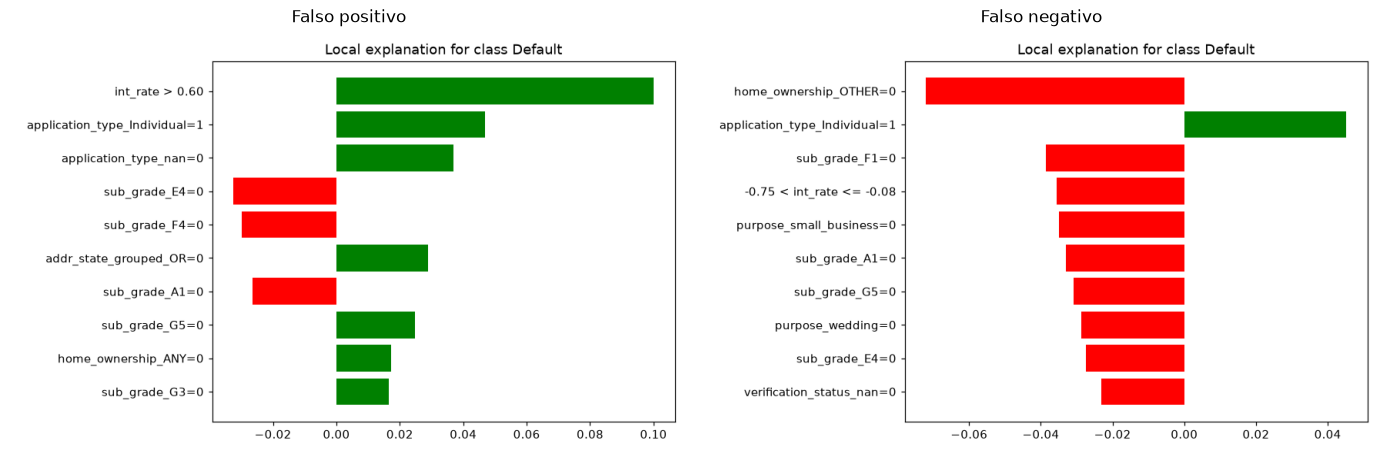

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, etiqueta in zip(axes, ["falso_positivo", "falso_negativo"]):
    img = mpimg.imread(f"../outputs/figures/eda/lime_sklearn_{etiqueta}.png")
    ax.imshow(img); ax.axis("off"); ax.set_title(etiqueta.replace("_", " ").capitalize())
plt.tight_layout()
plt.show()


En el falso negativo (id 17232974, probabilidad predicha de 0,128, bastante lejos de 0,5), la tasa de interés esta vez juega en la dirección opuesta (`int_rate` en un rango bajo o medio, empujando hacia \"no default\"), aunque la persona sí incumplió. Con la información disponible, el modelo no tenía ninguna señal fuerte para anticipar este caso. El `R²` local aquí es de solo 0,09, es decir que la aproximación lineal explica muy poco de lo que hace el modelo en esta vecindad, así que esta explicación en particular habría que tomarla con más cautela que la anterior. Esto, en sí mismo, es un diagnóstico útil de cuándo confiar o no en una explicación de LIME.

## 7.3. LIME sobre PySpark (`GBTClassifier`): el reto de envolver un modelo distribuido

LIME espera una función de Python (`predict_fn`) que reciba un arreglo de NumPy y devuelva probabilidades, que es exactamente lo que hace `predict_proba` en scikit-learn. Un `GBTClassificationModel` de Spark no tiene ese método, solo sabe transformar un DataFrame de Spark. Hace falta un adaptador que, cada vez que LIME llama a `predict_fn` con un lote de muestras perturbadas (`num_samples=5000` para cada instancia explicada), lo convierta a DataFrame, lo pase por `.transform()`, y traiga el resultado de vuelta a NumPy:

```python
def predict_fn_spark(X):\n    filas = [(i, Vectors.dense(fila.tolist())) for i, fila in enumerate(X)]\n    df = spark.createDataFrame(filas, [\"_orden\", \"features\"])\n    pred = gbt_model.transform(df).withColumn(\"proba_arr\", vector_to_array(\"probability\"))\n    pdf = pred.select(\"_orden\", \"proba_arr\").toPandas().sort_values(\"_orden\")\n    return np.stack(pdf[\"proba_arr\"].values)
```

Hay dos detalles importantes acá. El primero es que el `_orden` explícito es necesario porque Spark no garantiza que las filas salgan de `.transform()` en el mismo orden en que entraron, y sin reordenar, LIME asociaría cada probabilidad con la perturbación equivocada. El segundo es que el `.toPandas()` acá es sobre un lote de 5.000 filas (una instancia perturbada a la vez), no sobre el dataset completo, así que no viola la restricción de la sección 4 sobre no recolectar datos completos a memoria local.

En la práctica, cada llamada a `explain_instance` (que dispara un solo lote de 5.000 filas por Spark) tomó entre 1 y 3 segundos en esta máquina, bastante rápido porque es un Spark local de 2 núcleos sin el overhead real de una red o un clúster.

In [6]:
resultados_spark = json.load(open("../outputs/tables/lime_spark_resultados.json"))
for etiqueta, r in resultados_spark.items():
    print(f"{etiqueta}: id={r['id']}  y_real={r['y_real']}  prob_predicha={r['prob_predicha']:.4f}  "
          f"pred={r['pred_label']}  R²_local={r['r2_local']:.3f}")


falso_positivo: id=60981901  y_real=0  prob_predicha=0.5591  pred=1  R²_local=0.359
falso_negativo: id=9776027  y_real=1  prob_predicha=0.1468  pred=0  R²_local=0.087


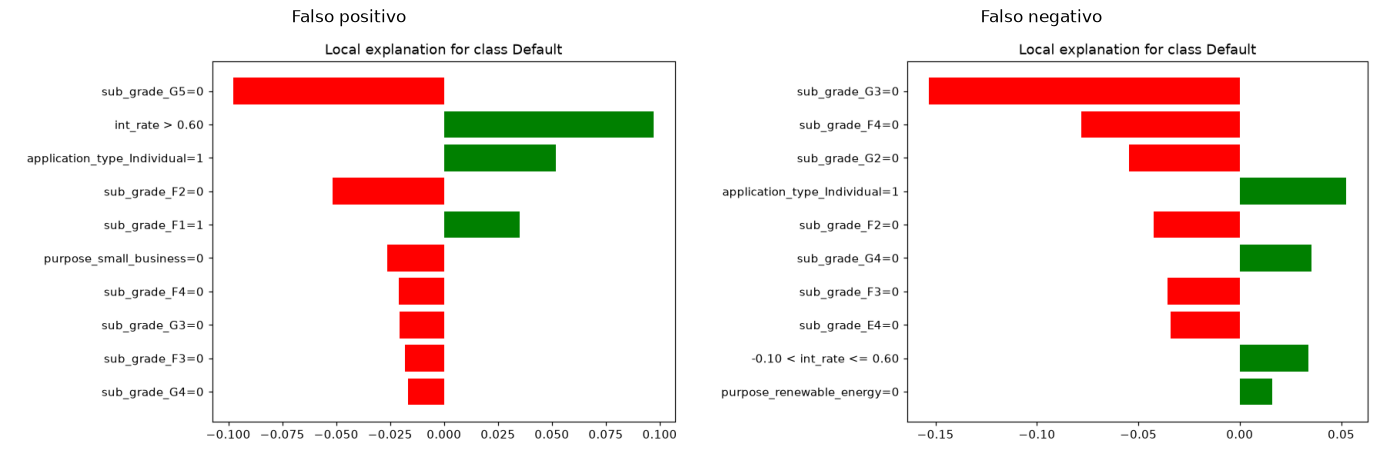

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, etiqueta in zip(axes, ["falso_positivo", "falso_negativo"]):
    img = mpimg.imread(f"../outputs/figures/eda/lime_spark_{etiqueta}.png")
    ax.imshow(img); ax.axis("off"); ax.set_title(etiqueta.replace("_", " ").capitalize())
plt.tight_layout()
plt.show()


Los dos casos que elegimos en PySpark son instancias distintas a las de scikit-learn (cada modelo se equivoca en casos distintos, y no hay ninguna garantía de que el mismo id sea un error en los dos entornos), pero el patrón que aparece es muy parecido: en el falso positivo (id 60981901, probabilidad de 0,559), `int_rate > 0,60` vuelve a ser la señal dominante hacia \"default\" (`R²` local de 0,36, razonable); en el falso negativo (id 9776027, probabilidad de 0,147), el modelo tampoco tenía señal fuerte, y el `R²` local vuelve a caer a 0,09, casi idéntico al 0,09 del falso negativo de scikit-learn. Esta coincidencia no nos parece casual: el ajuste lineal local de LIME es sistemáticamente peor para los falsos negativos que para los falsos positivos, en los dos entornos. Probablemente porque los casos de incumplimiento \"sorpresa\" (probabilidad baja, pero sí incumplen) están, casi por definición, en zonas del espacio de variables donde el comportamiento real del modelo es más no lineal, justo donde una aproximación lineal local es menos fiel.

## 7.4. Limitaciones de LIME en general, y de aplicarlo sobre un modelo de Spark en particular

Hay varias limitaciones que aplican a los dos entornos. LIME perturba y muestrea de forma aleatoria, así que con otra semilla el conjunto de variables \"top 10\" puede cambiar, sobre todo cuando, como aquí, hay decenas de columnas one-hot con pesos pequeños y parecidos compitiendo por los últimos lugares del ranking. La fidelidad local tampoco es constante: el `R²` del modelo lineal local fue bueno (entre 0,36 y 0,44) para los falsos positivos y pobre (0,09) para los falsos negativos. Una explicación con `R²` bajo no es necesariamente incorrecta, pero sí es una aproximación más floja de lo que realmente hace el modelo, y conviene reportar siempre ese número junto con la explicación, no solo la lista de variables. También hay bastante ruido de las variables dummy: con entre 93 y 107 columnas categóricas ya expandidas en one-hot, buena parte del \"top 10\" queda ocupado por columnas en 0 con peso marginal, lo cual es informativo hasta cierto punto, pero menos legible que si LIME pudiera tratar cada variable categórica original como una sola entidad en vez de docenas de columnas binarias.

Aplicar LIME sobre un modelo entrenado en Spark tiene limitaciones propias. No existe una implementación de LIME nativa para Spark ML, así que tuvimos que escribir a mano el adaptador `predict_fn_spark` de la sección 7.3, con el riesgo de bugs que eso implica (el reordenamiento por `_orden`, por ejemplo, es fácil de pasar por alto y produciría explicaciones completamente erróneas sin ningún error visible). También hay un costo por cada instancia que se explica: cada llamada implica crear un DataFrame nuevo, un `.transform()` y un `.toPandas()`, que en esta máquina tomó entre 1 y 3 segundos por instancia en un Spark local de 2 núcleos. Para explicar un puñado de casos, como hicimos aquí, esto es perfectamente viable, pero para generar explicaciones de forma rutinaria para miles de instancias (por ejemplo, una por cada solicitud rechazada), ese costo por instancia se volvería el cuello de botella, y en un clúster real con overhead de red y de planificación por cada micro-lote sería todavía peor que en esta máquina. Por último, los dos entornos no comparten el mismo espacio de variables (114 contra 107 columnas, sección 7.1), así que las explicaciones de un entorno y del otro no se pueden alinear término a término, aunque describan en esencia el mismo tipo de modelo sobre los mismos datos originales.

# 8. Comparación final y reflexión crítica

Esta sección cierra el proyecto: una sola tabla con los 12 modelos, y después la reflexión que pide el enunciado, pregunta por pregunta, apoyada en la evidencia que ya generamos en las secciones 1 a 7.

In [1]:
import sys
sys.path.insert(0, "../src")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
sk = pd.read_csv("../outputs/tables/sklearn_results.csv")
sp = pd.read_csv("../outputs/tables/spark_results.csv")
sk["entorno"] = "scikit-learn"; sp["entorno"] = "PySpark"


## 8.1. Tabla comparativa final: los 12 modelos en un solo vistazo

In [2]:
cols = ["entorno","modelo","best_params","cv_auc","test_auc","test_f1","tiempo_entrenamiento_s"]
tabla_final = pd.concat([sk[cols], sp[cols]], ignore_index=True).sort_values("test_auc", ascending=False)
tabla_final_fmt = tabla_final.copy()
for c in ["cv_auc","test_auc","test_f1"]:
    tabla_final_fmt[c] = tabla_final_fmt[c].round(4)
tabla_final_fmt["tiempo_entrenamiento_s"] = tabla_final_fmt["tiempo_entrenamiento_s"].round(1)
tabla_final_fmt.reset_index(drop=True)


,entorno,modelo,best_params,cv_auc,test_auc,test_f1,tiempo_entrenamiento_s
0,scikit-learn,GBT_HistGB,"{""max_depth"": 5, ""max_iter"": 100}",0.7098,0.7393,0.0046,600.4
1,scikit-learn,DecisionTree,"{""max_depth"": 10}",0.6689,0.7368,0.0024,509.1
2,PySpark,GBT,"{""maxIter"": 100, ""maxDepth"": 5}",0.7299,0.7327,0.0089,2950.2
3,PySpark,LogisticRegression,"{""regParam"": 1e-06}",0.7248,0.7232,0.0258,274.7
4,scikit-learn,RandomForest,"{""max_depth"": 15, ""n_estimators"": 100}",0.7109,0.7225,0.0000,6739.3
5,scikit-learn,LogisticRegression,"{""C"": 0.05529260848409784}",0.7141,0.7221,0.0191,70.4
6,PySpark,DecisionTree,"{""maxDepth"": 15}",0.7144,0.7204,0.0262,255.7
7,PySpark,RandomForest,"{""numTrees"": 100, ""maxDepth"": 15}",0.7184,0.7185,0.0000,10597.1
8,PySpark,LinearSVC,"{""regParam"": 1e-06}",0.6755,0.7037,0.0000,567.4
9,PySpark,NaiveBayes,{},0.6998,0.6989,0.2953,49.1


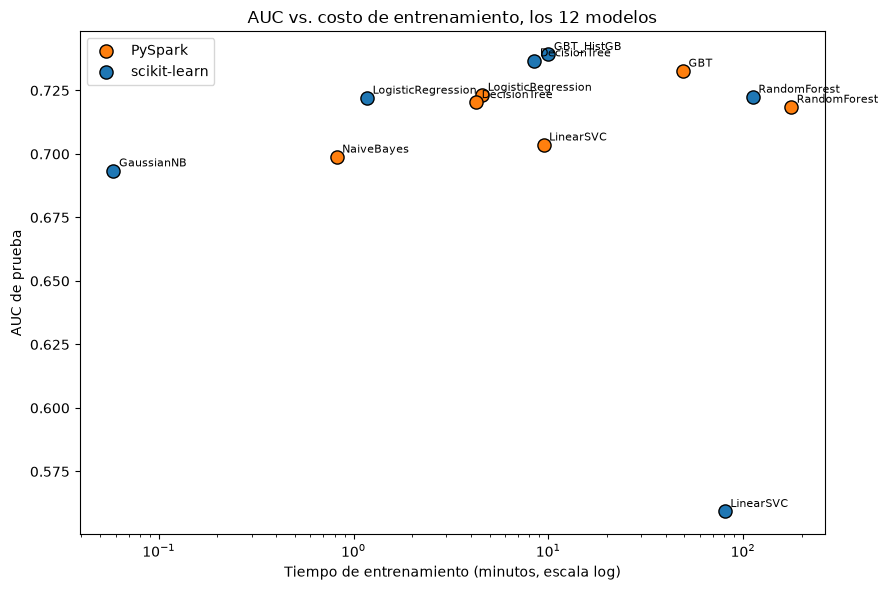

In [3]:
fig, ax = plt.subplots(figsize=(9,6))
colores = {"scikit-learn": "#1f77b4", "PySpark": "#ff7f0e"}
for entorno, grupo in tabla_final.groupby("entorno"):
    ax.scatter(grupo["tiempo_entrenamiento_s"]/60, grupo["test_auc"], s=90, label=entorno,
               color=colores[entorno], edgecolor="black")
    for _, fila in grupo.iterrows():
        ax.annotate(fila["modelo"], (fila["tiempo_entrenamiento_s"]/60, fila["test_auc"]),
                    fontsize=8, xytext=(4,3), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("Tiempo de entrenamiento (minutos, escala log)")
ax.set_ylabel("AUC de prueba")
ax.set_title("AUC vs. costo de entrenamiento, los 12 modelos")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/figures/eda/resumen_final_auc_vs_tiempo.png", dpi=110)
plt.show()


El mejor modelo en cada entorno es un boosting con histogramas (`HistGradientBoostingClassifier` en scikit-learn y `GBTClassifier` en Spark), y los dos quedan muy cerca uno del otro (0,739 contra 0,733), así que ninguno de los dos entornos domina de forma aplastante en desempeño. En tiempo, la nube de puntos deja ver el patrón real: la mayoría de los modelos de PySpark quedan más lentos que su contraparte de scikit-learn, con la notable excepción de `LinearSVC`.

## 8.2. Reflexión final, pregunta por pregunta

### 8.2.1. ¿Qué entorno fue más rápido, y por qué?

In [4]:
total_sk = sk["tiempo_entrenamiento_s"].sum(); total_sp = sp["tiempo_entrenamiento_s"].sum()
print(f"Total scikit-learn: {total_sk:,.1f}s (~{total_sk/60:.1f} min)")
print(f"Total PySpark:      {total_sp:,.1f}s (~{total_sp/60:.1f} min)")
print(f"scikit-learn fue {total_sp/total_sk:.2f}x mas rapido en total.")


Total scikit-learn: 12,761.4s (~212.7 min)
Total PySpark:      14,694.3s (~244.9 min)
scikit-learn fue 1.15x mas rapido en total.


scikit-learn ganó en el total (unas 3 horas 33 minutos contra 4 horas 5 minutos), y gana en 4 de los 6 modelos individuales. La razón principal es el hardware: esta máquina tiene solo 2 núcleos. El paralelismo distribuido de Spark tiene un costo fijo de coordinación (miles de stages, serialización entre tareas, planificación del scheduler) que solo se amortiza cuando hay muchos núcleos, o muchos nodos, entre los que repartir el trabajo. Con solo 2, ese costo casi nunca se paga a sí mismo. La excepción es `LinearSVC`: ahí Spark fue 8,5 veces más rápido y con mejor AUC, pero no por una ventaja de paralelismo, sino porque scikit-learn colapsó a una solución degenerada que, irónicamente, seguía siendo costosa de calcular (`liblinear` iteró 633 veces igual). `DecisionTree`, ya con el error de `rawPrediction`/`probability` corregido (sección 4.2.2), también fue cerca de 2 veces más rápido en Spark. Esa sí es una ventaja limpia de Spark, aunque modesta y aislada a un solo modelo.

### 8.2.2. ¿Qué entorno fue más preciso en AUC?

No hay un ganador único, depende de la familia de modelo:

| Familia | Gana | Diferencia de AUC (sk - sp) | ¿Prácticamente significativo (≥0,005)? |
|---|---|---|---|
| LogisticRegression | (empate) | -0,0011 | No |
| DecisionTree | scikit-learn | +0,0164 | Sí |
| RandomForest | (empate) | +0,0039 | No |
| GBT | scikit-learn | +0,0066 | Sí |
| LinearSVC | PySpark | -0,1443 | Sí (colapso de sklearn) |
| NaiveBayes | PySpark | -0,0055 | Sí (por poco) |

scikit-learn gana con margen real en 2 familias (`DecisionTree` y `GBT`), PySpark gana con margen real en otras 2 (`LinearSVC` y `NaiveBayes`, aunque la de `LinearSVC` es por el colapso de scikit-learn y no por una ventaja algorítmica de Spark), y en las otras 2 (`LogisticRegression` y `RandomForest`) son estadísticamente distintos pero prácticamente equivalentes. El mejor modelo global es `HistGradientBoostingClassifier` de scikit-learn (AUC de 0,739), apenas por encima del `GBTClassifier` de Spark (AUC de 0,733), y no es casualidad que los dos sean el mismo tipo de algoritmo.

### 8.2.3. Significancia estadística contra significancia práctica

Con 452.141 filas de prueba, la significancia estadística deja de ser informativa por sí sola. De las 44 comparaciones de AUC que hicimos en este proyecto (36 de DeLong en la sección 5 más 8 de McNemar y bootstrap en la sección 6), prácticamente todas rechazan la hipótesis nula, porque el tamaño de muestra por sí solo garantiza detectar cualquier diferencia que no sea exactamente cero, sin importar cuán chica. El umbral de significancia práctica que declaramos de antemano (diferencia de AUC mayor o igual a 0,005, sección 5) es lo que realmente separa las diferencias que importan de las que no: de las 6 comparaciones entre entornos, 4 son prácticamente relevantes (`DecisionTree`, `GBT`, `LinearSVC`, `NaiveBayes`) y 2 no lo son (`LogisticRegression`, `RandomForest`), aunque las 6 sean \"significativas\". La lección metodológica central del proyecto es que declarar el umbral de relevancia práctica antes de mirar los datos es lo único que evita concluir que dos modelos son diferentes cuando en realidad la diferencia es demasiado chica para cambiar qué modelo se elegiría en producción.

### 8.2.4. Diferencias de implementación que explican las discrepancias

Dos de las discrepancias que en un primer momento parecían diferencias algorítmicas entre librerías resultaron ser errores propios, no diferencias reales. En `DecisionTree` (sección 4.2.2), usamos `rawPredictionCol=\"rawPrediction\"` para seleccionar y evaluar el modelo, cuando el puntaje que realmente guardamos venía de `probability`. Para un árbol individual esas dos columnas no son equivalentes en el orden que producen (sí lo son para modelos de conjunto). Al corregirlo, la brecha bajó de 14 puntos de AUC a menos de 2. La diferencia que queda (cerca de 1,7 puntos) es probablemente real, y se puede atribuir a `maxBins=32` (Spark discretiza las variables continuas en como máximo 32 puntos de corte candidatos, mientras que scikit-learn evalúa cualquier punto real). En `NaiveBayes` (sección 4.6c) encontramos exactamente el mismo bug, con el mismo mecanismo, y al corregirlo la \"diferencia real de implementación\" que habíamos documentado al principio (0,564 contra 0,694) desapareció por completo (0,699 contra 0,694, prácticamente empatados).

Una diferencia que sí resultó ser real y la entendemos bien es la de `LinearSVC`: colapsó en scikit-learn (`liblinear`, descenso de coordenadas dual) pero no en Spark (OWL-QN, cuasi-Newton). Son dos optimizadores distintos explorando la misma superficie de pérdida de forma distinta, y uno de ellos quedó atrapado en una solución degenerada para este problema desbalanceado (secciones 3.7 y 4.6b).

Y una diferencia de implementación que no afecta el AUC pero sí la interpretabilidad (sección 7.1): el `OneHotEncoder` de scikit-learn y el de Spark, con la misma configuración conceptual, producen espacios de variables de distinta dimensión (114 contra 107) por cómo cada uno trata la categoría nula o no vista.

La lección que se repite en los tres casos es la misma: un error de implementación propio puede parecer, a primera vista, una diferencia legítima entre librerías, y solo se distingue verificando explícitamente, modelo por modelo, que el puntaje reportado coincide con el que realmente se usa en el resto del pipeline.

### 8.2.5. DeLong contra McNemar y bootstrap: ¿coinciden, y qué le falta a DeLong?

In [5]:
delong_between = pd.read_csv("../outputs/tables/delong_between_envs.csv")
mcnemar_res = pd.read_csv("../outputs/tables/mcnemar_resultados.csv")
boot_res = pd.read_csv("../outputs/tables/bootstrap_resultados.csv")
print(f"DeLong:            {len(delong_between)+30} comparaciones (36 en total, seccion 5), todas rechazan H0 tras Holm")
print(f"McNemar:           {len(mcnemar_res)} comparaciones (seccion 6), {mcnemar_res['rechaza_h0_holm_0.05'].sum()}/{len(mcnemar_res)} rechazan H0 tras Holm")
print(f"Bootstrap pareado: {len(boot_res)} comparaciones (seccion 6), {boot_res['auc_excluye_cero'].sum()}/{len(boot_res)} excluyen 0 en el IC95%")


DeLong:            36 comparaciones (36 en total, seccion 5), todas rechazan H0 tras Holm
McNemar:           8 comparaciones (seccion 6), 8/8 rechazan H0 tras Holm
Bootstrap pareado: 8 comparaciones (seccion 6), 8/8 excluyen 0 en el IC95%


Las tres pruebas coinciden en dirección y en significancia estadística en las 8 comparaciones que tienen en común (tabla resumen de la sección 6.5), lo cual es una buena señal de consistencia interna, aunque esperable con este tamaño de muestra. DeLong compara el ranking (AUC) con una fórmula analítica exacta. McNemar compara los aciertos a un umbral fijo, de forma complementaria y no como sustituto, porque puede cambiar de conclusión si cambia el umbral. El bootstrap da un intervalo de confianza empírico, sin asumir normalidad asintótica, tanto para AUC como para métricas que DeLong no cubre (AUC-PR y F1). Las limitaciones específicas de DeLong (solo AUC, asintótica, sensible al tamaño de muestra, sección 5.8) son exactamente lo que McNemar y el bootstrap vienen a compensar.

### 8.2.6. ¿A qué volumen de datos empezaría PySpark a superar a scikit-learn?

Con los datos de este proyecto (1,8 millones de filas de entrenamiento, alrededor de 114 columnas ya con one-hot, que caben cómodamente en los 4 GB de memoria asignados) no hay ninguna razón estructural para que Spark gane. El cuello de botella no es memoria ni cómputo que no entre en una sola máquina, así que el paralelismo distribuido solo añade overhead de coordinación sin nada que lo compense. La ventaja de Spark aparecería en dos escenarios, ninguno presente aquí: un dataset que no entra en la memoria de una sola máquina (varias decenas de GB o más, forzando el uso de disco o haciendo imposible usar scikit-learn), o un clúster real con muchos nodos y núcleos (no 2, sino decenas o cientos), donde el trabajo sí se reparte de forma efectiva y el costo fijo de coordinación se amortiza sobre mucho más cómputo útil. Ninguna de las dos condiciones se cumple con 2 núcleos y medio gigabyte de datos ya preprocesados, así que en este proyecto no hay ningún punto de la curva de tamaño de datos donde Spark hubiera empezado a ganar sin cambiar también el hardware.

### 8.2.7. Contribución y limitaciones de LIME, especialmente sobre un modelo distribuido

LIME sí aportó algo que ninguna de las pruebas globales (DeLong, McNemar, bootstrap) puede dar: una explicación por caso individual, útil para entender un error concreto del modelo (secciones 7.2 y 7.3) en vez de solo su desempeño agregado. El hallazgo más interesante no fue una variable en particular, sino un patrón que se repitió en los dos entornos: el ajuste lineal local de LIME fue sistemáticamente peor (`R²` de alrededor de 0,09) para los falsos negativos que para los falsos positivos (`R²` entre 0,36 y 0,44), lo cual sugiere que los incumplimientos \"sorpresa\" caen en zonas más no lineales del espacio de variables. Las limitaciones son las de siempre (inestabilidad por el muestreo aleatorio, ruido de docenas de columnas dummy con peso marginal) más una específica de Spark: no existe una implementación nativa, así que tuvimos que escribir a mano un adaptador que convierte cada lote de muestras perturbadas a DataFrame, lo pasa por `.transform()`, y lo trae de vuelta a NumPy (sección 7.3). Funcionó bien para explicar un puñado de casos (1 a 3 segundos cada uno), pero ese costo por instancia haría impráctico generar explicaciones para miles de casos de forma rutinaria sin un rediseño, por ejemplo procesando muchas instancias en un solo lote en vez de una por una.

### 8.2.8. Efecto de cada condición obligatoria del enunciado

- Usar un split y un preprocesamiento compartido entre los dos entornos fue la condición que hizo posible todo lo demás. Sin las mismas 452.141 filas de prueba en el mismo orden lógico (mismos id), no existiría DeLong, ni McNemar, ni el bootstrap pareado tal como los aplicamos, porque los tres dependen de comparar observaciones pareadas y no muestras independientes.
- Usar `cv=3` / `numFolds=3` en vez de 5 o 10 fue más barato, y era indispensable porque cada combinación de hiperparámetros para `RandomForest` y `GBT` ya tomaba varios minutos, pero también es más ruidoso. Esto puede explicar, junto con `maxBins`, por qué `DecisionTree` eligió una profundidad distinta en cada entorno (10 en scikit-learn, 15 en Spark): con solo 3 particiones, la estimación de AUC de validación cruzada tiene más varianza, y el óptimo elegido puede cambiar de una corrida a otra.
- No usar un objeto `Pipeline` en scikit-learn (preprocesamiento explícito y separado, sección 2) hace que todo sea más transparente y más fácil de revisar paso a paso, aunque el costo es más responsabilidad manual para mantener sincronizados train y test y para no filtrar información, algo que sí vigilamos de forma activa, por ejemplo al elegir el umbral de Youden solo con datos de entrenamiento (sección 6.1).
- Usar una configuración de Spark reducida y justificada para el hardware real (2 núcleos, 4g/4g, `shuffle.partitions=8` en vez de los 400 \"de fábrica\") la documentamos de forma explícita en `src/model_pyspark.py`. En el fondo, es la misma razón detrás de la respuesta a 8.2.1 y 8.2.6: con este hardware, cualquier configuración de Spark iba a chocar con el mismo techo estructural.

## 8.3. Conclusión general

Los dos entornos llegan a un techo predictivo muy parecido (entre 0,72 y 0,74 de AUC), con el mismo tipo de modelo (boosting con histogramas) ganando en los dos. Para este dataset en particular (1,8 millones de filas, una sola máquina de 2 núcleos), elegir entre scikit-learn y PySpark no cambia la conclusión de negocio de forma sustancial. Lo que sí cambia, y de forma importante, es qué tan seguros podemos estar de esa conclusión: la comparación rigurosa (mismo split, tres pruebas estadísticas complementarias, un umbral de significancia práctica declarado de antemano) fue lo que nos permitió distinguir diferencias reales (el colapso de `LinearSVC`, la ventaja genuina pero modesta de `DecisionTree` en Spark) de errores de implementación propios que, sin esa verificación cruzada, habrían quedado documentados, de forma incorrecta, como hallazgos sobre las librerías. Encontrar y corregir esos dos errores (secciones 4.2.2 y 4.6c) es, en un sentido real, el resultado más valioso de todo el ejercicio. Más que cualquier número de AUC, es la evidencia de que la metodología de comparación que exigía el enunciado cumplió exactamente la función para la que está pensada.